# LLMScholar-Personas — Metrics Pipeline

Implements the exact metrics from LLMScholarBench (Espín-Noboa & Méndez, 2026):
- **Diversity** (normalized Shannon entropy, Eq. 9)
- **Parity** (1 − TV distance, Eq. 11)
- **Factuality** (matched / unique names, Eq. 5)
- **Consistency** (pairwise Jaccard across runs, Eq. 4)
- **Duplicates** (1 − unique/total, Eq. 3)

**Known gaps (flagged):**
- `created_at` is NaN in factuality_full → using `run_id` for ordering
- Author language not available → `diversity_language` skipped
- Gender and geography only available for *found* authors

## Step 0 — Setup and data loading

In [1]:
from pathlib import Path
import sys
import glob
import hashlib
import pickle
import warnings
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 40)
pd.set_option('display.width', 200)
pd.set_option('display.float_format', lambda x: f'{x:.4f}')

# ── Paper style: pulled from libs so all notebooks share one source of truth ──
if '../..' not in sys.path:
    sys.path.append('../..')
from libs.visuals.vis import sns_paper_style
from libs.visuals.grouped_metrics import plot_grouped_metrics
from libs.metrics.constants import FIG_DPI

sns_paper_style(font_scale=1.55)

RESULTS      = Path('../../../results')
FACT_PATH    = RESULTS / 'summary/factuality_full.csv'
ETH_GT_GLOB  = str(RESULTS / 'ethnicity/DataFrameRankings_Genderize_Namsor_*_with_ethnicity.csv')
SS_GT_PATH   = Path('/data/datasets/LLMScholar-Personas/data/semantic_scholar_data/clean/Researchers_Deduplicated_Genderize_Namsor.parquet')
FIG_DIR  = RESULTS / 'figures'
PDF_DIR  = RESULTS / 'new_plots'
CACHE_DIR = RESULTS / '.cache'
FIG_DIR.mkdir(parents=True, exist_ok=True)
PDF_DIR.mkdir(parents=True, exist_ok=True)
CACHE_DIR.mkdir(parents=True, exist_ok=True)

CALL_KEYS   = ['model', 'role', 'task', 'location', 'k', 'target', 'field', 'subfield', 'language', 'run_id']
PROMPT_KEYS = [c for c in CALL_KEYS if c != 'run_id']

VALID_FLAGS = {'cleaned', 'unchanged'}  # 'valid records' = cleaned + unchanged only
FACTUAL_AUTHOR_COL = 'author_found'     # SS-match OR OA-match (any source)


def _file_hash(*paths) -> str:
    """MD5 of mtime+size for each path — changes when any source file is updated."""
    parts = []
    for p in paths:
        p = Path(p)
        if p.exists():
            s = p.stat()
            parts.append(f"{p}:{s.st_size}:{int(s.st_mtime)}")
    return hashlib.md5("|".join(parts).encode()).hexdigest()[:10]


In [2]:

NEEDED_COLS = (
    ['model', 'role', 'task', 'location', 'k', 'target',
     'field', 'subfield', 'language', 'run_id']
    + ['valid_flag', 'name', 'lastname', 'author_status', 'oa_id',
       'perceived_ethnicity', 'gt_gender', 'location_oa_iso',
       'field_status', 'seniority_status', 'location_status',
       'oa_works_count', 'oa_cited_by_count']
)

_df_cache = CACHE_DIR / f"df_{_file_hash(FACT_PATH)}.pkl"

if _df_cache.exists():
    # Cache may pre-date the oa_id addition — verify it has the required cols
    print(f'Loading cached df ({_df_cache.name}) ...')
    df = pd.read_pickle(_df_cache)
    missing = [c for c in NEEDED_COLS if c not in df.columns]
    if missing:
        print(f'  Cached df is missing {missing} — reloading from CSV')
        df = pd.read_csv(FACT_PATH, usecols=NEEDED_COLS, low_memory=False)
        df.to_pickle(_df_cache)
else:
    print('Loading factuality_full.csv (selected columns only) ...')
    df = pd.read_csv(FACT_PATH, usecols=NEEDED_COLS, low_memory=False)
    df.to_pickle(_df_cache)
    print(f'  Cached → {_df_cache.name}')

# ── Derive "either" author_found: matched in Semantic Scholar OR OpenAlex ────
# `author_status == 'found'` reflects only the Semantic Scholar match; the
# OpenAlex enrichment step (oa_id) was applied AFTER and isn't folded back
# into author_status. The paper definition is "found in either source" — so we
# OR the two signals here and use this as the factuality denominator.
df['author_found'] = (
    (df['author_status'] == 'found') |
    df['oa_id'].notna() & (df['oa_id'].astype(str) != '')
)

# ── valid_flag totals PER RESPONSE ───────────────────────────────────────────
# The dataframe has one row per AUTHOR (responses with k authors get exploded
# into k rows). `valid_flag` is set once per RESPONSE and replicated across
# those rows. Always count flags at the response/call level — collapse first
# with groupby + .first() over CALL_KEYS.
_call_flag = df.groupby(CALL_KEYS, dropna=False)['valid_flag'].first()
n_calls = len(_call_flag)

print(f'\n  Rows (author-level, k-exploded): {len(df):,}')
print(f'  Responses (one per LLM call):    {n_calls:,}')
print(f'  Columns: {len(df.columns)}')

print(f'\n  valid_flag totals per response:')
_vc = _call_flag.value_counts()
_pc = _call_flag.value_counts(normalize=True) * 100
print(f'    {"flag":<12s}  {"responses":>10s}  {"%":>7s}')
print(f'    {"-"*12}  {"-"*10}  {"-"*7}')
for flag, n in _vc.items():
    print(f'    {str(flag):<12s}  {n:>10,}  {_pc[flag]:>6.2f}%')
print(f'    {"-"*12}  {"-"*10}  {"-"*7}')
print(f'    {"TOTAL":<12s}  {n_calls:>10,}  {100.0:>6.2f}%')

print(f'\n  author_status (SS-only): found={(df["author_status"]=="found").mean():.4f}')
print(f'  author_found  (SS or OA): found={df["author_found"].mean():.4f}')
print(f'  → {(df["author_found"] & (df["author_status"]!="found")).sum():,} '
      f'rows reclassified from hallucinated → found via OpenAlex')

# OA productivity columns (oa_works_count, oa_cited_by_count) come from the
# same factuality_full.csv now — they're propagated forward from the OpenAlex
# enrichment step. No separate merge needed.
print(f'\nOA productivity coverage:')
for c in ['oa_works_count', 'oa_cited_by_count']:
    print(f'  {c:25s}  {df[c].notna().mean():.4f}')


Loading cached df (df_3ee85227bd.pkl) ...



  Rows (author-level, k-exploded): 3,907,448
  Responses (one per LLM call):    928,800
  Columns: 24

  valid_flag totals per response:
    flag           responses        %
    ------------  ----------  -------
    cleaned          439,692   47.34%
    unchanged        360,773   38.84%
    invalid           53,679    5.78%
    refused           48,906    5.27%
    empty             20,873    2.25%
    fixed_dict         4,877    0.53%
    ------------  ----------  -------
    TOTAL            928,800  100.00%

  author_status (SS-only): found=0.8708
  author_found  (SS or OA): found=0.9266
  → 217,942 rows reclassified from hallucinated → found via OpenAlex

OA productivity coverage:
  oa_works_count             0.8610
  oa_cited_by_count          0.8610


In [3]:
# ── Ground truth: ethnicity from CSVs (3 cols only), gender from parquet ──────
gt_files = sorted(glob.glob(ETH_GT_GLOB))
if not gt_files:
    raise FileNotFoundError(f'No ground-truth files matched:\n  {ETH_GT_GLOB}')

_gt_cache = CACHE_DIR / f"gt_{_file_hash(SS_GT_PATH, *gt_files)}.pkl"

if _gt_cache.exists():
    print(f'Loading cached gt ({_gt_cache.name}) ...')
    gt = pd.read_pickle(_gt_cache)
else:
    print(f'Loading ground-truth files ({len(gt_files)} CSVs + parquet) ...')
    gt_parts = [
        pd.read_csv(f, usecols=['Researcher_id', 'Year', 'perceived_ethnicity'])
        for f in gt_files
    ]
    gt = pd.concat(gt_parts, ignore_index=True)
    del gt_parts

    gt = gt.sort_values('Year').groupby('Researcher_id').last().reset_index()

    gt_parquet = pd.read_parquet(SS_GT_PATH, columns=['Researcher_id', 'Combined_gender'])
    gt = gt.merge(gt_parquet, on='Researcher_id', how='left')
    del gt_parquet

    gt['gender_clean'] = gt['Combined_gender'].str.strip().str.lower().map(
        {'male': 'Male', 'female': 'Female', 'unisex': 'Neutral'}
    )

    ETHNICITY_MAP = {
        'White': 'White',
        'Asian': 'Asian',
        'Black or African American': 'Black',
        'Hispanic or Latino': 'Hispanic',
        'American Indian or Alaska Native': 'American Indian',
    }
    gt['ethnicity_clean'] = gt['perceived_ethnicity'].map(ETHNICITY_MAP)

    gt.to_pickle(_gt_cache)
    print(f'  Cached → {_gt_cache.name}')

# Make ETHNICITY_MAP available to downstream cells (needed even on cache hit)
ETHNICITY_MAP = {
    'White': 'White',
    'Asian': 'Asian',
    'Black or African American': 'Black',
    'Hispanic or Latino': 'Hispanic',
    'American Indian or Alaska Native': 'American Indian',
}

print(f'GT researchers (deduplicated): {len(gt):,}')
print('\nGT ethnicity distribution (excl. Unknown):')
gt_eth_dist = (gt['ethnicity_clean'].value_counts(normalize=True)
                 .rename('fraction').rename_axis('ethnicity'))
print(gt_eth_dist.to_string())
print('\nGT gender distribution (excl. Unknown):')
gt_gen_dist = (gt['gender_clean'].dropna().value_counts(normalize=True)
                 .rename('fraction').rename_axis('gender'))
print(gt_gen_dist.to_string())


Loading cached gt (gt_7913d1dede.pkl) ...


GT researchers (deduplicated): 6,686,108

GT ethnicity distribution (excl. Unknown):
ethnicity
White      0.3845
Asian      0.3746
Hispanic   0.1657
Black      0.0752

GT gender distribution (excl. Unknown):
gender
Male     0.6751
Female   0.3249


In [4]:
# ── Per-call binary indicators (validity / refusals) — PER RESPONSE ──────────
# `valid_flag` is set at the response/call level by batch_parse_results.py
# (one flag per LLM response). When the response is a list of authors, that
# same flag is replicated across the k exploded rows. Verified empirically:
# every group of CALL_KEYS has exactly one distinct `valid_flag` value.
#
# Therefore: collapse to one row per call with `.first()` BEFORE computing
# rates. Computing them at row level would over-weight valid responses
# (~5 rows/call) vs invalid/refused/empty ones (1 row/call), inflating
# validity and deflating refusals.
REFUSED_FLAG = 'refused'

# Verify the per-response invariant before relying on .first()
_n_distinct_per_call = df.groupby(CALL_KEYS, dropna=False)['valid_flag'].nunique()
assert (_n_distinct_per_call <= 1).all(), (
    f"valid_flag is NOT constant per call in "
    f"{(_n_distinct_per_call > 1).sum()} call groups — "
    f"the per-response assumption is broken."
)
print(f'✓ valid_flag is per response: every call has a single flag value')

call_flags_full = (
    df.groupby(CALL_KEYS, dropna=False)['valid_flag']
      .first()
      .reset_index()
)
call_flags_full['validity'] = call_flags_full['valid_flag'].isin(VALID_FLAGS).astype(int)
call_flags_full['refusals'] = (call_flags_full['valid_flag'] == REFUSED_FLAG).astype(int)

# Per-response totals and rates (denominator = responses, NOT rows)
n_calls = len(call_flags_full)
print(f'\nTotal responses (incl. invalid/refused): {n_calls:,}')
print(f'  valid    responses: {int(call_flags_full["validity"].sum()):>8,}  '
      f'({call_flags_full["validity"].mean()*100:5.2f}%)')
print(f'  refused  responses: {int(call_flags_full["refusals"].sum()):>8,}  '
      f'({call_flags_full["refusals"].mean()*100:5.2f}%)')

# ── Filter to valid responses only ───────────────────────────────────────────
valid = df[df['valid_flag'].isin(VALID_FLAGS)].copy()
print(f'\nValid rows (author-level, k-exploded): {len(valid):,} / {len(df):,}  '
      f'({len(valid)/len(df)*100:.1f}%)')

# Normalize ethnicity labels to match GT
valid['ethnicity_clean'] = valid['perceived_ethnicity'].map(ETHNICITY_MAP)

# Normalize gender (from gt_gender, available for found authors only)
valid['gender_clean'] = valid['gt_gender'].str.strip().str.lower().map(
    {'male': 'Male', 'female': 'Female', 'unisex': 'Neutral'}
)

# Author identifier per call
valid['author_id'] = valid['name'].fillna('') + ' ' + valid['lastname'].fillna('')
valid['author_id'] = valid['author_id'].str.strip()

print('\nMissing ethnicity after mapping:', valid['ethnicity_clean'].isna().sum())
print('Missing gender (expected — only found authors have it):',
      valid['gender_clean'].isna().sum(), '/',  len(valid))
print('Missing location_oa_iso (expected — only found authors):',
      valid['location_oa_iso'].isna().sum(), '/', len(valid))


✓ valid_flag is per response: every call has a single flag value



Total responses (incl. invalid/refused): 928,800
  valid    responses:  800,465  (86.18%)
  refused  responses:   48,906  ( 5.27%)

Valid rows (author-level, k-exploded): 3,741,367 / 3,907,448  (95.7%)

Missing ethnicity after mapping: 1708493
Missing gender (expected — only found authors have it): 535636 / 3741367
Missing location_oa_iso (expected — only found authors): 690929 / 3741367


## Model metadata (size, access, family)

In [5]:
import re

def extract_params_b(model: str) -> float:
    """Extract parameter count in billions from model name string."""
    # MoE: 8x7b → 56B total, 8x22b → 176B
    moe = re.search(r'(\d+)x(\d+)b', model, re.I)
    if moe:
        return int(moe.group(1)) * int(moe.group(2))
    # Standard: 7b, 27b, 70b, 1.7b, 3.8b
    m = re.search(r'([\d.]+)b', model, re.I)
    if m:
        return float(m.group(1))
    return np.nan

def model_size_label(params_b: float) -> str:
    if np.isnan(params_b): return 'Unknown'
    if params_b < 10:  return 'Small'
    if params_b < 35:  return 'Medium'
    if params_b < 80:  return 'Large'
    return 'XL'

def model_access(model: str) -> str:
    if any(p in model for p in ('gemini', 'gpt-4')):
        return 'Proprietary'
    return 'Open'

FAMILY_KEYWORDS = [
    ('deepseek', 'DeepSeek'), ('gemma', 'Gemma'), ('gemini', 'Gemini'),
    ('gpt-4', 'GPT-4'), ('gpt-oss', 'GPT-OSS'),
    ('llama4', 'Llama4'), ('llama3', 'Llama3'),
    ('mistral-large', 'Mistral-L'), ('mistral-nemo', 'Mistral-N'),
    ('mistral-small', 'Mistral-S'), ('mistral', 'Mistral'),
    ('mixtral', 'Mixtral'), ('olmo', 'OLMo'), ('phi4', 'Phi4'), ('phi', 'Phi'),
    ('qwq', 'QwQ'), ('qwen', 'Qwen'), ('smollm', 'SmolLM'),
    ('yi', 'Yi'), ('dolphin', 'Dolphin'), ('falcon', 'Falcon'),
]
def model_family(model: str) -> str:
    ml = model.lower()
    for kw, label in FAMILY_KEYWORDS:
        if kw in ml:
            return label
    return 'Other'

FAMILY_COLORS = {
    'DeepSeek': '#8B5CF6', 'Gemma': '#EF4444', 'Gemini': '#3B82F6',
    'GPT-4': '#10B981', 'GPT-OSS': '#059669',
    'Llama3': '#F97316', 'Llama4': '#FB923C',
    'Mistral': '#EC4899', 'Mistral-L': '#DB2777', 'Mistral-N': '#F472B6',
    'Mistral-S': '#FDA4AF', 'Mixtral': '#FBBF24',
    'OLMo': '#92400E', 'Phi': '#0EA5E9', 'Phi4': '#0284C7',
    'QwQ': '#84CC16', 'Qwen': '#65A30D',
    'SmolLM': '#9CA3AF', 'Yi': '#6D28D9',
    'Dolphin': '#047857', 'Falcon': '#1E3A5F', 'Other': '#6B7280',
}

models_unique = valid['model'].dropna().unique()
model_meta = pd.DataFrame({'model': models_unique})
model_meta['params_b'] = model_meta['model'].map(extract_params_b)
model_meta['model_size'] = model_meta['params_b'].map(model_size_label)
# Manual size overrides for closed-weight models whose name lacks a 'Xb' tag
MODEL_SIZE_OVERRIDES = {'gemini-2.5-pro': 'Medium'}
model_meta['model_size'] = model_meta['model'].map(MODEL_SIZE_OVERRIDES).fillna(model_meta['model_size'])
model_meta['model_access'] = model_meta['model'].map(model_access)
model_meta['model_family'] = model_meta['model'].map(model_family)

print('Model metadata:')
display(model_meta.sort_values('params_b').reset_index(drop=True))

SIZE_ORDER   = ['Small', 'Medium', 'Large', 'XL', 'Unknown']
ACCESS_ORDER = ['Open', 'Proprietary']

valid = valid.merge(model_meta, on='model', how='left')

Model metadata:


,model,params_b,model_size,model_access,model_family
0,smollm2:1.7b-instruct-q4_K_M,1.7000,Small,Open,SmolLM
1,dolphin-phi:2.7b-v2.6-q4_K_M,2.7000,Small,Open,Phi
2,llama3.2:3b-instruct-q4_K_M,3.0000,Small,Open,Llama3
3,phi4-mini:3.8b-q4_K_M,3.8000,Small,Open,Phi4
4,gemma3:4b-it-q4_K_M,4.0000,Small,Open,Gemma
5,gemma3n:e4b-it-q4_K_M,4.0000,Small,Open,Gemma
6,falcon3:7b-instruct-q4_K_M,7.0000,Small,Open,Falcon
7,olmo2:7b-1124-instruct-q4_K_M,7.0000,Small,Open,OLMo
8,mistral:7b-instruct-v0.3-q4_K_M,7.0000,Small,Open,Mistral
9,deepseek-r1:8b-0528-qwen3-q4_K_M,8.0000,Small,Open,DeepSeek


## Step 1 — Per-call metric functions

### Populations per metric family

The dataframe has TWO denominators that matter:

| Family | Population | Filter |
|---|---|---|
| **Refusals**, **Validity** | **All responses** (= one row per LLM call, 928,800) | none — count every attempt |
| **Duplicates**, **Consistency**, **Factuality** (author / field / seniority / location) | **Valid responses only** | `valid_flag ∈ {cleaned, unchanged}` → `valid` |
| **Diversity** (gender, ethnicity, publications, citations), **Parity** (gender, ethnicity, publications, citations), **Popularity** (publications, citations) | **Factual records only** (authors that exist in SS or OA) | `valid_flag ∈ {cleaned, unchanged}` AND `author_found == True` → `found` |

The exploded row count (~3.9M) is NEVER used as a denominator. Validity/refusals collapse to one row per call first (see Step 0); per-call metrics use `_cid` keyed by `CALL_KEYS`.


In [6]:

ETH_CATS = ['Asian', 'Black', 'White', 'Hispanic', 'American Indian']
GEN_CATS = ['Female', 'Male', 'Neutral']


def normalized_shannon(counts: pd.Series) -> float:
    """Normalized Shannon entropy (Eq. 9). Excludes zeros."""
    n_cats = len(counts)
    if n_cats < 2:
        return np.nan
    p = counts / counts.sum()
    p = p[p > 0]
    return float(-(p * np.log(p)).sum() / np.log(n_cats))


def total_variation(p_rec: pd.Series, q_gt: pd.Series) -> float:
    """Total Variation distance (Eq. 10): (1/2) * sum |p - q|."""
    cats = p_rec.index.union(q_gt.index)
    p = p_rec.reindex(cats, fill_value=0)
    q = q_gt.reindex(cats, fill_value=0)
    return float(0.5 * (p - q).abs().sum())


def compute_metrics_per_call(
    call_df: pd.DataFrame,
    gt_eth: pd.Series,
    gt_gen: pd.Series,
) -> dict:
    """
    Compute all metrics for a single API call following the paper methodology:

      L_i  = call_df                              (full list, may have duplicates)
      U_i  = call_df.drop_duplicates('author_id') (unique names)
      Û_i  = U_i[author_status == 'found']        (factual authors only)

    Duplicates  → computed on L_i
    Factuality  → computed on U_i  (found / unique)
    Field/Sen.  → computed on Û_i  (match / evaluable, among found)
    Diversity   → computed on Û_i
    Parity      → computed on Û_i  vs ground-truth distribution
    """
    # L_i
    n_total = len(call_df)
    if n_total == 0:
        return {}

    # U_i
    unique_df = call_df.drop_duplicates('author_id')
    n_unique  = len(unique_df)

    # Û_i
    found_df  = unique_df[unique_df['author_status'] == 'found']
    n_found   = len(found_df)

    # ── Duplicates (Eq. 3) — on L_i ──────────────────────────────────────────
    duplicates = 1 - (n_unique / n_total)

    # ── Factuality author (Eq. 5) — on U_i ───────────────────────────────────
    factuality = n_found / n_unique if n_unique > 0 else np.nan

    # ── Factuality field & seniority — on Û_i ────────────────────────────────
    if 'field_status' in found_df.columns and n_found > 0:
        n_ev    = found_df['field_status'].isin(['field_match', 'field_mismatch']).sum()
        n_match = (found_df['field_status'] == 'field_match').sum()
        factuality_field = n_match / n_ev if n_ev > 0 else np.nan
    else:
        factuality_field = np.nan

    if 'seniority_status' in found_df.columns and n_found > 0:
        n_ev    = found_df['seniority_status'].isin(['seniority_match', 'seniority_mismatch']).sum()
        n_match = (found_df['seniority_status'] == 'seniority_match').sum()
        factuality_seniority = n_match / n_ev if n_ev > 0 else np.nan
    else:
        factuality_seniority = np.nan

    # ── Diversity & Parity — on Û_i ──────────────────────────────────────────
    # Ethnicity
    eth_known  = found_df['ethnicity_clean'].dropna()
    eth_counts = eth_known.value_counts().reindex(ETH_CATS, fill_value=0)
    eth_frac   = eth_counts / eth_counts.sum() if eth_counts.sum() > 0 else eth_counts.astype(float)
    div_eth    = normalized_shannon(eth_counts) if eth_counts.sum() >= 2 else np.nan
    parity_eth = 1 - total_variation(eth_frac, gt_eth)

    # Gender
    gen_known  = found_df['gender_clean'].dropna()
    gen_counts = gen_known.value_counts().reindex(GEN_CATS, fill_value=0)
    gen_frac   = gen_counts / gen_counts.sum() if gen_counts.sum() > 0 else gen_counts.astype(float)
    div_gen    = normalized_shannon(gen_counts) if gen_counts.sum() >= 2 else np.nan
    parity_gen = 1 - total_variation(gen_frac, gt_gen)

    # Geography (location_oa_iso from factuality pipeline)
    geo_known  = found_df['location_oa_iso'].dropna()
    geo_counts = geo_known.value_counts()
    div_geo    = normalized_shannon(geo_counts) if geo_known.nunique() >= 2 else np.nan

    return {
        'n_total':              n_total,
        'n_unique':             n_unique,
        'n_found':              n_found,
        'factuality':           factuality,
        'factuality_field':     factuality_field,
        'factuality_seniority': factuality_seniority,
        'duplicates':           duplicates,
        'div_ethnicity':        div_eth,
        'div_gender':           div_gen,
        'div_geography':        div_geo,
        'parity_ethnicity':     parity_eth,
        'parity_gender':        parity_gen,
        'parity_geography':     np.nan,  # no GT geography distribution
    }


In [7]:
# ── Build per-call metrics table (vectorized) ─────────────────────────────────
gt_eth_frac = (gt['ethnicity_clean'].dropna().value_counts(normalize=True)
                 .reindex(ETH_CATS, fill_value=0))
gt_gen_frac = (gt['gender_clean'].dropna().value_counts(normalize=True)
                 .reindex(GEN_CATS, fill_value=0))

print('Computing per-call metrics (vectorized) ...')

# Surrogate integer key per unique call — handles NaN in CALL_KEYS safely
valid['_cid'] = valid.groupby(CALL_KEYS, dropna=False).ngroup()
n_calls = valid['_cid'].nunique()
print(f'Total calls: {n_calls:,}')

# ── Base counts ───────────────────────────────────────────────────────────────
n_total  = valid.groupby('_cid').size().rename('n_total')

uniq     = valid.drop_duplicates(['_cid', 'author_id'])
n_unique = uniq.groupby('_cid').size().rename('n_unique')

# Use the "either" flag: an author is real if matched in Semantic Scholar OR OpenAlex.
found    = uniq[uniq['author_found']]
n_found  = found.groupby('_cid').size().rename('n_found')

# One row per call with the original CALL_KEYS values
call_keys_df = (valid[CALL_KEYS + ['_cid']]
                .drop_duplicates('_cid')
                .set_index('_cid'))

calls = (call_keys_df
         .join(n_total)
         .join(n_unique, how='left')
         .join(n_found,  how='left')
         .fillna({'n_unique': 0, 'n_found': 0})
         .astype({'n_unique': int, 'n_found': int}))

calls['duplicates'] = 1 - calls['n_unique'] / calls['n_total']
calls['factuality'] = np.where(calls['n_unique'] > 0,
                                calls['n_found'] / calls['n_unique'], np.nan)

# ── Field match ───────────────────────────────────────────────────────────────
fe          = found[found['field_status'].isin(['field_match', 'field_mismatch'])]
field_eval  = fe.groupby('_cid').size().rename('_fe')
field_match = (fe[fe['field_status'] == 'field_match']
               .groupby('_cid').size().rename('_fm'))
calls       = calls.join(field_eval).join(field_match)
calls['factuality_field'] = calls['_fm'] / calls['_fe'].replace(0, np.nan)
calls.drop(columns=['_fe', '_fm'], inplace=True)

# ── Seniority match ───────────────────────────────────────────────────────────
se         = found[found['seniority_status'].isin(['seniority_match', 'seniority_mismatch'])]
sen_eval   = se.groupby('_cid').size().rename('_se')
sen_match  = (se[se['seniority_status'] == 'seniority_match']
              .groupby('_cid').size().rename('_sm'))
calls      = calls.join(sen_eval).join(sen_match)
calls['factuality_seniority'] = calls['_sm'] / calls['_se'].replace(0, np.nan)
calls.drop(columns=['_se', '_sm'], inplace=True)


# ── Location match (analogous to field/seniority) ────────────────────────────
le         = found[found['location_status'].isin(['location_match', 'location_mismatch'])]
loc_eval   = le.groupby('_cid').size().rename('_le')
loc_match  = (le[le['location_status'] == 'location_match']
              .groupby('_cid').size().rename('_lm'))
calls      = calls.join(loc_eval).join(loc_match)
calls['factuality_location'] = calls['_lm'] / calls['_le'].replace(0, np.nan)
calls.drop(columns=['_le', '_lm'], inplace=True)

# ── Diversity helpers ─────────────────────────────────────────────────────────
def _div_fixed(found_df, cat_col, cats):
    """Normalized Shannon entropy with a fixed category set."""
    known  = found_df[found_df[cat_col].notna()]
    counts = (known.groupby(['_cid', cat_col])
              .size().unstack(cat_col, fill_value=0)
              .reindex(columns=cats, fill_value=0))
    total  = counts.sum(axis=1)
    p      = counts.div(total.replace(0, np.nan), axis=0)
    entropy = -(p * np.log(p.where(p > 0))).sum(axis=1)
    div    = entropy / np.log(len(cats))
    div[total < 2] = np.nan
    return div

def _div_geo(found_df):
    """Normalized Shannon entropy with variable category count (geography)."""
    known = found_df[found_df['location_oa_iso'].notna()]
    if known.empty:
        return pd.Series(dtype=float, name='div_geography')
    counts  = known.groupby(['_cid', 'location_oa_iso']).size()
    totals  = counts.groupby(level='_cid').transform('sum')
    p       = counts / totals
    entropy = (-(p * np.log(p))).groupby(level='_cid').sum()
    n_cats  = counts.groupby(level='_cid').count()
    log_n   = np.log(n_cats.where(n_cats >= 2))
    return (entropy / log_n).rename('div_geography')

def _parity(found_df, cat_col, cats, gt_frac):
    """1 − TV distance vs ground-truth distribution."""
    known  = found_df[found_df[cat_col].notna()]
    counts = (known.groupby(['_cid', cat_col])
              .size().unstack(cat_col, fill_value=0)
              .reindex(columns=cats, fill_value=0))
    total  = counts.sum(axis=1)
    frac   = counts.div(total.replace(0, np.nan), axis=0).fillna(0)
    tv     = 0.5 * (frac - gt_frac).abs().sum(axis=1)
    return 1 - tv

# ── Compute diversity & parity ────────────────────────────────────────────────
calls['div_ethnicity']    = _div_fixed(found, 'ethnicity_clean', ETH_CATS)
calls['div_gender']       = _div_fixed(found, 'gender_clean',    GEN_CATS)
calls['div_geography']    = _div_geo(found)
calls['parity_ethnicity'] = _parity(found, 'ethnicity_clean', ETH_CATS, gt_eth_frac)
calls['parity_gender']    = _parity(found, 'gender_clean',    GEN_CATS, gt_gen_frac)

calls = calls.reset_index(drop=True)
calls = calls.merge(model_meta, on='model', how='left')
valid.drop(columns=['_cid'], inplace=True)


# ── Denominator summary per metric family ────────────────────────────────────
n_calls_total = call_flags_full.shape[0]
n_valid       = calls.shape[0]                       # rows in `calls` = valid responses
n_factual     = (calls['n_found'] > 0).sum()         # responses with ≥1 found author
print(f"\nDenominator summary (per response):")
print(f"  Refusals / Validity      → all responses    : {n_calls_total:,}")
print(f"  Duplicates / Consistency / Factuality(*)   →  valid       : {n_valid:,}")
print(f"  Diversity / Parity / Popularity            →  factual     : {n_factual:,}")

print(f'Calls table: {len(calls):,} rows × {len(calls.columns)} columns')
print(f'  Mean factuality (now using SS-or-OA): {calls["factuality"].mean():.4f}')
print('\nSample:')
metric_cols = ['factuality', 'factuality_field', 'factuality_seniority', 'factuality_location',
               'duplicates', 'div_ethnicity', 'div_gender', 'parity_ethnicity', 'parity_gender']
display(calls[['model', 'language', 'location', 'field', 'run_id'] + metric_cols].head(10))


Computing per-call metrics (vectorized) ...
Total calls: 800,465



Denominator summary (per response):
  Refusals / Validity      → all responses    : 928,800
  Duplicates / Consistency / Factuality(*)   →  valid       : 800,465
  Diversity / Parity / Popularity            →  factual     : 781,819
Calls table: 800,465 rows × 27 columns
  Mean factuality (now using SS-or-OA): 0.9547

Sample:


,model,language,location,field,run_id,factuality,factuality_field,factuality_seniority,factuality_location,duplicates,div_ethnicity,div_gender,parity_ethnicity,parity_gender
0,gemini-2.5-flash,english,South Africa,Mathematics,1,1.0000,1.0000,NaN,1.0000,0.0000,NaN,NaN,0.3845,0.6751
1,gemini-2.5-flash,english,South Africa,Mathematics,2,1.0000,NaN,NaN,NaN,0.0000,NaN,NaN,0.3746,0.6751
2,gemini-2.5-flash,english,South Africa,Mathematics,3,1.0000,NaN,NaN,NaN,0.0000,NaN,NaN,0.3845,0.6751
3,gemini-2.5-flash,english,South Africa,Mathematics,4,1.0000,NaN,NaN,NaN,0.0000,NaN,NaN,0.3845,0.6751
4,gemini-2.5-flash,english,South Africa,Mathematics,5,1.0000,NaN,NaN,NaN,0.0000,NaN,NaN,0.3845,0.6751
5,gemini-2.5-flash,english,South Africa,Mathematics,6,1.0000,NaN,NaN,NaN,0.0000,NaN,NaN,0.0752,0.6751
6,gemini-2.5-flash,english,South Africa,Mathematics,7,1.0000,NaN,NaN,NaN,0.0000,NaN,NaN,0.3845,0.3249
7,gemini-2.5-flash,english,South Africa,Mathematics,8,1.0000,NaN,NaN,NaN,0.0000,NaN,NaN,0.3845,0.6751
8,gemini-2.5-flash,english,South Africa,Mathematics,9,1.0000,NaN,NaN,NaN,0.0000,NaN,NaN,0.1657,0.6751
9,gemini-2.5-flash,english,South Africa,Mathematics,10,1.0000,1.0000,NaN,1.0000,0.0000,NaN,NaN,0.3845,0.6751


## Step 1.5 — Productivity tiers (OpenAlex works & citations)

Bin found authors into per-field terciles (low/med/high) using the p33/p67
percentiles of the OpenAlex distribution within each field. Aggregate per call:
fraction in each tier (`pct_low_*`, `pct_med_*`, `pct_high_*`) plus normalized
Shannon diversity over the 3 tiers (`div_productivity_*`).


In [8]:
# ─────────────────────────────────────────────────────────────────────────────
# Step 1.5 — Productivity tiers (OpenAlex works_count & cited_by_count)
# ─────────────────────────────────────────────────────────────────────────────
# Per-field terciles (low/med/high) from p33/p67 of the OA distribution among
# found authors. Per call: fraction in each tier + Shannon diversity.

PROD_FIELDS = {'oa_works_count': 'works', 'oa_cited_by_count': 'citations'}
TIER_LABELS = ['low', 'med', 'high']

# Local field normalization (mirror of FIELD_NORM applied to `calls` later).
_FIELD_NORM_LOCAL = {
    'Biología': 'Biology',   'Biologie': 'Biology',
    'Física':   'Physics',   'Physik':   'Physics',
    'Ciencias de la computación': 'Computer Science', 'Informatik': 'Computer Science',
    'Sociología': 'Sociology',  'Soziologie': 'Sociology',
    'Psicología': 'Psychology', 'Psychologie': 'Psychology',
    'Matemáticas': 'Mathematics', 'Mathematik': 'Mathematics',
}

# Factual records only — author found in SS OR OA (productivity tiers are
# meaningless for hallucinated names). Uses the broader 'author_found' flag.
prod = valid[valid['author_found']].copy()
prod['field_en'] = prod['field'].map(_FIELD_NORM_LOCAL).fillna(prod['field'])

# 1. Per-field thresholds (33rd / 67th percentile)
prod_thresholds = {}
for col in PROD_FIELDS:
    th = (prod.groupby('field_en')[col]
          .quantile([0.33, 0.67]).unstack()
          .rename(columns={0.33: 'p33', 0.67: 'p67'}))
    prod_thresholds[col] = th
    print(f'\n{col} — per-field thresholds:')
    print(th.round(2).to_string())

# 2. Assign tier per author
def _assign_tier(values, fields, th):
    p33 = fields.map(th['p33'])
    p67 = fields.map(th['p67'])
    out = pd.Series(np.nan, index=values.index, dtype=object)
    mask = values.notna() & p33.notna() & p67.notna()
    out.loc[mask & (values <= p33)] = 'low'
    out.loc[mask & (values >  p33) & (values <= p67)] = 'med'
    out.loc[mask & (values >  p67)] = 'high'
    return out

for col, lab in PROD_FIELDS.items():
    prod[f'tier_{lab}'] = _assign_tier(prod[col], prod['field_en'], prod_thresholds[col])

# 3. Aggregate per call_keys (hash key handles NaN safely on merge)
def _hash_key(d, cols):
    return d[cols].astype(str).agg('||'.join, axis=1)

prod['_pk'] = _hash_key(prod, CALL_KEYS)

def _tier_stats(prod_df, tier_col, label):
    counts = (prod_df.dropna(subset=[tier_col])
              .groupby(['_pk', tier_col]).size()
              .unstack(tier_col, fill_value=0)
              .reindex(columns=TIER_LABELS, fill_value=0))
    total = counts.sum(axis=1)
    frac  = counts.div(total.replace(0, np.nan), axis=0)
    p     = frac.where(frac > 0)
    div   = -(p * np.log(p)).sum(axis=1) / np.log(len(TIER_LABELS))
    div[total < 2] = np.nan
    return pd.DataFrame({
        f'pct_low_{label}':           frac['low'],
        f'pct_med_{label}':           frac['med'],
        f'pct_high_{label}':          frac['high'],
        f'div_productivity_{label}':  div,
    })

stats_works = _tier_stats(prod, 'tier_works',     'works')
stats_cit   = _tier_stats(prod, 'tier_citations', 'citations')

# 4. Merge into calls via the same hash key
calls['_pk'] = _hash_key(calls, CALL_KEYS)
for tier_df in (stats_works, stats_cit):
    for c in tier_df.columns:
        calls[c] = calls['_pk'].map(tier_df[c])
calls.drop(columns=['_pk'], inplace=True)


# ── Parity (tier-balance vs uniform 1/3,1/3,1/3) ─────────────────────────────
# By construction GT tiers are 33/33/33 per field, so parity vs that uniform
# reference is the natural baseline: 1 − 0.5·Σ|frac_tier_LLM − 1/3|.
UNIFORM_TIER = 1.0 / len(TIER_LABELS)
for lab in PROD_FIELDS.values():
    tv = 0.5 * sum(
        (calls[f'pct_{t}_{lab}'].fillna(0) - UNIFORM_TIER).abs()
        for t in TIER_LABELS
    )
    # NaN where the call has no usable productivity data (all tier cols NaN)
    no_data = calls[[f'pct_{t}_{lab}' for t in TIER_LABELS]].isna().all(axis=1)
    calls[f'parity_{lab}'] = (1 - tv).where(~no_data)

# ── Popularity = fraction in the HIGH tier (top tercile within field) ───────
# Already computed as pct_high_works / pct_high_citations — alias them as
# popularity_{works,citations} since that's the paper's terminology.
calls['popularity_works']     = calls['pct_high_works']
calls['popularity_citations'] = calls['pct_high_citations']

PROD_METRIC_COLS = [
    'parity_works', 'parity_citations',
    'popularity_works', 'popularity_citations',
    'pct_low_works',  'pct_med_works',  'pct_high_works',  'div_productivity_works',
    'pct_low_citations', 'pct_med_citations', 'pct_high_citations', 'div_productivity_citations',
]
print(f'\nProductivity metrics added: {PROD_METRIC_COLS}')
print(f'Coverage (non-NaN fraction):')
for c in PROD_METRIC_COLS:
    print(f'  {c:35s}  {calls[c].notna().mean():.4f}')

print('\nSample (top 5 by works diversity):')
display(calls.sort_values('div_productivity_works', ascending=False, na_position='last')
        [['model','language','location','field','run_id'] + PROD_METRIC_COLS].head(5))



oa_works_count — per-field thresholds:
                     p33      p67
field_en                         
Biology          24.0000 163.0000
Computer Science 36.0000 210.0000
Mathematics      30.0000 135.0000
Physics          23.0000 166.0000
Psychology       20.0000 147.0000
Sociology        20.0000 132.0000

oa_cited_by_count — per-field thresholds:
                      p33       p67
field_en                           
Biology          406.0000 4950.0000
Computer Science 589.0000 5517.0000
Mathematics      354.0000 3492.0000
Physics          350.0000 4721.0000
Psychology       286.0000 4074.0000
Sociology        261.0000 3386.5400

Productivity metrics added: ['parity_works', 'parity_citations', 'popularity_works', 'popularity_citations', 'pct_low_works', 'pct_med_works', 'pct_high_works', 'div_productivity_works', 'pct_low_citations', 'pct_med_citations', 'pct_high_citations', 'div_productivity_citations']
Coverage (non-NaN fraction):
  parity_works                         0.9389


,model,language,location,field,run_id,parity_works,parity_citations,popularity_works,popularity_citations,pct_low_works,pct_med_works,pct_high_works,div_productivity_works,pct_low_citations,pct_med_citations,pct_high_citations,div_productivity_citations
116634,deepseek-r1:70b-llama-distill-q4_K_M,english,Germany,Psychology,8,1.0000,0.6667,0.3333,0.6667,0.3333,0.3333,0.3333,1.0000,0.3333,0.0000,0.6667,0.5794
30593,gemini-2.5-flash,spanish,Canadá,Matemáticas,3,1.0000,0.8889,0.3333,0.3333,0.3333,0.3333,0.3333,1.0000,0.4444,0.2222,0.3333,0.9656
740492,mixtral:8x22b-instruct-v0.1-q4_K_M,german,Südafrika,Psychologie,8,1.0000,0.6667,0.3333,0.0000,0.3333,0.3333,0.3333,1.0000,0.3333,0.6667,0.0000,0.5794
276,gemini-2.5-flash,english,South Africa,Mathematics,9,1.0000,0.6667,0.3333,0.3333,0.3333,0.3333,0.3333,1.0000,0.6667,0.0000,0.3333,0.5794
571079,mistral-small:22b-instruct-2409-q4_K_M,german,Südafrika,Physik,6,1.0000,0.6667,0.3333,0.0000,0.3333,0.3333,0.3333,1.0000,0.3333,0.6667,0.0000,0.5794


## Step 2 — Consistency (Eq. 4)

In [9]:
def compute_consistency(
    responses_df: pd.DataFrame,
    group_by: list = PROMPT_KEYS,
) -> pd.DataFrame:
    """
    Pairwise Jaccard similarity between consecutive runs of the same prompt (Eq. 4).

    Groups by `group_by`, sorts by run_id, computes Jaccard for each
    consecutive pair (i, i-1), returns mean per group.
    """
    rows = []
    for keys, g in responses_df.groupby(group_by, dropna=False):
        g_sorted = g.sort_values('run_id')
        run_sets = [
            set(rg['author_id'].dropna())
            for _, rg in g_sorted.groupby('run_id', sort=True)
        ]
        if len(run_sets) < 2:
            continue
        jaccards = []
        for i in range(1, len(run_sets)):
            a, b = run_sets[i - 1], run_sets[i]
            union = a | b
            jaccards.append(len(a & b) / len(union) if union else np.nan)
        row = dict(zip(group_by, keys if isinstance(keys, tuple) else (keys,)))
        row['n_runs'] = len(run_sets)
        row['consistency'] = float(np.nanmean(jaccards)) if jaccards else np.nan
        rows.append(row)
    return pd.DataFrame(rows)


print('Computing consistency ...')
cons_df = compute_consistency(valid)
cons_df = cons_df.merge(model_meta, on='model', how='left')
print(f'Consistency rows: {len(cons_df):,}')
print(f'Mean consistency: {cons_df["consistency"].mean():.4f}')
display(cons_df.groupby('model')['consistency'].agg(['mean','median','count']).round(4))

Computing consistency ...


Consistency rows: 87,831
Mean consistency: 0.0820


,mean,median,count
model,,,
deepseek-r1:32b-qwen-distill-q4_K_M,0.0392,0.0123,2160
deepseek-r1:70b-llama-distill-q4_K_M,0.0773,0.0370,2160
deepseek-r1:8b-0528-qwen3-q4_K_M,0.0306,0.0000,2083
dolphin-mixtral:8x22b-v2.9-q4_K_M,0.1506,0.0939,2160
dolphin-mixtral:8x7b-v2.7-q4_K_M,0.1007,0.0417,2160
dolphin-phi:2.7b-v2.6-q4_K_M,0.0955,0.0000,2160
dolphin3:8b-llama3.1-q4_K_M,0.0140,0.0000,2160
falcon3:10b-instruct-q4_K_M,0.0446,0.0117,2160
falcon3:7b-instruct-q4_K_M,0.0289,0.0000,2160


In [10]:
# ── Merge consistency into calls table ───────────────────────────────────────
calls = calls.merge(
    cons_df[PROMPT_KEYS + ['consistency']],
    on=PROMPT_KEYS, how='left'
)
print('Calls with consistency:', calls['consistency'].notna().sum(), '/', len(calls))

# ── Expand `calls` to include invalid/refused calls (binary metrics only) ────
# Wilson score CIs for validity/refusals require all attempts in the denominator,
# not just the valid ones. Outer-merge so refused/invalid calls become rows in
# `calls` with NaN for all real metrics but a defined 0/1 validity/refusals.
_model_meta_cols = ['params_b', 'model_size', 'model_access', 'model_family']
calls = (call_flags_full[CALL_KEYS + ['validity', 'refusals']]
         .merge(calls.drop(columns=[c for c in _model_meta_cols if c in calls.columns]),
                on=CALL_KEYS, how='left'))
# Re-merge model metadata so new (refused/invalid) rows have it
calls = calls.merge(model_meta, on='model', how='left')
print(f'Calls table (expanded to all attempts): {len(calls):,} rows')
print(f'  with valid response: {calls["factuality"].notna().sum():,}')
print(f'  validity rate: {calls["validity"].mean():.4f}')
print(f'  refusal  rate: {calls["refusals"].mean():.4f}')


Calls with consistency: 799514 / 800465
Calls table (expanded to all attempts): 928,800 rows
  with valid response: 800,465
  validity rate: 0.8618
  refusal  rate: 0.0527


In [11]:

# ── Normalize language and location to canonical English names ────────────────
LANGUAGE_NORM = {
    'english': 'English', 'german': 'German', 'spanish': 'Spanish',
    'English': 'English', 'German': 'German', 'Spanish': 'Spanish',
}
LOCATION_NORM = {
    'Germany': 'Germany', 'Deutschland': 'Germany', 'Alemania': 'Germany',
    'Canada': 'Canada', 'Canadá': 'Canada', 'Kanada': 'Canada',
    'Japan': 'Japan', 'Japón': 'Japan', 'Japon': 'Japan',
    'South Africa': 'South Africa', 'Sudáfrica': 'South Africa',
    'Südafrika': 'South Africa', 'Sudafrica': 'South Africa',
    'Ecuador': 'Ecuador',
}

# ── Normalize field / task / target to canonical English ─────────────────────
FIELD_NORM = {
    'Biología': 'Biology',   'Biologie': 'Biology',
    'Física':   'Physics',   'Physik':   'Physics',
    'Ciencias de la computación': 'Computer Science', 'Informatik': 'Computer Science',
    'Sociología': 'Sociology',  'Soziologie': 'Sociology',
    'Psicología': 'Psychology', 'Psychologie': 'Psychology',
    'Matemáticas': 'Mathematics', 'Mathematik': 'Mathematics',
}
TASK_NORM = {
    'buscando posibles contrataciones': 'seeking potential hires',
    'buscando un(a) asesor(a)':         'seeking an advisor',
    'potenzielle Einstellungen suchen': 'seeking potential hires',
    'einen Betreuer(in) suchen':        'seeking an advisor',
}
TARGET_NORM = {
    'Profesor(a) Sénior':  'Senior Professor', 'Seniorprofessor(in)': 'Senior Professor',
    'Profesor(a) Júnior':  'Junior Professor', 'Juniorprofessor(in)': 'Junior Professor',
}
ROLE_NORM = {
    'PhD student':                   'PhD student',
    'Estudiante de doctorado':       'PhD student',
    'Doktorand(in)':                 'PhD student',
    'Director/Recruiter':            'Director/Recruiter',
    'Director(a)/Reclutador(a)':     'Director/Recruiter',
    'Direktor(in)/Rekrutierende(r)': 'Director/Recruiter',
}

calls['language']  = calls['language'].map(LANGUAGE_NORM).fillna(calls['language'])
calls['location']  = calls['location'].map(LOCATION_NORM).fillna(calls['location'])
calls['field_en']  = calls['field'].map(FIELD_NORM).fillna(calls['field'])
calls['task_en']   = calls['task'].map(TASK_NORM).fillna(calls['task'])
calls['target_en'] = calls['target'].map(TARGET_NORM).fillna(calls['target'])
calls['role_en']   = calls['role'].map(ROLE_NORM).fillna(calls['role'])

print('Languages:', sorted(calls['language'].dropna().unique()))
print('Locations:', sorted(calls['location'].dropna().unique()))
print('Fields EN:', sorted(calls['field_en'].dropna().unique()))
print('Tasks EN: ', sorted(calls['task_en'].dropna().unique()))
print('Targets EN:', sorted(calls['target_en'].dropna().unique()))
print('Roles EN: ', sorted(calls['role_en'].dropna().unique()))


Languages: ['English', 'German', 'Spanish']
Locations: ['Canada', 'Ecuador', 'Germany', 'Japan', 'South Africa']
Fields EN: ['Biology', 'Computer Science', 'Mathematics', 'Physics', 'Psychology', 'Sociology']
Tasks EN:  ['seeking an advisor', 'seeking potential hires']
Targets EN: ['Junior Professor', 'Senior Professor']
Roles EN:  ['Director/Recruiter', 'PhD student']


In [12]:
# ── Two-stage aggregation: collapse runs and nuisance dims into one cell ─────
# Stage 1: average each metric within the 5 design factors that matter for the
# analysis (LLM, target/seniority, geography, language, role). Everything else
# (run_id, task=advisor/hires, field, subfield, k) is "averaged out" inside
# each cell.
# Stage 2 (in each plot cell): group these cell-level values by the plot's
# axis (e.g. language, location, model) and take the mean of cell means.
#
# NOTE: plots that vary along an axis NOT in CELL_KEYS (Plot 4 by task,
# Plots 5/8 by field, Plot 9 by task) build their OWN expanded per_cell
# inline, with that axis added as a 6th key. Otherwise the cell averages
# over that axis and the plot has nothing to show.
CELL_KEYS = ['model', 'target', 'location', 'language', 'role']

CELL_METRICS = [
    # All-responses denominator
    'validity', 'refusals',
    # Valid-responses denominator
    'factuality', 'factuality_field', 'factuality_seniority', 'factuality_location',
    'duplicates', 'consistency',
    # Factual-records denominator
    'div_ethnicity', 'div_gender', 'div_geography',
    'parity_ethnicity', 'parity_gender',
    'pct_low_works', 'pct_med_works', 'pct_high_works',
    'div_productivity_works',
    'pct_low_citations', 'pct_med_citations', 'pct_high_citations',
    'div_productivity_citations',
    'parity_works', 'parity_citations',
    'popularity_works', 'popularity_citations',
]

per_cell = (calls.groupby(CELL_KEYS, dropna=False)[CELL_METRICS]
                  .mean()
                  .reset_index())
per_cell['n_runs'] = (calls.groupby(CELL_KEYS, dropna=False)
                            .size().reset_index(name='_n')['_n'])

# Re-attach model metadata and normalized target labels
per_cell = per_cell.merge(model_meta, on='model', how='left')
per_cell['target_en'] = per_cell['target'].map(TARGET_NORM).fillna(per_cell['target'])
per_cell['role_en']   = per_cell['role'].map(ROLE_NORM).fillna(per_cell['role'])

print(f'Cell-level table: {len(per_cell):,} cells × {len(per_cell.columns)} cols')
print(f'  CELL_KEYS: {CELL_KEYS}')
print(f'  Each cell aggregates over (run_id, task, field, subfield, k)')
print(f'  Calls per cell: mean={per_cell["n_runs"].mean():.0f}, '
      f'median={per_cell["n_runs"].median():.0f}, '
      f'min={per_cell["n_runs"].min()}, max={per_cell["n_runs"].max()}')
print(f'\nSanity — cells per language (Plot 2 group sizes):')
print(per_cell.groupby('language').size().to_string())


Cell-level table: 2,580 cells × 37 cols
  CELL_KEYS: ['model', 'target', 'location', 'language', 'role']
  Each cell aggregates over (run_id, task, field, subfield, k)
  Calls per cell: mean=360, median=360, min=360, max=360

Sanity — cells per language (Plot 2 group sizes):
language
English    860
German     860
Spanish    860


## Step 3 — Aggregation

In [13]:
from statsmodels.stats.proportion import proportion_confint

METRIC_COLS = [
    'validity', 'refusals',
    'factuality', 'factuality_field', 'factuality_seniority',
    'duplicates', 'consistency',
    'div_ethnicity', 'div_gender', 'div_geography',
    'parity_ethnicity', 'parity_gender',
]

# Bernoulli (binary 0/1) metrics — paper uses Wilson score CI here.
BINARY_METRICS = {'validity', 'refusals'}


def ci95(series: pd.Series) -> float:
    """95% CI half-width using Student t-distribution (non-binary metrics)."""
    s = series.dropna()
    if len(s) < 2:
        return np.nan
    return float(stats.t.ppf(0.975, df=len(s) - 1) * s.sem())


def ci_wilson(series: pd.Series) -> tuple:
    """Return (mean, half-width) for Wilson 95% CI of a 0/1 series."""
    s = series.dropna()
    n = len(s)
    if n == 0:
        return (np.nan, np.nan)
    k = float(s.sum())
    low, high = proportion_confint(count=k, nobs=n, alpha=0.05, method='wilson')
    return (k / n, (high - low) / 2.0)


def aggregate_scores(
    all_calls_df: pd.DataFrame,
    group_by: list,
    metrics: list = METRIC_COLS,
) -> pd.DataFrame:
    """Mean ± 95% CI aggregation.

    Wilson score CI for binary metrics (validity, refusals);
    Student-t CI for everything else.
    """
    rows = []
    for keys, g in all_calls_df.groupby(group_by, dropna=False):
        row = dict(zip(group_by, keys if isinstance(keys, tuple) else (keys,)))
        row['n'] = len(g)
        for m in metrics:
            s = g[m].dropna() if m in g.columns else pd.Series(dtype=float)
            if m in BINARY_METRICS:
                mean_v, ci_v = ci_wilson(s)
                row[f'{m}_mean'] = mean_v
                row[f'{m}_ci']   = ci_v
            else:
                row[f'{m}_mean'] = s.mean() if len(s) else np.nan
                row[f'{m}_ci']   = ci95(s)
        rows.append(row)
    return pd.DataFrame(rows)


agg_model     = aggregate_scores(calls, ['model', 'model_size', 'model_access', 'model_family'])
agg_size      = aggregate_scores(calls, ['model_size'])
agg_access    = aggregate_scores(calls, ['model_access'])
agg_size_lang = aggregate_scores(calls, ['model_size', 'language'])
agg_size_loc  = aggregate_scores(calls, ['model_size', 'location'])

print('By model size:')
display(agg_size[['model_size'] + [c for c in agg_size.columns if c.endswith('_mean')]])


By model size:


,model_size,validity_mean,refusals_mean,factuality_mean,factuality_field_mean,factuality_seniority_mean,duplicates_mean,consistency_mean,div_ethnicity_mean,div_gender_mean,div_geography_mean,parity_ethnicity_mean,parity_gender_mean
0,Large,0.9514,0.0015,0.9701,0.4884,0.7030,0.0011,0.1149,0.2287,0.4997,0.8623,0.4086,0.7190
1,Medium,0.8821,0.0692,0.9685,0.4882,0.7117,0.0007,0.1078,0.2356,0.5013,0.8539,0.3883,0.6898
2,Small,0.8228,0.0258,0.9113,0.5049,0.7445,0.0037,0.0553,0.1954,0.4778,0.8777,0.3246,0.6883
3,Unknown,0.8928,0.0818,0.9729,0.4515,0.7020,0.0001,0.0568,0.2475,0.5001,0.8553,0.4053,0.7031
4,XL,0.7960,0.0812,0.9876,0.4999,0.7221,0.0003,0.1008,0.2306,0.5135,0.8441,0.4050,0.6945


## Step 5 — Summary table

In [14]:
summary = aggregate_scores(
    calls,
    group_by=['model', 'model_size', 'model_access', 'field', 'language', 'location'],
)
mean_cols = [c for c in summary.columns if c.endswith('_mean')]
summary_out = summary.rename(columns={c: c.replace('_mean', '') for c in mean_cols})

# Flag NaN combinations
n_empty = summary_out[METRIC_COLS].isna().all(axis=1).sum()
if n_empty:
    print(f'WARNING: {n_empty} model×task combinations with all-NaN metrics')

print(f'Summary table: {len(summary_out):,} rows')
display(summary_out.head(10))

Summary table: 3,870 rows


,model,model_size,model_access,field,language,location,n,validity,validity_ci,refusals,refusals_ci,factuality,factuality_ci,factuality_field,factuality_field_ci,factuality_seniority,factuality_seniority_ci,duplicates,duplicates_ci,consistency,consistency_ci,div_ethnicity,div_ethnicity_ci,div_gender,div_gender_ci,div_geography,div_geography_ci,parity_ethnicity,parity_ethnicity_ci,parity_gender,parity_gender_ci
0,deepseek-r1:32b-qwen-distill-q4_K_M,Medium,Open,Biologie,German,Canada,240,0.8375,0.0466,0.0833,0.0353,0.9975,0.0029,0.6204,0.0537,0.7857,0.0496,0.0000,0.0000,0.1066,0.0209,0.2471,0.0470,0.5099,0.0379,0.8653,0.0220,0.3863,0.0225,0.6743,0.0323
1,deepseek-r1:32b-qwen-distill-q4_K_M,Medium,Open,Biologie,German,Ecuador,240,0.8042,0.0500,0.1125,0.0401,0.9990,0.0020,0.6490,0.0494,0.7186,0.0544,0.0041,0.0082,0.0173,0.0041,0.3491,0.0269,0.5881,0.0165,0.9276,0.0149,0.3746,0.0219,0.5810,0.0366
2,deepseek-r1:32b-qwen-distill-q4_K_M,Medium,Open,Biologie,German,Germany,240,0.8125,0.0492,0.0917,0.0368,0.9547,0.0258,0.6363,0.0496,0.7691,0.0544,0.0062,0.0086,0.0171,0.0071,0.1865,0.0550,0.4590,0.0484,0.8492,0.0304,0.4331,0.0244,0.6202,0.0331
3,deepseek-r1:32b-qwen-distill-q4_K_M,Medium,Open,Biologie,German,Japan,240,0.8375,0.0466,0.0875,0.0361,0.9846,0.0169,0.7474,0.0372,0.7653,0.0542,0.0000,0.0000,0.0165,0.0047,0.0029,0.0057,0.5226,0.0304,0.7268,0.0403,0.3654,0.0081,0.6628,0.0303
4,deepseek-r1:32b-qwen-distill-q4_K_M,Medium,Open,Biologie,German,South Africa,240,0.7333,0.0556,0.1250,0.0419,0.8716,0.0413,0.6474,0.0571,0.7588,0.0484,0.0000,0.0000,0.0317,0.0093,0.2002,0.0510,0.4737,0.0492,0.9039,0.0240,0.3486,0.0268,0.6543,0.0381
5,deepseek-r1:32b-qwen-distill-q4_K_M,Medium,Open,Biology,English,Canada,240,0.9375,0.0312,0.0292,0.0224,0.9987,0.0020,0.5620,0.0466,0.7248,0.0474,0.0000,0.0000,0.1448,0.0213,0.2096,0.0359,0.5600,0.0206,0.8561,0.0198,0.4392,0.0185,0.6934,0.0293
6,deepseek-r1:32b-qwen-distill-q4_K_M,Medium,Open,Biology,English,Ecuador,240,0.8458,0.0457,0.0750,0.0337,0.9990,0.0019,0.6320,0.0481,0.7165,0.0506,0.0000,0.0000,0.0131,0.0040,0.3023,0.0340,0.5814,0.0208,0.9441,0.0113,0.3330,0.0228,0.6107,0.0364
7,deepseek-r1:32b-qwen-distill-q4_K_M,Medium,Open,Biology,English,Germany,240,0.9375,0.0312,0.0125,0.0159,0.9862,0.0106,0.5862,0.0442,0.7468,0.0520,0.0000,0.0000,0.0211,0.0048,0.2404,0.0444,0.5429,0.0266,0.8517,0.0216,0.4507,0.0256,0.6497,0.0292
8,deepseek-r1:32b-qwen-distill-q4_K_M,Medium,Open,Biology,English,Japan,240,0.9250,0.0337,0.0292,0.0224,0.9991,0.0018,0.6941,0.0375,0.7330,0.0524,0.0000,0.0000,0.0188,0.0049,0.0000,0.0000,0.5100,0.0302,0.6731,0.0326,0.3746,0.0000,0.6849,0.0278
9,deepseek-r1:32b-qwen-distill-q4_K_M,Medium,Open,Biology,English,South Africa,240,0.8583,0.0441,0.0875,0.0361,0.8587,0.0383,0.6062,0.0483,0.7578,0.0463,0.0000,0.0000,0.0488,0.0116,0.2293,0.0430,0.4693,0.0462,0.8999,0.0186,0.3773,0.0239,0.6553,0.0355


## Step 4 — Plots

In [15]:
import sys
if '../..' not in sys.path:
    sys.path.append('../..')

import importlib
import libs.visuals.grouped_metrics as _gm
importlib.reload(_gm)  # always pick up the latest library code
plot_grouped_metrics = _gm.plot_grouped_metrics

# All plot aggregations operate on per_cell (one row per experimental cell,
# collapsing run_id). At this level every metric — including validity/refusals —
# is a continuous proportion in [0,1], so Student-t is the appropriate CI.

# ── Clean output folder so each run regenerates a fresh set of PDFs ──────────
PDF_DIR.mkdir(parents=True, exist_ok=True)
_removed = 0
for _old in PDF_DIR.glob('*.pdf'):
    _old.unlink()
    _removed += 1
print(f'Cleared {PDF_DIR} — {_removed} stale PDF(s) removed')

print('plot_grouped_metrics imported (uses per_cell, Student-t CI for all metrics)')


PLOT_LABELS = {
    'validity':                   'Validity',
    'refusals':                   'Refusals',
    'factuality':                 'Factuality author',
    'factuality_field':           'Factuality field',
    'factuality_seniority':       'Factuality seniority',
    'factuality_location':        'Factuality location',
    'consistency':                'Consistency',
    'duplicates':                 'Duplicates',
    'div_gender':                 'Diversity gender',
    'div_ethnicity':              'Diversity ethnicity',
    'div_productivity_works':     'Diversity pub.',
    'div_productivity_citations': 'Diversity cit.',
    'parity_gender':              'Parity gender',
    'parity_ethnicity':           'Parity ethnicity',
    'parity_works':               'Parity pub.',
    'parity_citations':           'Parity cit.',
    'popularity_works':           'Popularity pub.',
    'popularity_citations':       'Popularity cit.',
}

PLOT_METRICS = [
    # Output quality (response-level)
    'validity',
    'refusals',
    # Factuality block
    'factuality',                    # author
    'factuality_field',
    'factuality_seniority',
    'factuality_location',
    # Consistency / duplicates
    'consistency',
    'duplicates',
    # Diversity block (order: gender, ethnicity, publications, citations)
    'div_gender',
    'div_ethnicity',
    'div_productivity_works',        # publications
    'div_productivity_citations',    # citations
    # Parity block — SAME order as diversity
    'parity_gender',                 # vs Semantic Scholar GT distribution
    'parity_ethnicity',              # vs Semantic Scholar GT distribution
    'parity_works',                  # publications, vs uniform 1/3 tier
    'parity_citations',              # citations, vs uniform 1/3 tier
    # Popularity (fraction in top productivity tier within field)
    'popularity_works',
    'popularity_citations',
]
PLOT_DIRS = {
    'validity':                    '↑',
    'refusals':                    '↓',
    'factuality':                  '↑',
    'factuality_field':            '↑',
    'factuality_seniority':        '↑',
    'factuality_location':         '↑',
    'consistency':                 None,
    'duplicates':                  '↓',
    'div_gender':                  None,
    'div_ethnicity':               None,
    'div_productivity_works':      None,
    'div_productivity_citations':  None,
    'parity_gender':               '↑',
    'parity_ethnicity':            '↑',
    'parity_works':                '↑',
    'parity_citations':            '↑',
    'popularity_works':            None,
    'popularity_citations':        None,
}
LANGUAGE_ORDER = ['English', 'Spanish', 'German']



Cleared ../../../results/new_plots — 22 stale PDF(s) removed
plot_grouped_metrics imported (uses per_cell, Student-t CI for all metrics)


=== Plot 0 — k (top-k): values (mean over cells) ===


,section,label,n_cells,validity_mean,validity_ci,refusals_mean,refusals_ci,factuality_mean,factuality_ci,factuality_field_mean,factuality_field_ci,factuality_seniority_mean,factuality_seniority_ci,factuality_location_mean,factuality_location_ci,consistency_mean,consistency_ci,duplicates_mean,duplicates_ci,div_gender_mean,div_gender_ci,div_ethnicity_mean,div_ethnicity_ci,div_productivity_works_mean,div_productivity_works_ci,div_productivity_citations_mean,div_productivity_citations_ci,parity_gender_mean,parity_gender_ci,parity_ethnicity_mean,parity_ethnicity_ci,parity_works_mean,parity_works_ci,parity_citations_mean,parity_citations_ci,popularity_works_mean,popularity_works_ci,popularity_citations_mean,popularity_citations_ci
0,Top-k,k=1,2580,0.9096,0.0085,0.0311,0.0051,0.9496,0.0037,0.9737,0.0032,0.9837,0.0024,0.9770,0.0036,0.1222,0.0061,0.0005,0.0001,0.3672,0.0159,0.1720,0.0144,0.4011,0.0159,0.3747,0.0159,0.5310,0.0032,0.2970,0.0031,0.3446,0.0015,0.3440,0.0014,0.3105,0.0077,0.2917,0.0074
1,Top-k,k=5,2580,0.8560,0.0099,0.0567,0.0065,0.9538,0.0033,0.4796,0.0056,0.6607,0.0082,0.5764,0.0098,0.0683,0.0037,0.0028,0.0006,0.4732,0.0032,0.2049,0.0055,0.6078,0.0048,0.5848,0.0052,0.7476,0.0035,0.3846,0.0043,0.6033,0.0039,0.5928,0.0040,0.3156,0.0068,0.3121,0.0067
2,Top-k,k=10,2580,0.8199,0.0107,0.0702,0.0074,0.9533,0.0032,0.3798,0.0057,0.5936,0.0096,0.4931,0.0114,0.0528,0.0030,0.0046,0.0006,0.5238,0.0029,0.2438,0.0061,0.7197,0.0056,0.6965,0.0062,0.7892,0.0035,0.4117,0.0048,0.6572,0.0046,0.6467,0.0047,0.3038,0.0065,0.3040,0.0063


Saved → ../../../results/new_plots/plot_k.pdf


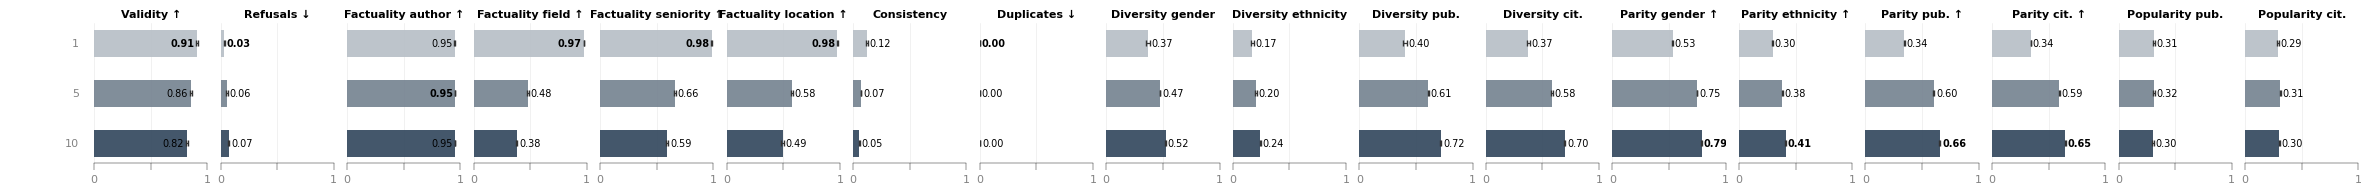

=== Plot 0a.1 — k × Language: values (mean over cells) ===


,section,label,n_cells,validity_mean,validity_ci,refusals_mean,refusals_ci,factuality_mean,factuality_ci,factuality_field_mean,factuality_field_ci,factuality_seniority_mean,factuality_seniority_ci,factuality_location_mean,factuality_location_ci,consistency_mean,consistency_ci,duplicates_mean,duplicates_ci,div_gender_mean,div_gender_ci,div_ethnicity_mean,div_ethnicity_ci,div_productivity_works_mean,div_productivity_works_ci,div_productivity_citations_mean,div_productivity_citations_ci,parity_gender_mean,parity_gender_ci,parity_ethnicity_mean,parity_ethnicity_ci,parity_works_mean,parity_works_ci,parity_citations_mean,parity_citations_ci,popularity_works_mean,popularity_works_ci,popularity_citations_mean,popularity_citations_ci
0,English,k=1,860,0.8851,0.0172,0.0488,0.0112,0.9529,0.0059,0.9620,0.0068,0.9761,0.0050,0.9702,0.0067,0.1062,0.0097,0.0003,0.0002,0.3678,0.0236,0.1755,0.0217,0.4001,0.0241,0.3768,0.0238,0.5474,0.0052,0.3015,0.0053,0.3491,0.0032,0.3486,0.0032,0.3194,0.0133,0.2985,0.0124
1,English,k=5,860,0.8431,0.0179,0.0734,0.0128,0.9552,0.0056,0.4684,0.0092,0.6577,0.0143,0.5786,0.0169,0.0623,0.0062,0.0023,0.0010,0.4634,0.0058,0.1985,0.0095,0.6086,0.0083,0.5869,0.0093,0.7567,0.0055,0.3832,0.0073,0.6097,0.0066,0.5987,0.0067,0.3223,0.0118,0.3177,0.0115
2,English,k=10,860,0.8079,0.0193,0.0881,0.0142,0.9548,0.0056,0.3723,0.0096,0.5932,0.0167,0.4955,0.0197,0.0497,0.0049,0.0047,0.0011,0.5158,0.0053,0.2373,0.0106,0.7223,0.0097,0.7018,0.0107,0.7970,0.0057,0.4104,0.0082,0.6633,0.0079,0.6533,0.0081,0.3092,0.0112,0.3086,0.0110
3,Spanish,k=1,860,0.9429,0.0099,0.0128,0.0044,0.9453,0.0069,0.9828,0.0044,0.9905,0.0031,0.9832,0.0058,0.1350,0.0110,0.0004,0.0002,0.4090,0.0326,0.1814,0.0316,0.4106,0.0347,0.3732,0.0368,0.5117,0.0058,0.2902,0.0053,0.3405,0.0019,0.3401,0.0018,0.2962,0.0135,0.2820,0.0131
4,Spanish,k=5,860,0.8783,0.0156,0.0378,0.0096,0.9520,0.0058,0.4685,0.0086,0.6564,0.0138,0.5604,0.0168,0.0726,0.0069,0.0026,0.0009,0.4853,0.0051,0.2121,0.0095,0.6040,0.0084,0.5816,0.0093,0.7499,0.0058,0.3850,0.0078,0.6104,0.0064,0.6004,0.0066,0.3046,0.0118,0.3036,0.0117
5,Spanish,k=10,860,0.8440,0.0174,0.0460,0.0108,0.9513,0.0056,0.3664,0.0082,0.5845,0.0161,0.4784,0.0194,0.0556,0.0053,0.0043,0.0010,0.5325,0.0046,0.2491,0.0106,0.7144,0.0099,0.6922,0.0109,0.7947,0.0055,0.4129,0.0085,0.6668,0.0075,0.6568,0.0078,0.2936,0.0113,0.2958,0.0111
6,German,k=1,860,0.9007,0.0160,0.0316,0.0092,0.9509,0.0063,0.9760,0.0050,0.9843,0.0041,0.9778,0.0063,0.1251,0.0109,0.0007,0.0003,0.3441,0.0279,0.1625,0.0245,0.3968,0.0269,0.3731,0.0263,0.5345,0.0056,0.2996,0.0053,0.3444,0.0023,0.3434,0.0021,0.3164,0.0134,0.2950,0.0128
7,German,k=5,860,0.8465,0.0179,0.0589,0.0112,0.9542,0.0058,0.5022,0.0110,0.6680,0.0148,0.5904,0.0173,0.0699,0.0063,0.0034,0.0012,0.4704,0.0058,0.2037,0.0095,0.6109,0.0080,0.5861,0.0085,0.7362,0.0068,0.3855,0.0074,0.5897,0.0072,0.5793,0.0072,0.3201,0.0119,0.3153,0.0114
8,German,k=10,860,0.8078,0.0191,0.0765,0.0128,0.9540,0.0056,0.4009,0.0115,0.6032,0.0171,0.5057,0.0201,0.0531,0.0051,0.0048,0.0011,0.5227,0.0052,0.2449,0.0107,0.7226,0.0095,0.6956,0.0106,0.7757,0.0068,0.4118,0.0080,0.6414,0.0084,0.6298,0.0085,0.3088,0.0112,0.3077,0.0108


Saved → ../../../results/new_plots/plot_k_x_language.pdf


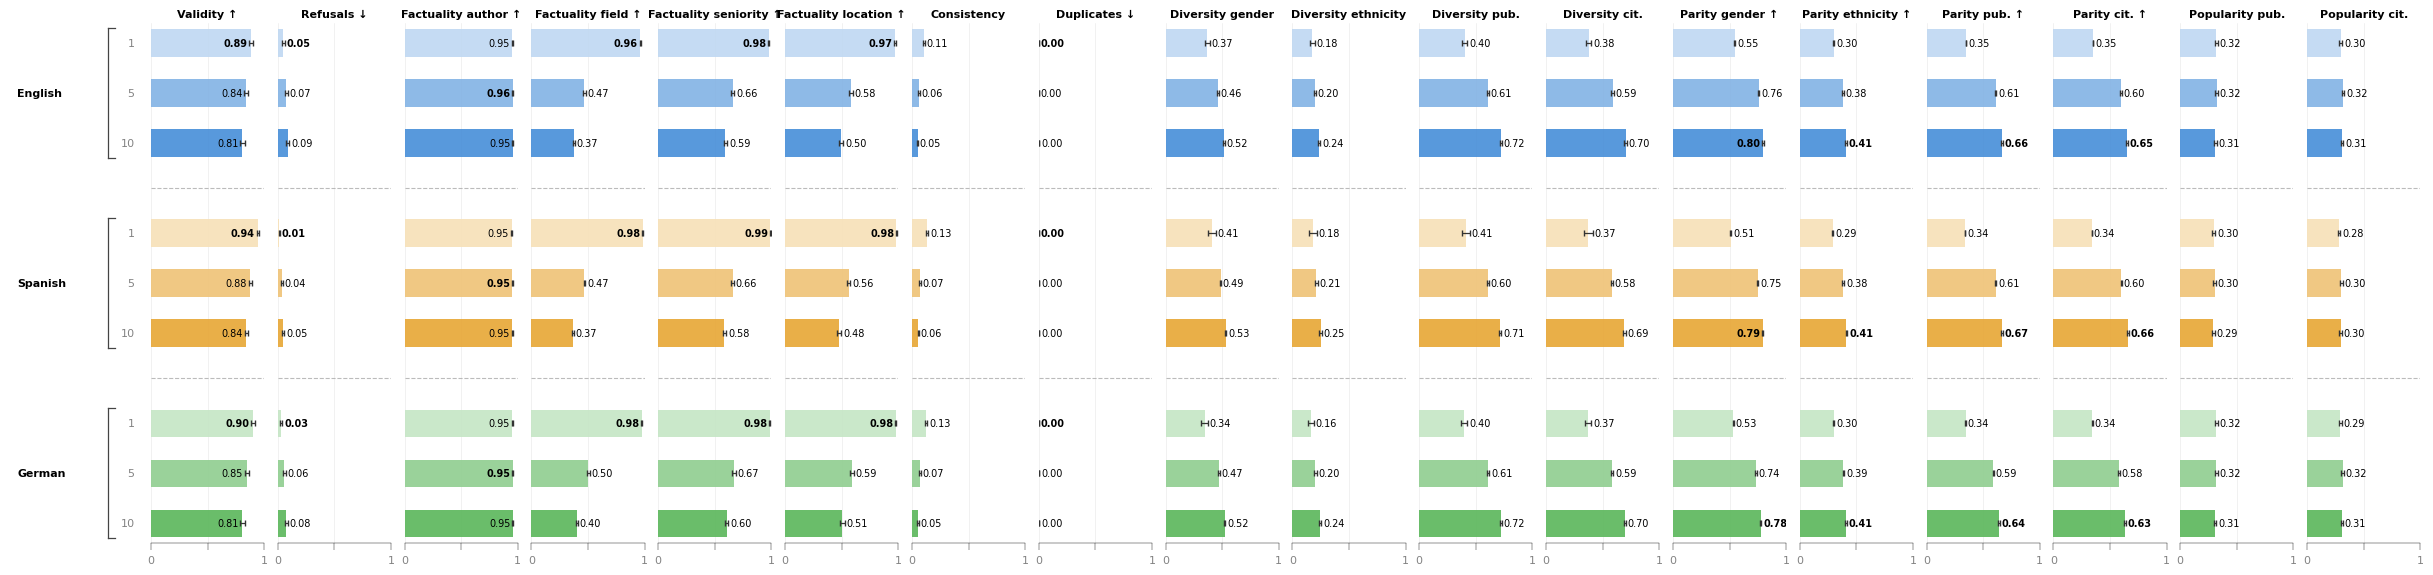

=== Plot 0a.2 — k × Task: values (mean over cells) ===


,section,label,n_cells,validity_mean,validity_ci,refusals_mean,refusals_ci,factuality_mean,factuality_ci,factuality_field_mean,factuality_field_ci,factuality_seniority_mean,factuality_seniority_ci,factuality_location_mean,factuality_location_ci,consistency_mean,consistency_ci,duplicates_mean,duplicates_ci,div_gender_mean,div_gender_ci,div_ethnicity_mean,div_ethnicity_ci,div_productivity_works_mean,div_productivity_works_ci,div_productivity_citations_mean,div_productivity_citations_ci,parity_gender_mean,parity_gender_ci,parity_ethnicity_mean,parity_ethnicity_ci,parity_works_mean,parity_works_ci,parity_citations_mean,parity_citations_ci,popularity_works_mean,popularity_works_ci,popularity_citations_mean,popularity_citations_ci
0,seeking an advisor,k=1,1290,0.9087,0.0120,0.0299,0.0071,0.9450,0.0053,0.9737,0.0046,0.9838,0.0034,0.9789,0.0046,0.1081,0.0081,0.0005,0.0002,0.3346,0.0231,0.1665,0.0213,0.4085,0.0230,0.3760,0.0232,0.5394,0.0042,0.2992,0.0042,0.3442,0.0020,0.3437,0.0020,0.3048,0.0106,0.2877,0.0101
1,seeking an advisor,k=5,1290,0.8502,0.0141,0.0553,0.0090,0.9500,0.0049,0.4753,0.0079,0.6618,0.0115,0.5812,0.0136,0.0601,0.0047,0.0031,0.0009,0.4651,0.0047,0.2021,0.0078,0.6057,0.0066,0.5860,0.0072,0.7495,0.0047,0.3825,0.0058,0.6023,0.0054,0.5935,0.0055,0.3117,0.0095,0.3069,0.0091
2,seeking an advisor,k=10,1290,0.8142,0.0152,0.0660,0.0098,0.9497,0.0048,0.3781,0.0079,0.5949,0.0135,0.4969,0.0159,0.0474,0.0038,0.0049,0.0009,0.5157,0.0042,0.2372,0.0087,0.7194,0.0078,0.6981,0.0087,0.7909,0.0047,0.4093,0.0065,0.6579,0.0064,0.6485,0.0066,0.3014,0.0090,0.2996,0.0087
3,seeking potential hires,k=1,1290,0.9105,0.0122,0.0322,0.0073,0.9543,0.0051,0.9738,0.0044,0.9837,0.0034,0.9750,0.0056,0.1364,0.0091,0.0004,0.0002,0.4011,0.0214,0.1768,0.0195,0.3938,0.0219,0.3734,0.0218,0.5225,0.0049,0.2949,0.0045,0.3450,0.0021,0.3442,0.0020,0.3163,0.0113,0.2957,0.0108
4,seeking potential hires,k=5,1290,0.8617,0.0140,0.0581,0.0095,0.9576,0.0045,0.4839,0.0080,0.6595,0.0118,0.5715,0.0142,0.0765,0.0058,0.0025,0.0008,0.4814,0.0044,0.2076,0.0078,0.6098,0.0069,0.5836,0.0076,0.7457,0.0052,0.3867,0.0064,0.6043,0.0056,0.5922,0.0057,0.3195,0.0098,0.3174,0.0097
5,seeking potential hires,k=10,1290,0.8256,0.0151,0.0743,0.0109,0.9570,0.0043,0.3815,0.0082,0.5922,0.0136,0.4892,0.0164,0.0581,0.0045,0.0043,0.0008,0.5319,0.0039,0.2505,0.0087,0.7200,0.0081,0.6948,0.0089,0.7875,0.0051,0.4141,0.0070,0.6565,0.0066,0.6449,0.0067,0.3062,0.0093,0.3083,0.0092


Saved → ../../../results/new_plots/plot_k_x_task.pdf


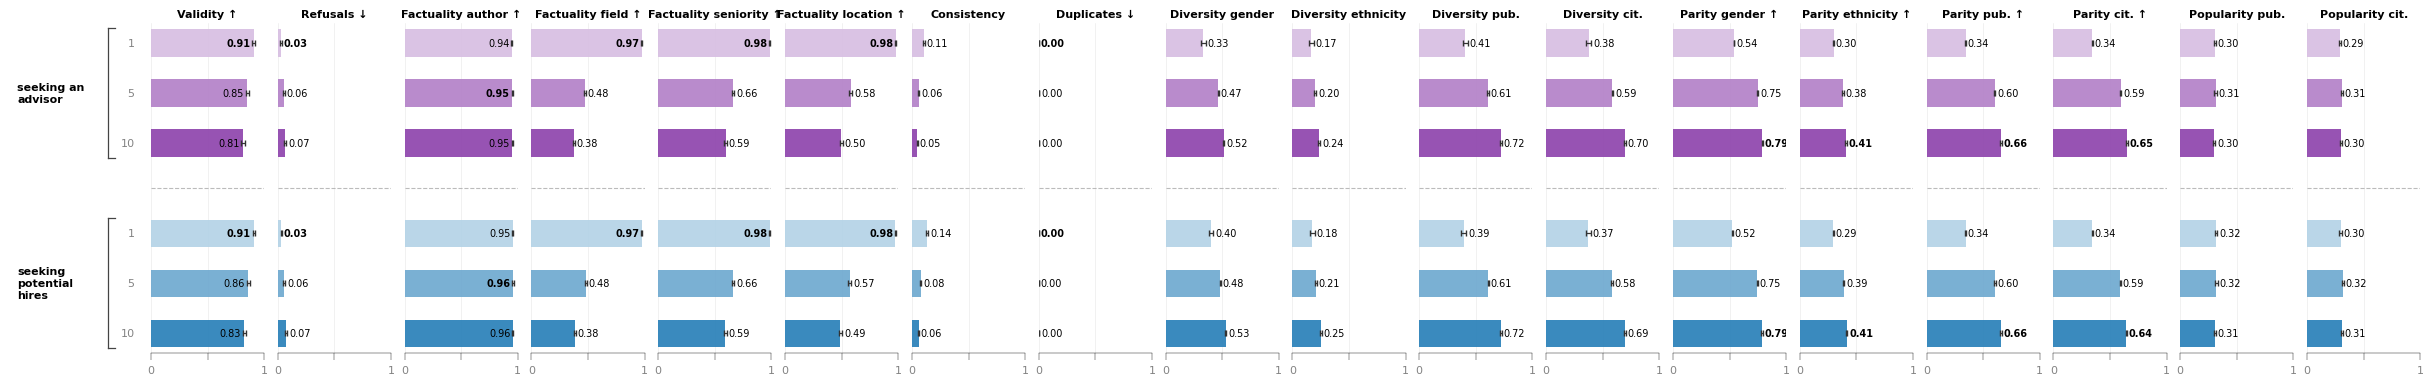

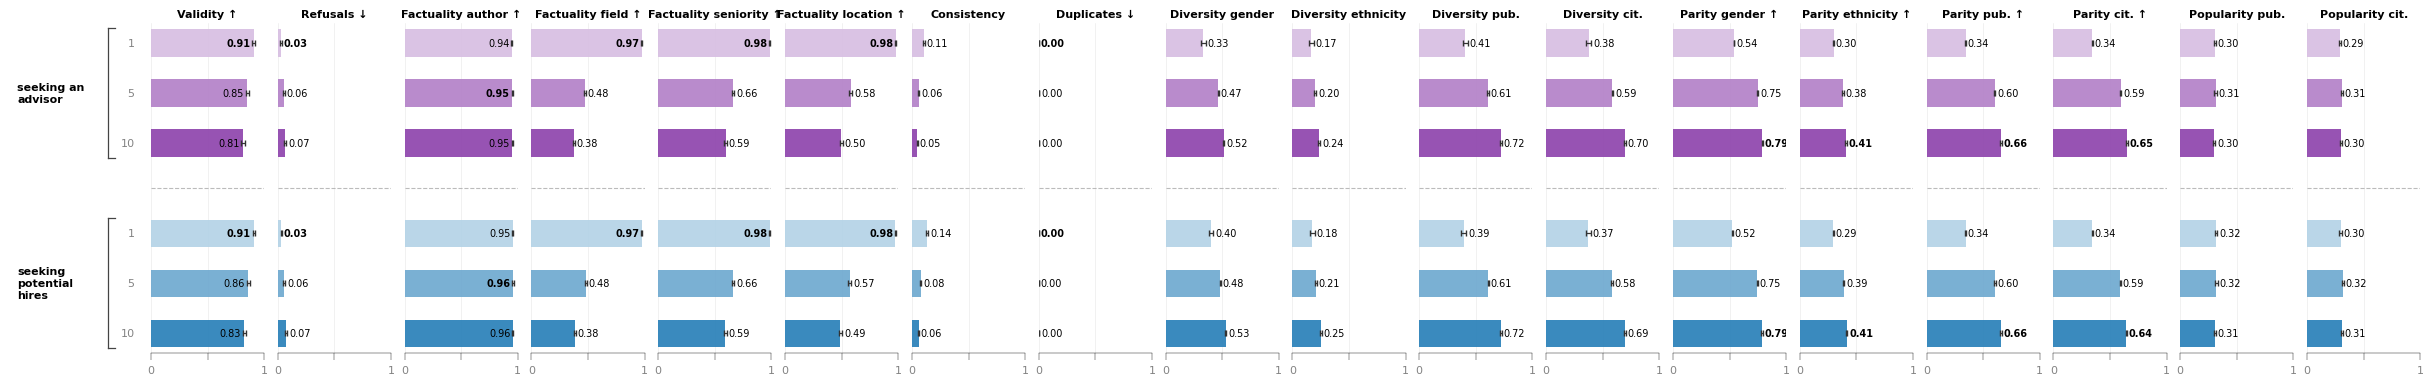

In [16]:
# ── Plot 0 — k (top-k) — first plot, shows effect of requested author count ─
# `k` is NOT in CELL_KEYS so expand per_cell here.
per_cell_k = (calls.groupby(CELL_KEYS + ['k'], dropna=False)[CELL_METRICS]
                    .mean()
                    .reset_index())
K_ORDER = [1, 5, 10]

print('=== Plot 0 — k (top-k): values (mean over cells) ===')
rows = []
for k_val in K_ORDER:
    grp = per_cell_k[per_cell_k['k'] == k_val]
    row = {'section': 'Top-k', 'label': f'k={k_val}', 'n_cells': len(grp)}
    for m in PLOT_METRICS:
        s = grp[m].dropna() if m in grp.columns else pd.Series(dtype=float)
        n = len(s)
        row[f'{m}_mean'] = float(s.mean()) if n else np.nan
        row[f'{m}_ci']   = (float(stats.t.ppf(0.975, df=n - 1) * s.sem())
                            if n >= 2 else np.nan)
    rows.append(row)
display(pd.DataFrame(rows).round(4))

plot_grouped_metrics(
    per_cell_k,
    group_configs=[
        {'label': 'Top-k', 'column': 'k', 'color': '#34495E', 'order': K_ORDER},
    ],
    metrics=PLOT_METRICS,
    metric_directions=PLOT_DIRS,
        metric_labels=PLOT_LABELS,
    save_path=str(PDF_DIR / 'plot_k.pdf'),
)


# ── Plot 0a.1 — k × Language (centered on language) ──────────────────────────
# Section = language; sub-bars = k=1 / k=5 / k=10.
LANGUAGE_ORDER_KX = ['English', 'Spanish', 'German']
LANGUAGE_COLORS_KX = {'English': '#4A90D9', 'Spanish': '#E8A838', 'German': '#5DB85D'}

print('=== Plot 0a.1 — k × Language: values (mean over cells) ===')
rows = []
for lang in LANGUAGE_ORDER_KX:
    sub = per_cell_k[per_cell_k['language'] == lang]
    for k_val in K_ORDER:
        grp = sub[sub['k'] == k_val]
        row = {'section': lang, 'label': f'k={k_val}', 'n_cells': len(grp)}
        for m in PLOT_METRICS:
            s = grp[m].dropna() if m in grp.columns else pd.Series(dtype=float)
            n = len(s)
            row[f'{m}_mean'] = float(s.mean()) if n else np.nan
            row[f'{m}_ci']   = (float(stats.t.ppf(0.975, df=n - 1) * s.sem())
                                if n >= 2 else np.nan)
        rows.append(row)
display(pd.DataFrame(rows).round(4))

plot_grouped_metrics(
    per_cell_k,
    group_configs=[
        {'label': lang, 'column': 'k', 'color': LANGUAGE_COLORS_KX[lang],
         'filter': {'language': lang}, 'order': K_ORDER}
        for lang in LANGUAGE_ORDER_KX
    ],
    metrics=PLOT_METRICS,
    metric_directions=PLOT_DIRS,
    metric_labels=PLOT_LABELS,
    save_path=str(PDF_DIR / 'plot_k_x_language.pdf'),
)

# ── Plot 0a.2 — k × Task (centered on task) ──────────────────────────────────
# Section = task (advisor / hires); sub-bars = k=1 / k=5 / k=10.
# `task` and `k` are both outside CELL_KEYS — expand per_cell with both.
per_cell_k_task = (calls.groupby(CELL_KEYS + ['task_en', 'k'], dropna=False)[CELL_METRICS]
                          .mean()
                          .reset_index())
TASK_ORDER_KX = ['seeking an advisor', 'seeking potential hires']
TASK_COLORS_KX = {'seeking an advisor': '#8E44AD', 'seeking potential hires': '#2980B9'}

print('=== Plot 0a.2 — k × Task: values (mean over cells) ===')
rows = []
for task_val in TASK_ORDER_KX:
    sub = per_cell_k_task[per_cell_k_task['task_en'] == task_val]
    for k_val in K_ORDER:
        grp = sub[sub['k'] == k_val]
        row = {'section': task_val, 'label': f'k={k_val}', 'n_cells': len(grp)}
        for m in PLOT_METRICS:
            s = grp[m].dropna() if m in grp.columns else pd.Series(dtype=float)
            n = len(s)
            row[f'{m}_mean'] = float(s.mean()) if n else np.nan
            row[f'{m}_ci']   = (float(stats.t.ppf(0.975, df=n - 1) * s.sem())
                                if n >= 2 else np.nan)
        rows.append(row)
display(pd.DataFrame(rows).round(4))

plot_grouped_metrics(
    per_cell_k_task,
    group_configs=[
        {'label': task_val, 'column': 'k', 'color': TASK_COLORS_KX[task_val],
         'filter': {'task_en': task_val}, 'order': K_ORDER}
        for task_val in TASK_ORDER_KX
    ],
    metrics=PLOT_METRICS,
    metric_directions=PLOT_DIRS,
    metric_labels=PLOT_LABELS,
    save_path=str(PDF_DIR / 'plot_k_x_task.pdf'),
)


=== Plot 1 — Location × Language: values (mean over cells) ===


,section,label,n_cells,validity_mean,validity_ci,refusals_mean,refusals_ci,factuality_mean,factuality_ci,factuality_field_mean,factuality_field_ci,factuality_seniority_mean,factuality_seniority_ci,factuality_location_mean,factuality_location_ci,consistency_mean,consistency_ci,duplicates_mean,duplicates_ci,div_gender_mean,div_gender_ci,div_ethnicity_mean,div_ethnicity_ci,div_productivity_works_mean,div_productivity_works_ci,div_productivity_citations_mean,div_productivity_citations_ci,parity_gender_mean,parity_gender_ci,parity_ethnicity_mean,parity_ethnicity_ci,parity_works_mean,parity_works_ci,parity_citations_mean,parity_citations_ci,popularity_works_mean,popularity_works_ci,popularity_citations_mean,popularity_citations_ci
0,Ecuador,English,172,0.8345,0.0407,0.0810,0.0295,0.9869,0.0027,0.5163,0.0174,0.6506,0.0273,0.3391,0.0259,0.0456,0.0128,0.0013,0.0009,0.5387,0.0083,0.2450,0.0153,0.6538,0.0195,0.6275,0.0211,0.7187,0.0093,0.3045,0.0128,0.5336,0.0113,0.5246,0.0112,0.2085,0.0187,0.2217,0.0211
1,Ecuador,Spanish,172,0.8803,0.0318,0.0375,0.0195,0.9800,0.0064,0.5404,0.0214,0.6595,0.0279,0.3213,0.0256,0.0668,0.0157,0.0015,0.0008,0.5589,0.0067,0.2376,0.0182,0.6354,0.0224,0.6063,0.0242,0.6940,0.0137,0.3017,0.0129,0.5194,0.0115,0.5111,0.0115,0.1958,0.0177,0.2242,0.0229
2,Ecuador,German,172,0.8419,0.0392,0.0640,0.0245,0.9801,0.0070,0.5610,0.0223,0.6618,0.0297,0.3555,0.0300,0.0590,0.0140,0.0028,0.0019,0.5463,0.0081,0.2498,0.0180,0.6438,0.0222,0.6139,0.0240,0.6922,0.0133,0.2997,0.0126,0.5114,0.0122,0.5020,0.0121,0.2124,0.0181,0.2265,0.0212
3,Germany,English,172,0.8491,0.0387,0.0646,0.0271,0.9681,0.0059,0.5012,0.0223,0.6807,0.0348,0.7119,0.0163,0.0811,0.0157,0.0037,0.0031,0.4836,0.0123,0.2306,0.0150,0.6899,0.0158,0.6693,0.0155,0.6964,0.0097,0.4381,0.0107,0.5505,0.0122,0.5431,0.0119,0.3342,0.0225,0.3169,0.0225
4,Germany,Spanish,172,0.8939,0.0290,0.0284,0.0164,0.9634,0.0087,0.4928,0.0204,0.6746,0.0335,0.6856,0.0183,0.0922,0.0167,0.0020,0.0011,0.5105,0.0105,0.2606,0.0152,0.6939,0.0148,0.6691,0.0146,0.6801,0.0115,0.4350,0.0128,0.5503,0.0111,0.5415,0.0108,0.3171,0.0225,0.3076,0.0221
5,Germany,German,172,0.8483,0.0379,0.0528,0.0228,0.9557,0.0103,0.5274,0.0238,0.6870,0.0355,0.7400,0.0159,0.0883,0.0155,0.0030,0.0014,0.4865,0.0126,0.2419,0.0168,0.6885,0.0158,0.6599,0.0160,0.6747,0.0129,0.4386,0.0116,0.5315,0.0127,0.5232,0.0123,0.3157,0.0236,0.2954,0.0221
6,Japan,English,172,0.8555,0.0384,0.0653,0.0272,0.9914,0.0021,0.5372,0.0185,0.6598,0.0440,0.9170,0.0059,0.0722,0.0134,0.0023,0.0010,0.4384,0.0141,0.0198,0.0054,0.7126,0.0125,0.7367,0.0120,0.7137,0.0091,0.3750,0.0017,0.5516,0.0118,0.5613,0.0121,0.5058,0.0176,0.4232,0.0180
7,Japan,Spanish,172,0.8985,0.0280,0.0313,0.0179,0.9830,0.0076,0.5523,0.0192,0.6609,0.0421,0.9079,0.0107,0.0970,0.0179,0.0020,0.0009,0.4743,0.0122,0.0363,0.0098,0.7196,0.0133,0.7393,0.0138,0.6957,0.0102,0.3691,0.0064,0.5519,0.0109,0.5599,0.0111,0.4832,0.0201,0.3984,0.0191
8,Japan,German,172,0.8677,0.0362,0.0522,0.0231,0.9851,0.0063,0.5729,0.0216,0.6768,0.0428,0.9119,0.0113,0.0839,0.0169,0.0020,0.0009,0.4563,0.0137,0.0290,0.0068,0.7082,0.0136,0.7289,0.0137,0.6952,0.0099,0.3732,0.0039,0.5320,0.0125,0.5401,0.0129,0.5098,0.0203,0.4268,0.0207
9,Canada,English,172,0.8480,0.0395,0.0709,0.0290,0.9744,0.0048,0.4880,0.0208,0.6796,0.0313,0.4023,0.0288,0.1089,0.0167,0.0026,0.0016,0.5062,0.0081,0.3176,0.0153,0.7047,0.0099,0.6602,0.0149,0.7017,0.0102,0.4185,0.0135,0.5565,0.0110,0.5406,0.0112,0.3652,0.0202,0.4087,0.0235


Saved → ../../../results/new_plots/plot_location_x_language.pdf


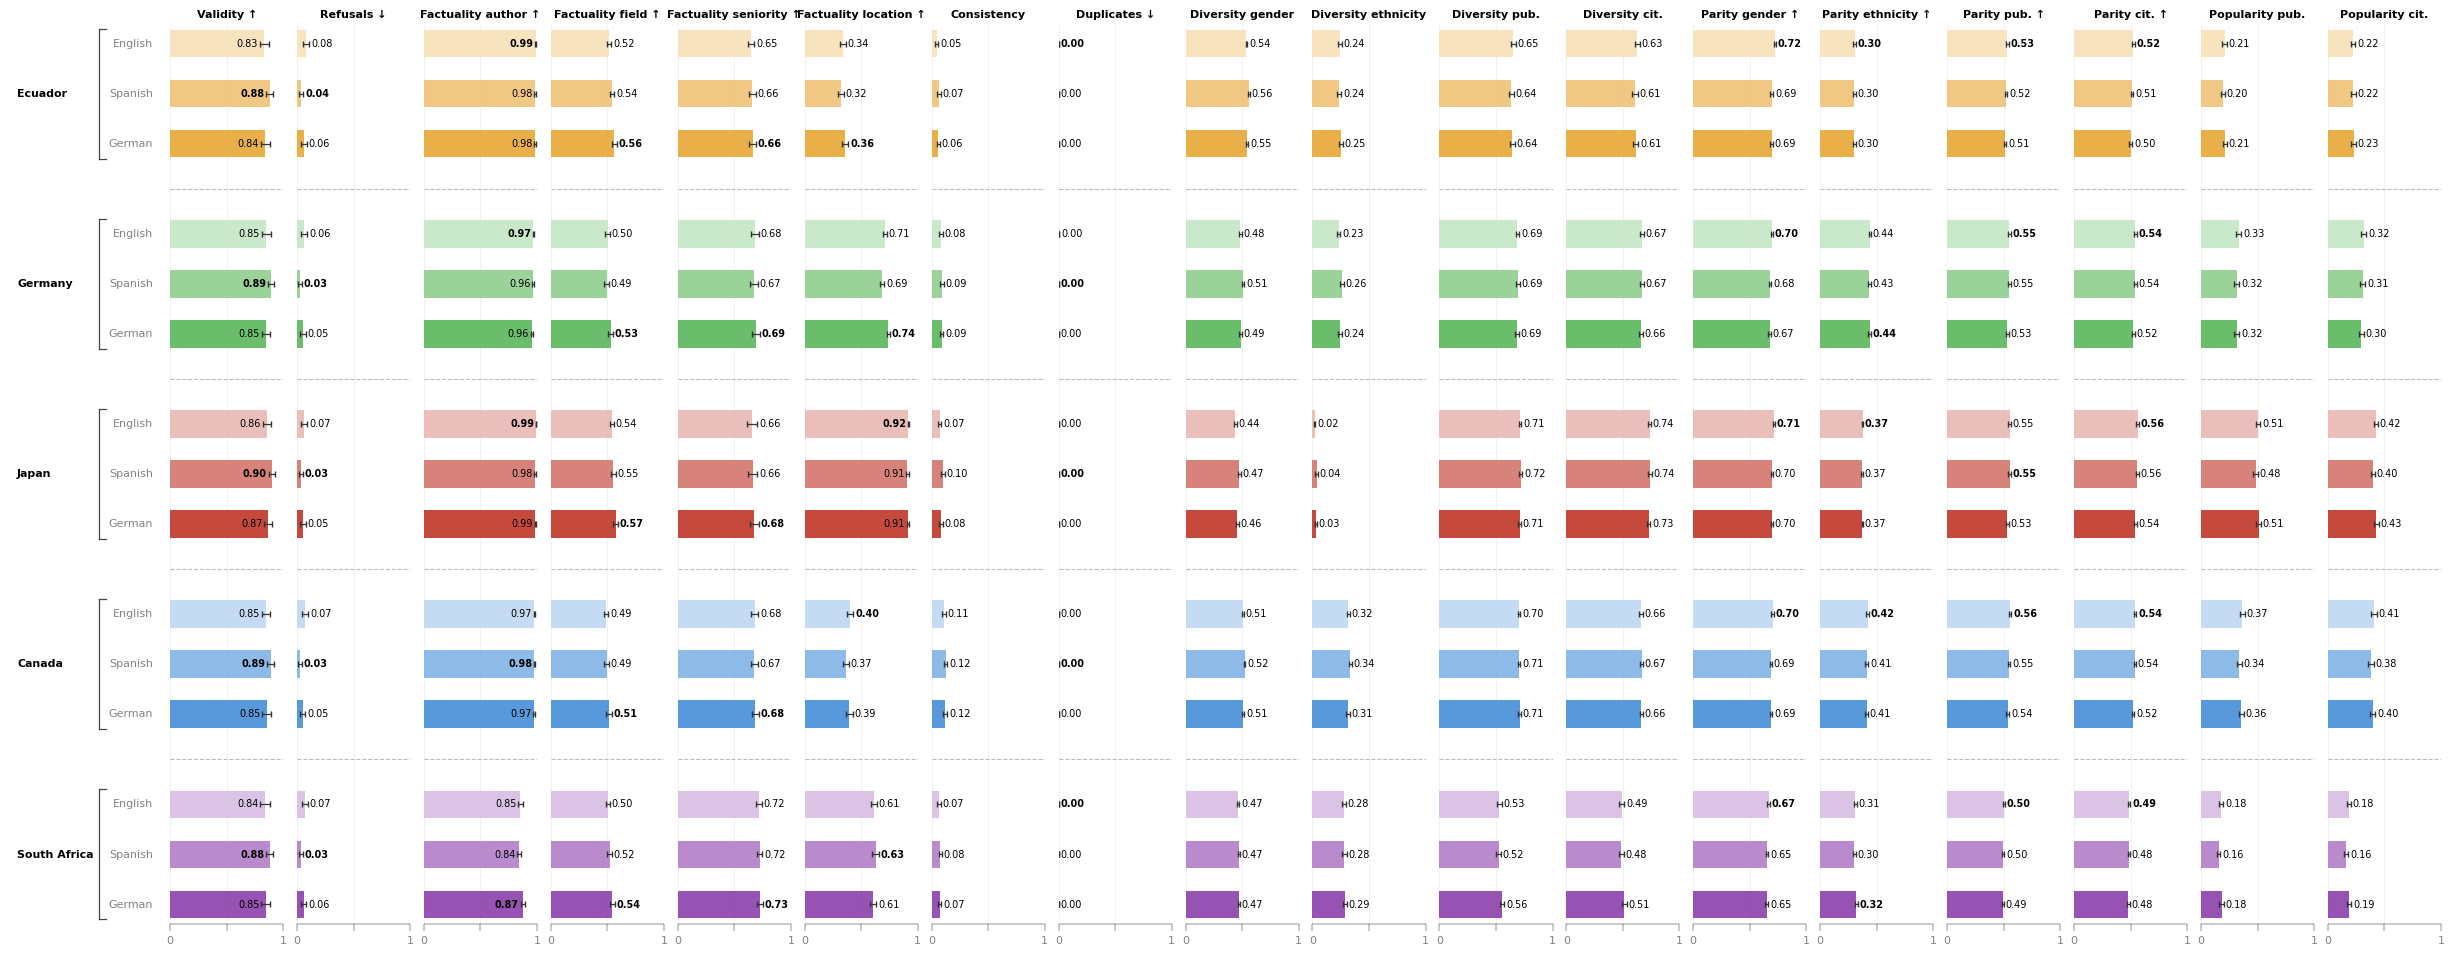

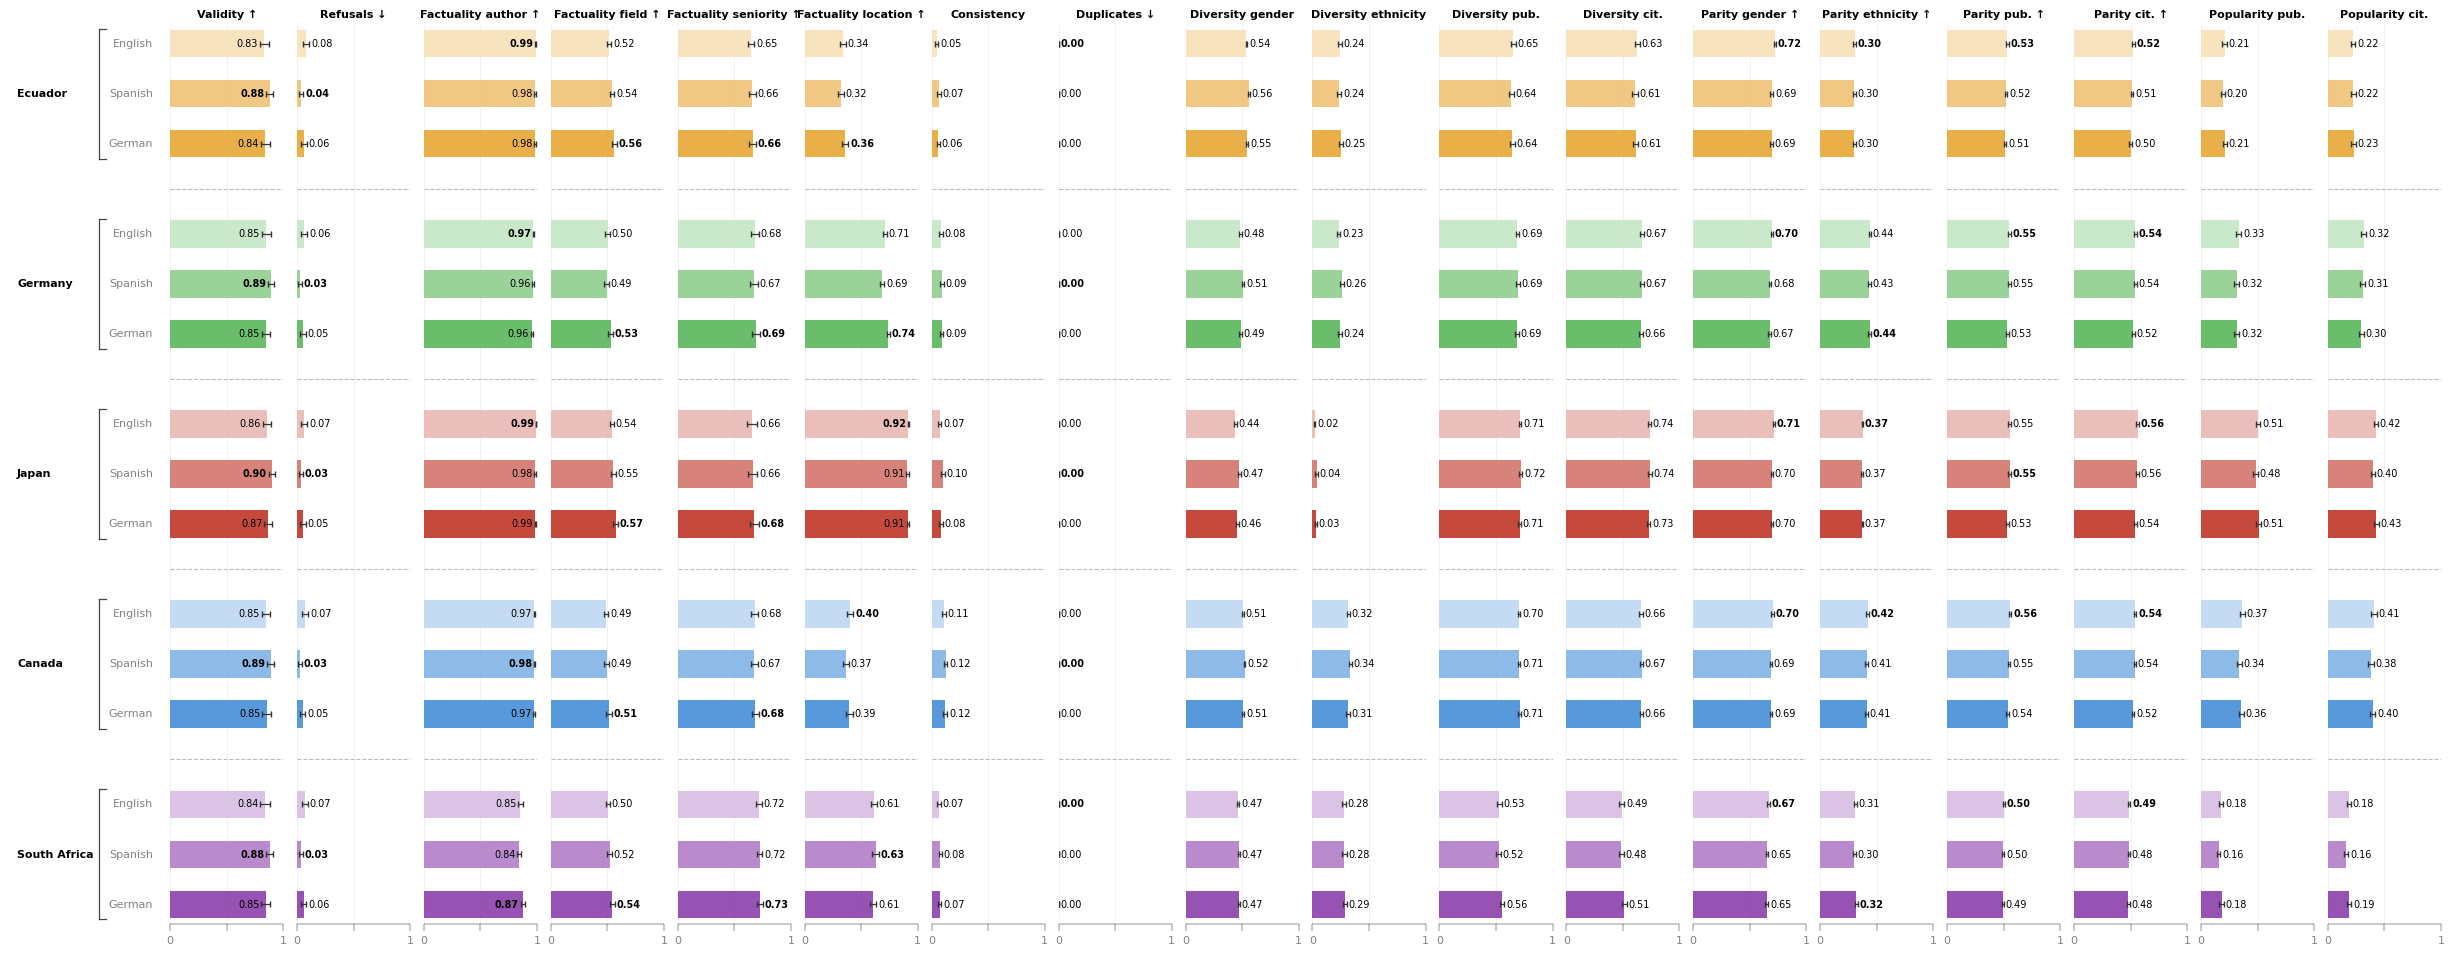

In [17]:
# ── Métricas y direcciones compartidas por todos los plots ────────────────────


LOCATION_ORDER = ['Ecuador', 'Germany', 'Japan', 'Canada', 'South Africa']

LOCATION_COLORS = {
    'Ecuador': '#E8A838',  'Germany': '#5DB85D',  'Japan':  '#C0392B',
    'Canada':  '#4A90D9',  'South Africa': '#8E44AD',
}

# ── Plot 1 — Location × Language ─────────────────────────────────────────────
# Section = canonical location; rows inside = the 3 languages literally
# (English / Spanish / German). Data already keyed by `language` in CELL_KEYS.
print('=== Plot 1 — Location × Language: values (mean over cells) ===')
rows = []
for loc in LOCATION_ORDER:
    sub = per_cell[per_cell['location'] == loc]
    for lang in LANGUAGE_ORDER:
        grp = sub[sub['language'] == lang]
        row = {'section': loc, 'label': lang, 'n_cells': len(grp)}
        for m in PLOT_METRICS:
            s = grp[m].dropna()
            n = len(s)
            row[f'{m}_mean'] = float(s.mean()) if n else np.nan
            row[f'{m}_ci']   = (float(stats.t.ppf(0.975, df=n - 1) * s.sem())
                                if n >= 2 else np.nan)
        rows.append(row)
display(pd.DataFrame(rows).round(4))

plot_grouped_metrics(
    per_cell,
    group_configs=[
        {'label': loc, 'column': 'language', 'color': LOCATION_COLORS[loc],
         'filter': {'location': loc}, 'order': LANGUAGE_ORDER}
        for loc in LOCATION_ORDER
    ],
    metrics=PLOT_METRICS,
    metric_directions=PLOT_DIRS,
        metric_labels=PLOT_LABELS,
    save_path=str(PDF_DIR / 'plot_location_x_language.pdf'),
)


=== Plot 2 — Language: values (mean over cells) ===


,section,label,n_cells,validity_mean,validity_ci,refusals_mean,refusals_ci,factuality_mean,factuality_ci,factuality_field_mean,factuality_field_ci,factuality_seniority_mean,factuality_seniority_ci,factuality_location_mean,factuality_location_ci,consistency_mean,consistency_ci,duplicates_mean,duplicates_ci,div_gender_mean,div_gender_ci,div_ethnicity_mean,div_ethnicity_ci,div_productivity_works_mean,div_productivity_works_ci,div_productivity_citations_mean,div_productivity_citations_ci,parity_gender_mean,parity_gender_ci,parity_ethnicity_mean,parity_ethnicity_ci,parity_works_mean,parity_works_ci,parity_citations_mean,parity_citations_ci,popularity_works_mean,popularity_works_ci,popularity_citations_mean,popularity_citations_ci
0,Language,English,860,0.8454,0.0176,0.0701,0.0124,0.9548,0.0055,0.5092,0.0089,0.6772,0.0148,0.5969,0.0175,0.0748,0.0067,0.0025,0.0008,0.4866,0.0054,0.2180,0.0097,0.6580,0.0086,0.6365,0.0097,0.6996,0.0046,0.3697,0.0064,0.5387,0.0052,0.5314,0.0053,0.3188,0.0118,0.3113,0.0114
1,Language,German,860,0.8517,0.0170,0.0557,0.0104,0.9535,0.0057,0.5438,0.0104,0.6874,0.0151,0.6039,0.0180,0.0849,0.0071,0.0026,0.0006,0.4945,0.0053,0.2246,0.0100,0.6610,0.0085,0.6353,0.0093,0.6799,0.0056,0.3684,0.0065,0.5210,0.0056,0.5136,0.0055,0.3156,0.0119,0.3063,0.0113
2,Language,Spanish,860,0.8884,0.0134,0.0322,0.0079,0.9493,0.0059,0.5196,0.0093,0.6786,0.0144,0.5830,0.0176,0.0913,0.0074,0.0021,0.0005,0.5076,0.0047,0.2306,0.0099,0.6558,0.0090,0.6333,0.0099,0.6817,0.0052,0.3639,0.0067,0.5334,0.0050,0.5267,0.0051,0.2986,0.0115,0.2947,0.0112


Saved → ../../../results/new_plots/plot_language.pdf


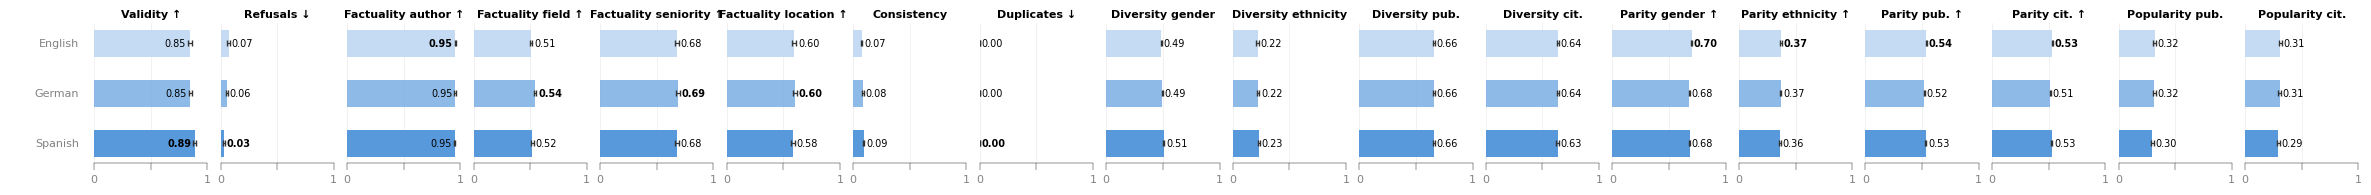

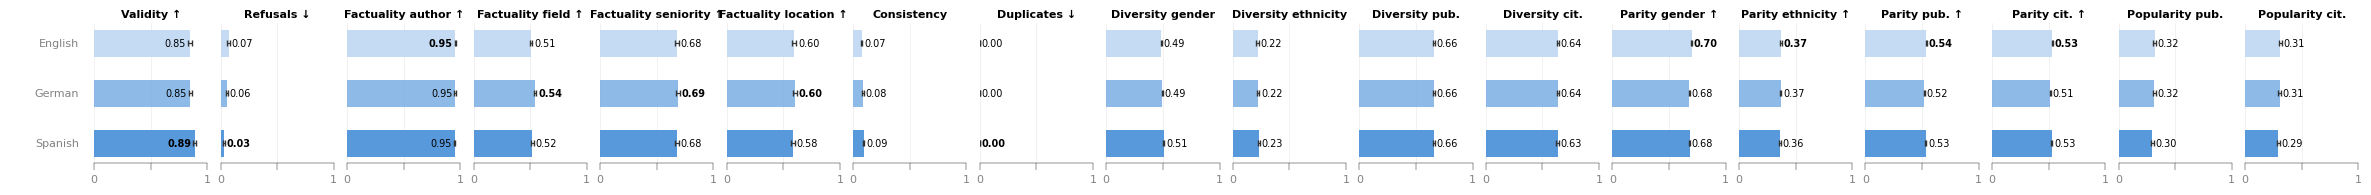

In [18]:

# ── Plot 2 — Language ────────────────────────────────────────────────────────
print('=== Plot 2 — Language: values (mean over cells) ===')
rows = []
for lang in ['English', 'German', 'Spanish']:
    grp = per_cell[per_cell['language'] == lang]
    row = {'section': 'Language', 'label': lang, 'n_cells': len(grp)}
    for m in PLOT_METRICS:
        s = grp[m].dropna()
        n = len(s)
        row[f'{m}_mean'] = float(s.mean()) if n else np.nan
        row[f'{m}_ci']   = (float(stats.t.ppf(0.975, df=n - 1) * s.sem())
                            if n >= 2 else np.nan)
    rows.append(row)
display(pd.DataFrame(rows).round(4))

plot_grouped_metrics(
    per_cell,
    group_configs=[
        {'label': 'Language', 'column': 'language', 'color': '#4A90D9',
         'order': ['English', 'German', 'Spanish']},
    ],
    metrics=PLOT_METRICS,
    metric_directions=PLOT_DIRS,
        metric_labels=PLOT_LABELS,
    save_path=str(PDF_DIR / 'plot_language.pdf'),
)


=== Plot 3 — Location: values (mean over cells) ===


,section,label,n_cells,validity_mean,validity_ci,refusals_mean,refusals_ci,factuality_mean,factuality_ci,factuality_field_mean,factuality_field_ci,factuality_seniority_mean,factuality_seniority_ci,factuality_location_mean,factuality_location_ci,consistency_mean,consistency_ci,duplicates_mean,duplicates_ci,div_gender_mean,div_gender_ci,div_ethnicity_mean,div_ethnicity_ci,div_productivity_works_mean,div_productivity_works_ci,div_productivity_citations_mean,div_productivity_citations_ci,parity_gender_mean,parity_gender_ci,parity_ethnicity_mean,parity_ethnicity_ci,parity_works_mean,parity_works_ci,parity_citations_mean,parity_citations_ci,popularity_works_mean,popularity_works_ci,popularity_citations_mean,popularity_citations_ci
0,Location,Ecuador,516,0.8522,0.0215,0.0608,0.0143,0.9823,0.0033,0.5393,0.0118,0.6573,0.0162,0.3384,0.0156,0.0573,0.0082,0.0019,0.0007,0.5481,0.0045,0.2441,0.0099,0.6442,0.0123,0.6158,0.0133,0.7016,0.0071,0.3020,0.0073,0.5215,0.0067,0.5126,0.0067,0.2054,0.0104,0.2241,0.0125
1,Location,Germany,516,0.8638,0.0204,0.0486,0.0130,0.9624,0.0049,0.5070,0.0128,0.6807,0.0199,0.7122,0.0099,0.0873,0.0092,0.0029,0.0012,0.4938,0.0068,0.2446,0.0091,0.6908,0.0089,0.6661,0.0088,0.6837,0.0066,0.4372,0.0067,0.5442,0.0069,0.5360,0.0067,0.3223,0.0131,0.3066,0.0128
2,Location,Japan,516,0.8739,0.0198,0.0496,0.0132,0.9865,0.0034,0.5541,0.0114,0.6658,0.0246,0.9122,0.0055,0.0845,0.0094,0.0021,0.0005,0.4566,0.0078,0.0285,0.0044,0.7135,0.0076,0.7350,0.0076,0.7015,0.0056,0.3724,0.0026,0.5453,0.0068,0.5538,0.0070,0.4994,0.0112,0.4160,0.0111
3,Location,Canada,516,0.8634,0.0210,0.0503,0.0134,0.9746,0.0035,0.4982,0.0123,0.6792,0.0180,0.3864,0.0160,0.1179,0.0096,0.0023,0.0007,0.5135,0.0044,0.3219,0.0090,0.7070,0.0057,0.6631,0.0075,0.6923,0.0062,0.4134,0.0079,0.5475,0.0066,0.5330,0.0065,0.3540,0.0114,0.3948,0.0134
4,Location,South Africa,516,0.8559,0.0216,0.0539,0.0134,0.8566,0.0110,0.5225,0.0129,0.7224,0.0146,0.6140,0.0159,0.0715,0.0087,0.0027,0.0007,0.4698,0.0057,0.2827,0.0108,0.5359,0.0119,0.4954,0.0126,0.6560,0.0071,0.3105,0.0087,0.4967,0.0061,0.4841,0.0061,0.1724,0.0098,0.1777,0.0110


Saved → ../../../results/new_plots/plot_location.pdf


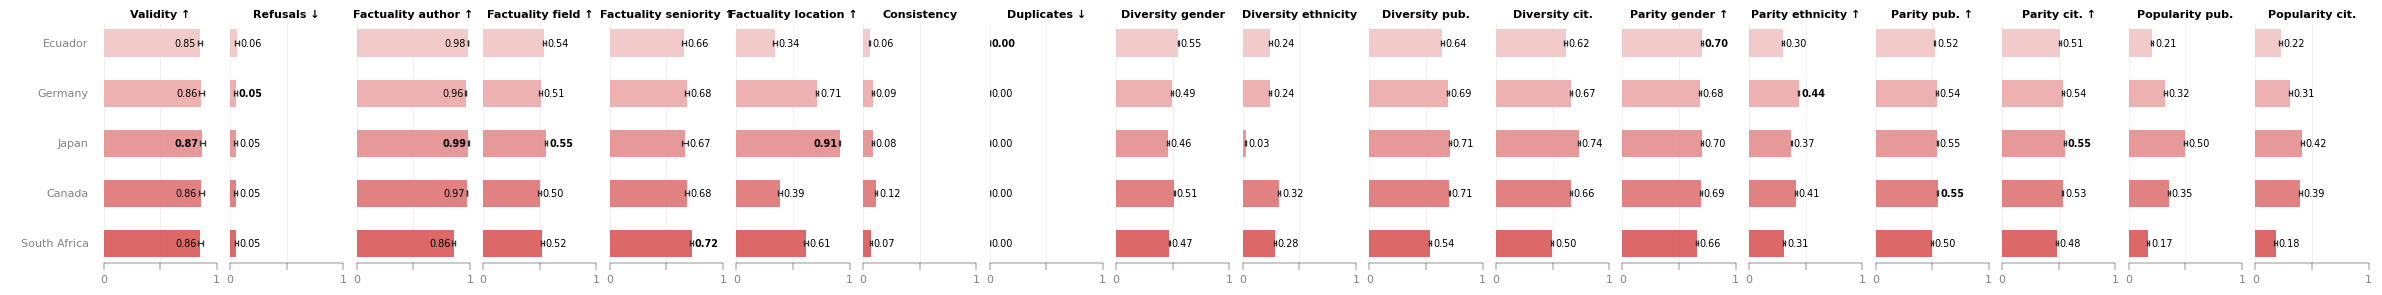

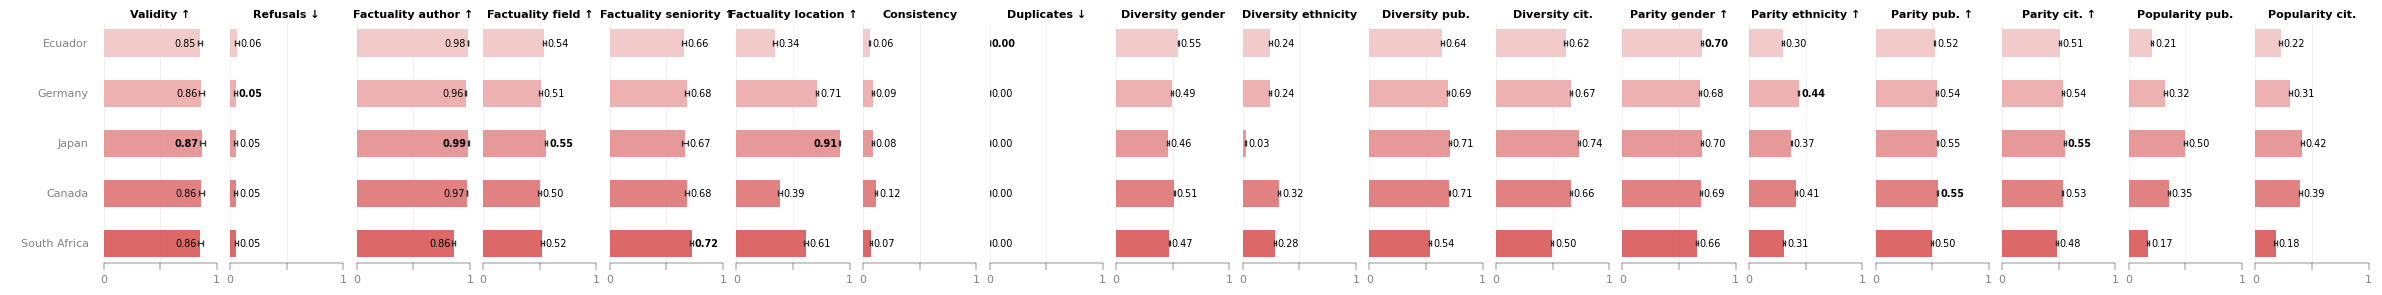

In [19]:

# ── Plot 3 — Location (todos los idiomas combinados) ─────────────────────────
print('=== Plot 3 — Location: values (mean over cells) ===')
rows = []
for loc in LOCATION_ORDER:
    grp = per_cell[per_cell['location'] == loc]
    row = {'section': 'Location', 'label': loc, 'n_cells': len(grp)}
    for m in PLOT_METRICS:
        s = grp[m].dropna()
        n = len(s)
        row[f'{m}_mean'] = float(s.mean()) if n else np.nan
        row[f'{m}_ci']   = (float(stats.t.ppf(0.975, df=n - 1) * s.sem())
                            if n >= 2 else np.nan)
    rows.append(row)
display(pd.DataFrame(rows).round(4))

plot_grouped_metrics(
    per_cell,
    group_configs=[
        {'label': 'Location', 'column': 'location', 'color': '#D95B5B',
         'order': LOCATION_ORDER},
    ],
    metrics=PLOT_METRICS,
    metric_directions=PLOT_DIRS,
        metric_labels=PLOT_LABELS,
    save_path=str(PDF_DIR / 'plot_location.pdf'),
)


Plot 4 — per_cell expanded with task_en: 2,580 cells
=== Plot 4 — Task: values (mean over cells) ===


,section,label,n_cells,validity_mean,validity_ci,refusals_mean,refusals_ci,factuality_mean,factuality_ci,factuality_field_mean,factuality_field_ci,factuality_seniority_mean,factuality_seniority_ci,factuality_location_mean,factuality_location_ci,consistency_mean,consistency_ci,duplicates_mean,duplicates_ci,div_gender_mean,div_gender_ci,div_ethnicity_mean,div_ethnicity_ci,div_productivity_works_mean,div_productivity_works_ci,div_productivity_citations_mean,div_productivity_citations_ci,parity_gender_mean,parity_gender_ci,parity_ethnicity_mean,parity_ethnicity_ci,parity_works_mean,parity_works_ci,parity_citations_mean,parity_citations_ci,popularity_works_mean,popularity_works_ci,popularity_citations_mean,popularity_citations_ci
0,Task,seeking an advisor,1290,0.8577,0.0132,0.0504,0.0082,0.9485,0.0048,0.5221,0.0078,0.6842,0.0119,0.6006,0.0140,0.0746,0.0054,0.0026,0.0005,0.4881,0.0043,0.2200,0.0080,0.6572,0.0070,0.6367,0.0078,0.6906,0.0041,0.3664,0.0051,0.5314,0.0043,0.5252,0.0044,0.3067,0.0094,0.2994,0.0090
1,Task,seeking potential hires,1290,0.8660,0.0132,0.0549,0.0088,0.9566,0.0045,0.5261,0.0079,0.6779,0.0122,0.5882,0.0149,0.0930,0.0062,0.0022,0.0005,0.5047,0.0040,0.2291,0.0081,0.6593,0.0072,0.6333,0.0079,0.6834,0.0044,0.3681,0.0056,0.5307,0.0044,0.5226,0.0044,0.3151,0.0098,0.3085,0.0095


Saved → ../../../results/new_plots/plot_task.pdf


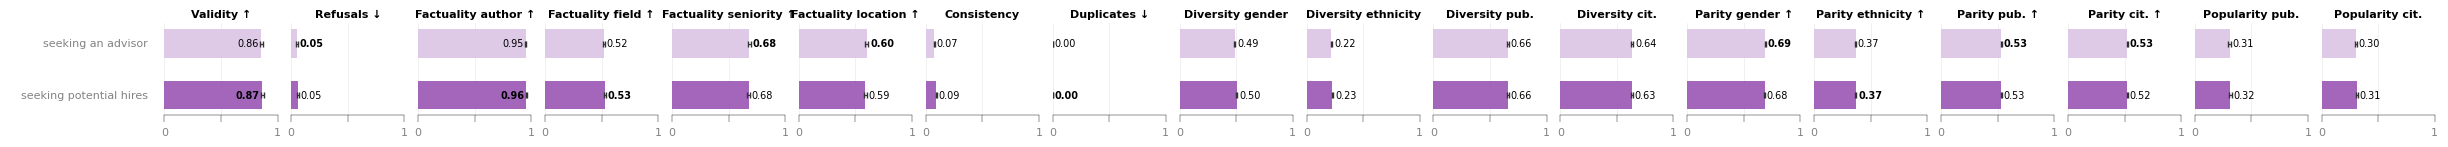

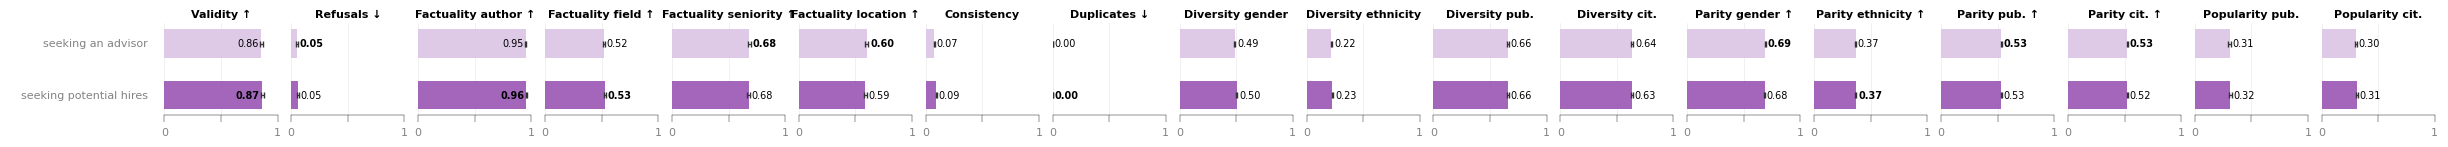

In [20]:

# ── Plot 4 — Task (all languages combined) ───────────────────────────────────
# `task` is NOT in CELL_KEYS, so build a per_cell expanded with task_en here.
per_cell_task = (calls.groupby(CELL_KEYS + ['task_en'], dropna=False)[CELL_METRICS]
                       .mean()
                       .reset_index())
print(f'Plot 4 — per_cell expanded with task_en: {len(per_cell_task):,} cells')

print('=== Plot 4 — Task: values (mean over cells) ===')
rows = []
for task_val in ['seeking an advisor', 'seeking potential hires']:
    grp = per_cell_task[per_cell_task['task_en'] == task_val]
    row = {'section': 'Task', 'label': task_val, 'n_cells': len(grp)}
    for m in PLOT_METRICS:
        s = grp[m].dropna()
        n = len(s)
        row[f'{m}_mean'] = float(s.mean()) if n else np.nan
        row[f'{m}_ci']   = (float(stats.t.ppf(0.975, df=n - 1) * s.sem())
                            if n >= 2 else np.nan)
    rows.append(row)
display(pd.DataFrame(rows).round(4))

plot_grouped_metrics(
    per_cell_task,
    group_configs=[
        {'label': 'Task', 'column': 'task_en', 'color': '#9B59B6',
         'order': ['seeking an advisor', 'seeking potential hires']},
    ],
    metrics=PLOT_METRICS,
    metric_directions=PLOT_DIRS,
        metric_labels=PLOT_LABELS,
    save_path=str(PDF_DIR / 'plot_task.pdf'),
)


Plot 5 — per_cell expanded with field_en: 15,480 cells
=== Plot 5 — Field: values (mean over cells) ===


,section,label,n_cells,validity_mean,validity_ci,refusals_mean,refusals_ci,factuality_mean,factuality_ci,factuality_field_mean,factuality_field_ci,factuality_seniority_mean,factuality_seniority_ci,factuality_location_mean,factuality_location_ci,consistency_mean,consistency_ci,duplicates_mean,duplicates_ci,div_gender_mean,div_gender_ci,div_ethnicity_mean,div_ethnicity_ci,div_productivity_works_mean,div_productivity_works_ci,div_productivity_citations_mean,div_productivity_citations_ci,parity_gender_mean,parity_gender_ci,parity_ethnicity_mean,parity_ethnicity_ci,parity_works_mean,parity_works_ci,parity_citations_mean,parity_citations_ci,popularity_works_mean,popularity_works_ci,popularity_citations_mean,popularity_citations_ci
0,Field,Biology,2580,0.8623,0.0095,0.0536,0.0061,0.9570,0.0032,0.6238,0.0056,0.6703,0.0089,0.5839,0.0113,0.0769,0.0044,0.0020,0.0004,0.5140,0.0033,0.2156,0.0063,0.6630,0.0058,0.6330,0.0063,0.6839,0.0035,0.3669,0.0040,0.5334,0.0033,0.5241,0.0033,0.3123,0.0077,0.2973,0.0076
1,Field,Computer Science,2580,0.8695,0.0093,0.0495,0.0061,0.9558,0.0034,0.3077,0.0073,0.6789,0.0088,0.5945,0.0109,0.1073,0.0055,0.0027,0.0005,0.4714,0.0046,0.2426,0.0066,0.6348,0.0064,0.6216,0.0066,0.7048,0.0031,0.3673,0.0040,0.5240,0.0032,0.5209,0.0033,0.3152,0.0090,0.3081,0.0083
2,Field,Mathematics,2580,0.8544,0.0095,0.0547,0.0061,0.9582,0.0031,0.2882,0.0086,0.6807,0.0089,0.5620,0.0113,0.0919,0.0050,0.0026,0.0004,0.4593,0.0047,0.2385,0.0065,0.6826,0.0056,0.6546,0.0059,0.7051,0.0030,0.3768,0.0039,0.5378,0.0033,0.5286,0.0033,0.3111,0.0062,0.3095,0.0064
3,Field,Physics,2580,0.8599,0.0094,0.0529,0.0061,0.9481,0.0037,0.3168,0.0084,0.6776,0.0089,0.5890,0.0114,0.0787,0.0046,0.0018,0.0004,0.4858,0.0039,0.2134,0.0061,0.6510,0.0057,0.6314,0.0062,0.6979,0.0032,0.3656,0.0040,0.5305,0.0032,0.5249,0.0032,0.3083,0.0076,0.2997,0.0073
4,Field,Psychology,2580,0.8630,0.0094,0.0519,0.0060,0.9492,0.0036,0.3059,0.0083,0.6785,0.0088,0.5948,0.0107,0.0732,0.0043,0.0029,0.0006,0.5231,0.0030,0.2132,0.0063,0.6618,0.0054,0.6357,0.0060,0.6750,0.0035,0.3663,0.0039,0.5349,0.0032,0.5262,0.0032,0.3071,0.0074,0.2978,0.0073
5,Field,Sociology,2580,0.8619,0.0095,0.0534,0.0061,0.9451,0.0041,0.5742,0.0063,0.6775,0.0087,0.6127,0.0110,0.0738,0.0043,0.0024,0.0005,0.5228,0.0030,0.2127,0.0063,0.6576,0.0060,0.6363,0.0064,0.6584,0.0035,0.3614,0.0041,0.5334,0.0032,0.5265,0.0033,0.3041,0.0072,0.3023,0.0072


Saved → ../../../results/new_plots/plot_field.pdf


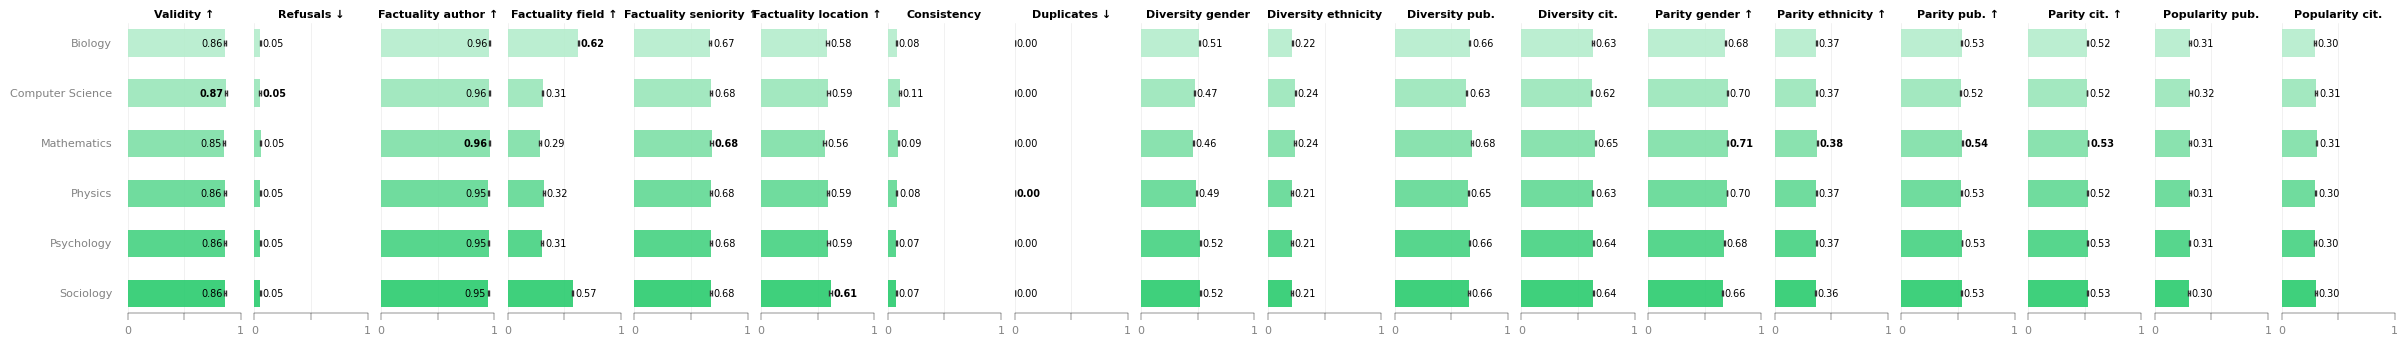

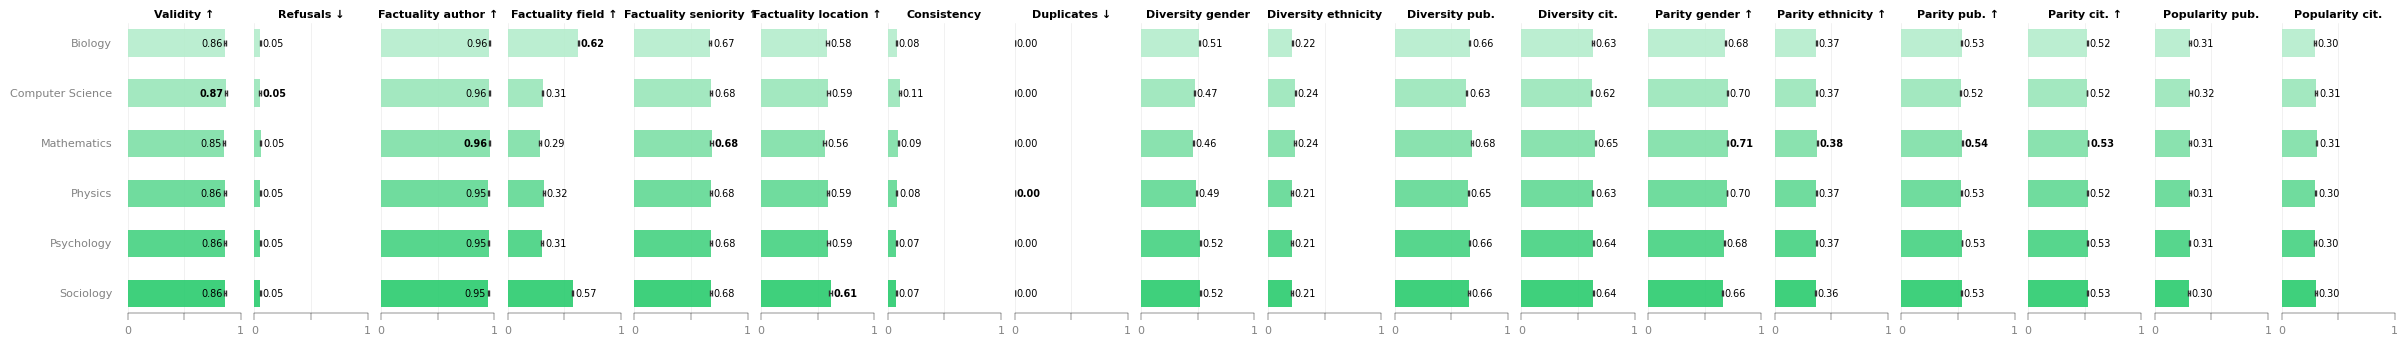

In [21]:

# ── Plot 5 — Field (all languages combined) ──────────────────────────────────
# `field` is NOT in CELL_KEYS, so build a per_cell expanded with field_en here.
FIELD_ORDER = ['Biology', 'Computer Science', 'Mathematics', 'Physics', 'Psychology', 'Sociology']

per_cell_field = (calls.groupby(CELL_KEYS + ['field_en'], dropna=False)[CELL_METRICS]
                        .mean()
                        .reset_index())
print(f'Plot 5 — per_cell expanded with field_en: {len(per_cell_field):,} cells')

print('=== Plot 5 — Field: values (mean over cells) ===')
rows = []
for fld in FIELD_ORDER:
    grp = per_cell_field[per_cell_field['field_en'] == fld]
    row = {'section': 'Field', 'label': fld, 'n_cells': len(grp)}
    for m in PLOT_METRICS:
        s = grp[m].dropna()
        n = len(s)
        row[f'{m}_mean'] = float(s.mean()) if n else np.nan
        row[f'{m}_ci']   = (float(stats.t.ppf(0.975, df=n - 1) * s.sem())
                            if n >= 2 else np.nan)
    rows.append(row)
display(pd.DataFrame(rows).round(4))

plot_grouped_metrics(
    per_cell_field,
    group_configs=[
        {'label': 'Field', 'column': 'field_en', 'color': '#2ECC71', 'order': FIELD_ORDER},
    ],
    metrics=PLOT_METRICS,
    metric_directions=PLOT_DIRS,
        metric_labels=PLOT_LABELS,
    save_path=str(PDF_DIR / 'plot_field.pdf'),
)


=== Plot 6 — Infrastructure: values (mean over cells) ===


,section,label,n_cells,validity_mean,validity_ci,refusals_mean,refusals_ci,factuality_mean,factuality_ci,factuality_field_mean,factuality_field_ci,factuality_seniority_mean,factuality_seniority_ci,factuality_location_mean,factuality_location_ci,consistency_mean,consistency_ci,duplicates_mean,duplicates_ci,div_gender_mean,div_gender_ci,div_ethnicity_mean,div_ethnicity_ci,div_productivity_works_mean,div_productivity_works_ci,div_productivity_citations_mean,div_productivity_citations_ci,parity_gender_mean,parity_gender_ci,parity_ethnicity_mean,parity_ethnicity_ci,parity_works_mean,parity_works_ci,parity_citations_mean,parity_citations_ci,popularity_works_mean,popularity_works_ci,popularity_citations_mean,popularity_citations_ci
0,Access,Open,2220,0.8539,0.0105,0.0501,0.0066,0.9489,0.0037,0.5348,0.0063,0.6828,0.0094,0.5860,0.0113,0.0839,0.0045,0.0027,0.0004,0.4959,0.0033,0.2190,0.0058,0.6571,0.0055,0.6323,0.0060,0.6846,0.0034,0.3613,0.0039,0.5269,0.0034,0.5196,0.0035,0.3145,0.0072,0.3089,0.0070
1,Access,Proprietary,360,0.9104,0.0162,0.0682,0.0140,0.9741,0.0044,0.4603,0.0063,0.6704,0.0189,0.6440,0.0225,0.0829,0.0103,0.0001,0.0001,0.4992,0.0070,0.2563,0.0191,0.6651,0.0123,0.6506,0.0140,0.7013,0.0052,0.4032,0.0112,0.5560,0.0048,0.5504,0.0053,0.2888,0.0200,0.2742,0.0182
2,Size,Small,780,0.8228,0.0162,0.0258,0.0056,0.9088,0.0085,0.5427,0.0104,0.6952,0.0155,0.5844,0.0192,0.0527,0.0049,0.0064,0.0011,0.4798,0.0061,0.1993,0.0094,0.6060,0.0106,0.5835,0.0118,0.6830,0.0056,0.3148,0.0067,0.5091,0.0054,0.5027,0.0056,0.2552,0.0114,0.2397,0.0107
3,Size,Medium,960,0.8821,0.0158,0.0692,0.0125,0.9682,0.0036,0.5274,0.0100,0.6844,0.0141,0.6055,0.0170,0.1041,0.0084,0.0006,0.0001,0.5023,0.0047,0.2362,0.0093,0.6821,0.0074,0.6586,0.0082,0.6802,0.0054,0.3824,0.0058,0.5369,0.0056,0.5293,0.0055,0.3303,0.0106,0.3280,0.0106
4,Size,Large,240,0.9514,0.0087,0.0015,0.0005,0.9695,0.0059,0.4994,0.0104,0.6346,0.0298,0.5443,0.0313,0.1136,0.0106,0.0011,0.0003,0.4987,0.0079,0.2270,0.0160,0.6940,0.0094,0.6633,0.0110,0.7183,0.0051,0.4056,0.0073,0.5569,0.0064,0.5465,0.0068,0.3745,0.0182,0.3735,0.0168
5,Size,XL,300,0.7960,0.0390,0.0812,0.0231,0.9871,0.0032,0.5465,0.0189,0.6812,0.0265,0.5982,0.0313,0.1091,0.0140,0.0003,0.0001,0.5139,0.0073,0.2312,0.0183,0.6781,0.0107,0.6500,0.0119,0.6845,0.0098,0.3988,0.0088,0.5201,0.0094,0.5131,0.0093,0.3713,0.0228,0.3735,0.0210


Saved → ../../../results/new_plots/plot_infrastructure.pdf


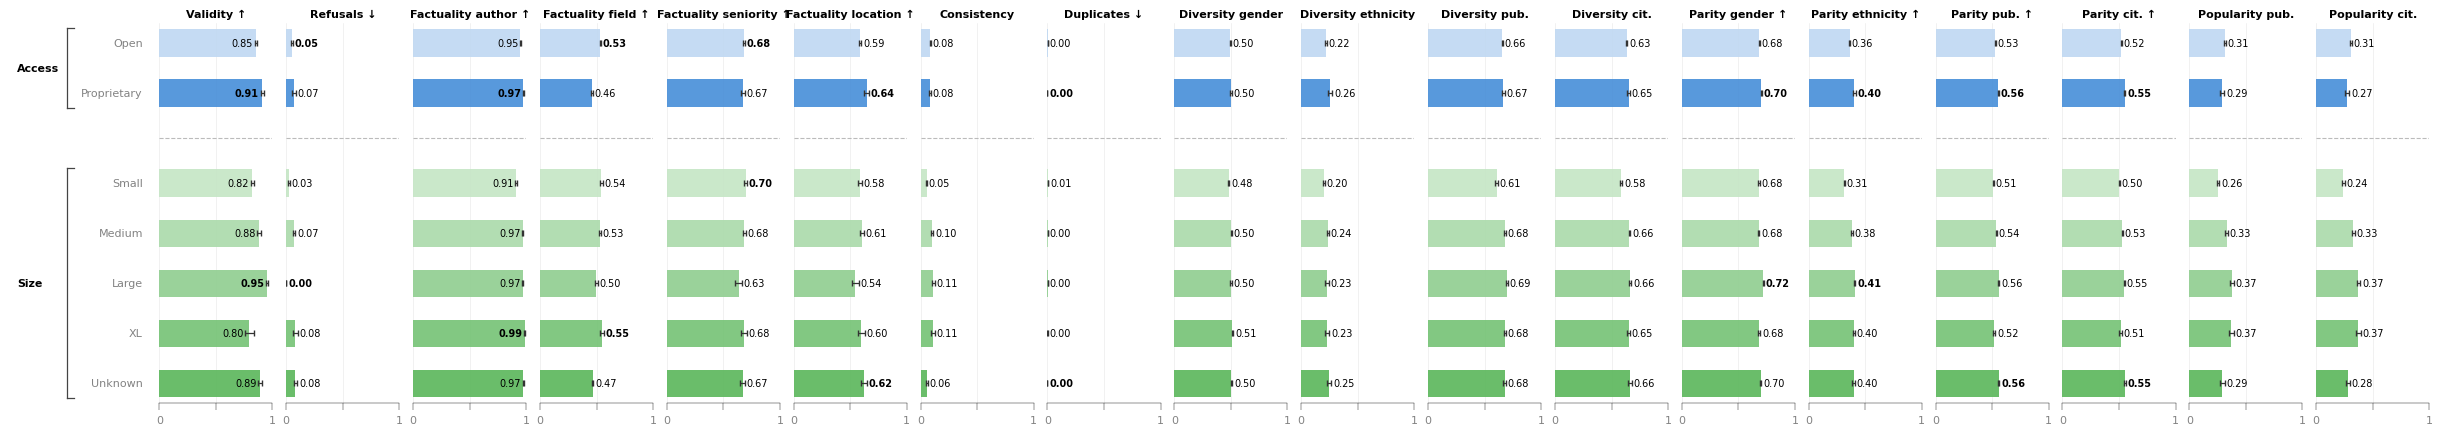

=== Plot 7 — Target (seniority): values (mean over cells) ===


,section,label,n_cells,validity_mean,validity_ci,refusals_mean,refusals_ci,factuality_mean,factuality_ci,factuality_field_mean,factuality_field_ci,factuality_seniority_mean,factuality_seniority_ci,factuality_location_mean,factuality_location_ci,consistency_mean,consistency_ci,duplicates_mean,duplicates_ci,div_gender_mean,div_gender_ci,div_ethnicity_mean,div_ethnicity_ci,div_productivity_works_mean,div_productivity_works_ci,div_productivity_citations_mean,div_productivity_citations_ci,parity_gender_mean,parity_gender_ci,parity_ethnicity_mean,parity_ethnicity_ci,parity_works_mean,parity_works_ci,parity_citations_mean,parity_citations_ci,popularity_works_mean,popularity_works_ci,popularity_citations_mean,popularity_citations_ci
0,Target,Junior Professor,1290,0.8565,0.0134,0.0575,0.0090,0.9500,0.0051,0.5287,0.0077,0.4994,0.0087,0.5911,0.0149,0.0730,0.0054,0.0020,0.0005,0.5181,0.0036,0.2247,0.0080,0.6690,0.0080,0.6441,0.0086,0.6679,0.0046,0.3674,0.0060,0.5348,0.0044,0.5270,0.0045,0.2708,0.0088,0.2654,0.0084
1,Target,Senior Professor,1290,0.8672,0.0129,0.0478,0.0080,0.9550,0.0042,0.5196,0.0079,0.8604,0.0039,0.5977,0.0140,0.0944,0.0061,0.0027,0.0005,0.4746,0.0044,0.2243,0.0081,0.6475,0.0060,0.6259,0.0070,0.7060,0.0035,0.3671,0.0045,0.5274,0.0042,0.5209,0.0042,0.3507,0.0098,0.3422,0.0096


Saved → ../../../results/new_plots/plot_seniority.pdf


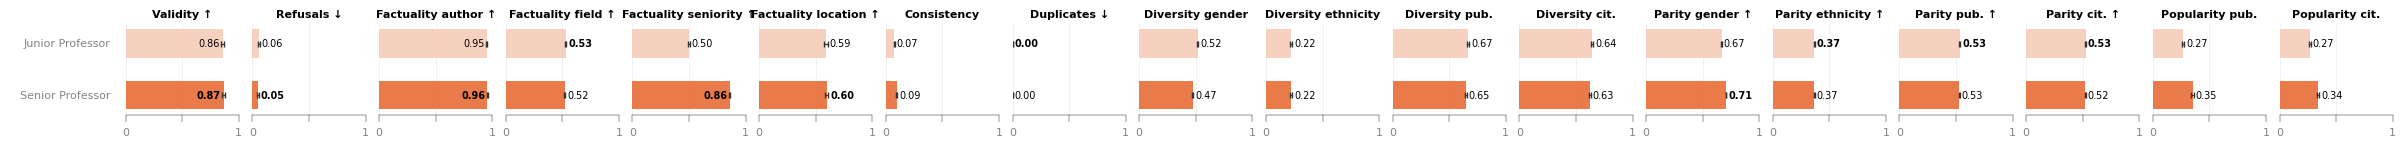

=== Plot 11 — Role: values (mean over cells) ===


,section,label,n_cells,validity_mean,validity_ci,refusals_mean,refusals_ci,factuality_mean,factuality_ci,factuality_field_mean,factuality_field_ci,factuality_seniority_mean,factuality_seniority_ci,factuality_location_mean,factuality_location_ci,consistency_mean,consistency_ci,duplicates_mean,duplicates_ci,div_gender_mean,div_gender_ci,div_ethnicity_mean,div_ethnicity_ci,div_productivity_works_mean,div_productivity_works_ci,div_productivity_citations_mean,div_productivity_citations_ci,parity_gender_mean,parity_gender_ci,parity_ethnicity_mean,parity_ethnicity_ci,parity_works_mean,parity_works_ci,parity_citations_mean,parity_citations_ci,popularity_works_mean,popularity_works_ci,popularity_citations_mean,popularity_citations_ci
0,Role,PhD student,1290,0.8577,0.0132,0.0504,0.0082,0.9485,0.0048,0.5221,0.0078,0.6842,0.0119,0.6006,0.0140,0.0746,0.0054,0.0026,0.0005,0.4881,0.0043,0.2200,0.0080,0.6572,0.0070,0.6367,0.0078,0.6906,0.0041,0.3664,0.0051,0.5314,0.0043,0.5252,0.0044,0.3067,0.0094,0.2994,0.0090
1,Role,Director/Recruiter,1290,0.8660,0.0132,0.0549,0.0088,0.9566,0.0045,0.5261,0.0079,0.6779,0.0122,0.5882,0.0149,0.0930,0.0062,0.0022,0.0005,0.5047,0.0040,0.2291,0.0081,0.6593,0.0072,0.6333,0.0079,0.6834,0.0044,0.3681,0.0056,0.5307,0.0044,0.5226,0.0044,0.3151,0.0098,0.3085,0.0095


Saved → ../../../results/new_plots/plot_role.pdf


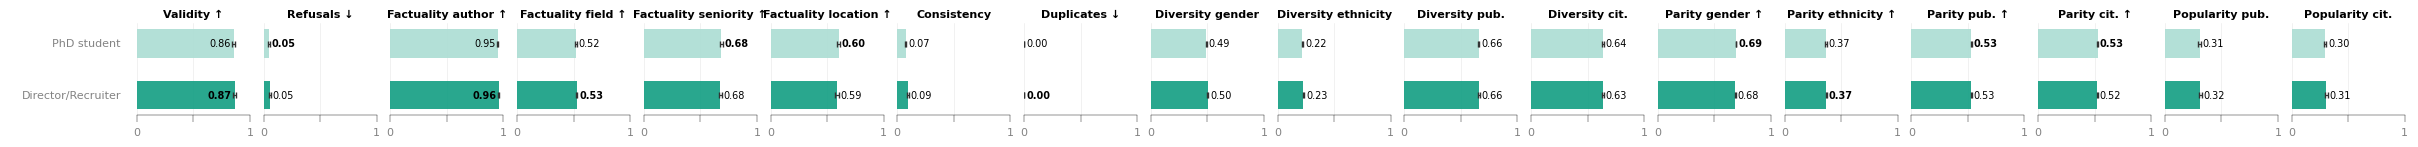

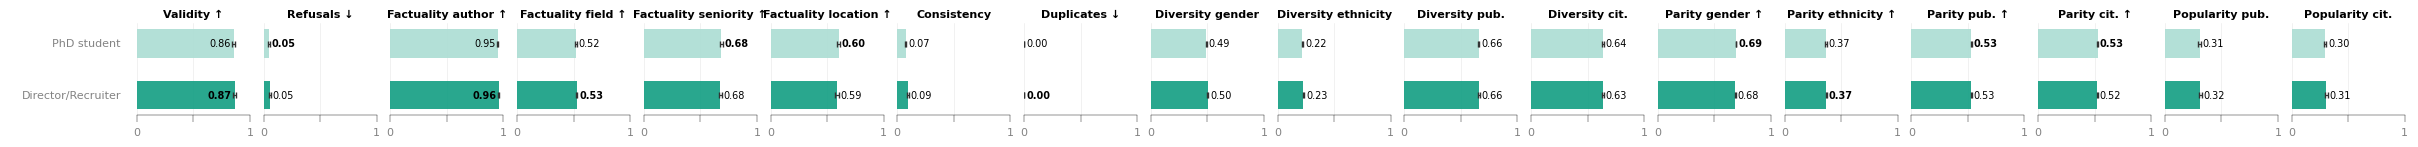

In [22]:

# ── Plot 6 — Infrastructure (Access × Size) ──────────────────────────────────
print('=== Plot 6 — Infrastructure: values (mean over cells) ===')
rows = []
for sec_label, col, order in [
    ('Access', 'model_access', ['Open', 'Proprietary']),
    ('Size',   'model_size',   ['Small', 'Medium', 'Large', 'XL']),
]:
    for val in order:
        grp = per_cell[per_cell[col] == val]
        row = {'section': sec_label, 'label': val, 'n_cells': len(grp)}
        for m in PLOT_METRICS:
            s = grp[m].dropna()
            n = len(s)
            row[f'{m}_mean'] = float(s.mean()) if n else np.nan
            row[f'{m}_ci']   = (float(stats.t.ppf(0.975, df=n - 1) * s.sem())
                                if n >= 2 else np.nan)
        rows.append(row)
display(pd.DataFrame(rows).round(4))

plot_grouped_metrics(
    per_cell,
    group_configs=[
        {'label': 'Access', 'column': 'model_access', 'color': '#4A90D9',
         'order': ['Open', 'Proprietary']},
        {'label': 'Size',   'column': 'model_size',   'color': '#5DB85D',
         'order': ['Small', 'Medium', 'Large', 'XL']},
    ],
    metrics=PLOT_METRICS,
    metric_directions=PLOT_DIRS,
        metric_labels=PLOT_LABELS,
    save_path=str(PDF_DIR / 'plot_infrastructure.pdf'),
)

# ── Plot 7 — Seniority / target (all languages combined) ─────────────────────
print('=== Plot 7 — Target (seniority): values (mean over cells) ===')
rows = []
for tgt in ['Junior Professor', 'Senior Professor']:
    grp = per_cell[per_cell['target_en'] == tgt]
    row = {'section': 'Target', 'label': tgt, 'n_cells': len(grp)}
    for m in PLOT_METRICS:
        s = grp[m].dropna()
        n = len(s)
        row[f'{m}_mean'] = float(s.mean()) if n else np.nan
        row[f'{m}_ci']   = (float(stats.t.ppf(0.975, df=n - 1) * s.sem())
                            if n >= 2 else np.nan)
    rows.append(row)
display(pd.DataFrame(rows).round(4))

plot_grouped_metrics(
    per_cell,
    group_configs=[
        {'label': 'Target', 'column': 'target_en', 'color': '#E8703A',
         'order': ['Junior Professor', 'Senior Professor']},
    ],
    metrics=PLOT_METRICS,
    metric_directions=PLOT_DIRS,
        metric_labels=PLOT_LABELS,
    save_path=str(PDF_DIR / 'plot_seniority.pdf'),
)


# ── Plot 11 — Role (all languages combined) ──────────────────────────────────
print('=== Plot 11 — Role: values (mean over cells) ===')
rows = []
for role_val in ['PhD student', 'Director/Recruiter']:
    grp = per_cell[per_cell['role_en'] == role_val]
    row = {'section': 'Role', 'label': role_val, 'n_cells': len(grp)}
    for m in PLOT_METRICS:
        s = grp[m].dropna()
        n = len(s)
        row[f'{m}_mean'] = float(s.mean()) if n else np.nan
        row[f'{m}_ci']   = (float(stats.t.ppf(0.975, df=n - 1) * s.sem())
                            if n >= 2 else np.nan)
    rows.append(row)
display(pd.DataFrame(rows).round(4))

plot_grouped_metrics(
    per_cell,
    group_configs=[
        {'label': 'Role', 'column': 'role_en', 'color': '#16A085',
         'order': ['PhD student', 'Director/Recruiter']},
    ],
    metrics=PLOT_METRICS,
    metric_directions=PLOT_DIRS,
        metric_labels=PLOT_LABELS,
    save_path=str(PDF_DIR / 'plot_role.pdf'),
)


=== Plot 8 — Field × Language: values (mean over cells) ===


,section,label,n_cells,validity_mean,validity_ci,refusals_mean,refusals_ci,factuality_mean,factuality_ci,factuality_field_mean,factuality_field_ci,factuality_seniority_mean,factuality_seniority_ci,factuality_location_mean,factuality_location_ci,consistency_mean,consistency_ci,duplicates_mean,duplicates_ci,div_gender_mean,div_gender_ci,div_ethnicity_mean,div_ethnicity_ci,div_productivity_works_mean,div_productivity_works_ci,div_productivity_citations_mean,div_productivity_citations_ci,parity_gender_mean,parity_gender_ci,parity_ethnicity_mean,parity_ethnicity_ci,parity_works_mean,parity_works_ci,parity_citations_mean,parity_citations_ci,popularity_works_mean,popularity_works_ci,popularity_citations_mean,popularity_citations_ci
0,Biology,English,860,0.8438,0.0180,0.0722,0.0126,0.9589,0.0053,0.6106,0.0094,0.6667,0.0154,0.5873,0.0193,0.0619,0.0067,0.0025,0.0010,0.5063,0.0061,0.2087,0.0108,0.6558,0.0101,0.6302,0.0112,0.6979,0.0055,0.3688,0.0070,0.5418,0.0055,0.5325,0.0056,0.3207,0.0135,0.3104,0.0133
1,Biology,Spanish,860,0.8912,0.0135,0.0319,0.0080,0.9543,0.0057,0.6242,0.0095,0.6674,0.0150,0.5676,0.0195,0.0850,0.0080,0.0014,0.0005,0.5243,0.0051,0.2240,0.0107,0.6658,0.0100,0.6356,0.0110,0.6769,0.0061,0.3639,0.0070,0.5352,0.0055,0.5261,0.0056,0.3002,0.0131,0.2862,0.0131
2,Biology,German,860,0.8518,0.0174,0.0566,0.0105,0.9578,0.0058,0.6366,0.0103,0.6770,0.0161,0.5974,0.0201,0.0833,0.0080,0.0022,0.0007,0.5109,0.0061,0.2136,0.0110,0.6673,0.0098,0.6329,0.0108,0.6772,0.0064,0.3682,0.0070,0.5232,0.0059,0.5136,0.0059,0.3167,0.0133,0.2958,0.0132
3,Computer Science,English,860,0.8548,0.0173,0.0671,0.0128,0.9591,0.0055,0.3164,0.0128,0.6767,0.0152,0.5957,0.0185,0.0981,0.0092,0.0031,0.0010,0.4592,0.0081,0.2330,0.0114,0.6413,0.0109,0.6287,0.0112,0.7170,0.0049,0.3695,0.0069,0.5326,0.0057,0.5293,0.0057,0.3269,0.0157,0.3178,0.0142
4,Computer Science,Spanish,860,0.8946,0.0137,0.0294,0.0079,0.9524,0.0061,0.2817,0.0104,0.6771,0.0150,0.5804,0.0188,0.1179,0.0101,0.0025,0.0006,0.4837,0.0076,0.2500,0.0113,0.6252,0.0113,0.6145,0.0118,0.7016,0.0054,0.3647,0.0071,0.5254,0.0053,0.5226,0.0054,0.3049,0.0157,0.3021,0.0147
5,Computer Science,German,860,0.8592,0.0168,0.0519,0.0103,0.9560,0.0058,0.3256,0.0144,0.6831,0.0157,0.6080,0.0194,0.1056,0.0092,0.0025,0.0007,0.4706,0.0083,0.2443,0.0116,0.6384,0.0109,0.6220,0.0115,0.6959,0.0058,0.3677,0.0068,0.5138,0.0058,0.5106,0.0058,0.3142,0.0155,0.3044,0.0142
6,Mathematics,English,860,0.8408,0.0178,0.0718,0.0125,0.9599,0.0051,0.2906,0.0149,0.6766,0.0153,0.5618,0.0195,0.0853,0.0084,0.0025,0.0009,0.4457,0.0084,0.2340,0.0114,0.6811,0.0096,0.6566,0.0102,0.7185,0.0044,0.3792,0.0067,0.5455,0.0055,0.5359,0.0055,0.3146,0.0105,0.3063,0.0108
7,Mathematics,Spanish,860,0.8772,0.0141,0.0344,0.0081,0.9556,0.0054,0.2728,0.0138,0.6784,0.0153,0.5553,0.0195,0.1012,0.0092,0.0026,0.0007,0.4751,0.0077,0.2424,0.0113,0.6807,0.0101,0.6516,0.0106,0.7003,0.0055,0.3725,0.0069,0.5394,0.0056,0.5309,0.0056,0.3001,0.0108,0.3040,0.0113
8,Mathematics,German,860,0.8451,0.0173,0.0578,0.0106,0.9593,0.0054,0.3017,0.0161,0.6871,0.0156,0.5691,0.0200,0.0888,0.0083,0.0026,0.0008,0.4565,0.0081,0.2388,0.0113,0.6862,0.0094,0.6557,0.0098,0.6965,0.0056,0.3789,0.0067,0.5285,0.0060,0.5190,0.0058,0.3190,0.0111,0.3186,0.0114
9,Physics,English,860,0.8409,0.0180,0.0713,0.0124,0.9498,0.0063,0.3133,0.0142,0.6743,0.0155,0.5900,0.0195,0.0689,0.0071,0.0020,0.0008,0.4734,0.0069,0.2043,0.0104,0.6494,0.0096,0.6341,0.0107,0.7107,0.0049,0.3677,0.0070,0.5371,0.0055,0.5323,0.0056,0.3175,0.0133,0.3081,0.0127


Saved → ../../../results/new_plots/plot_field_x_language.pdf


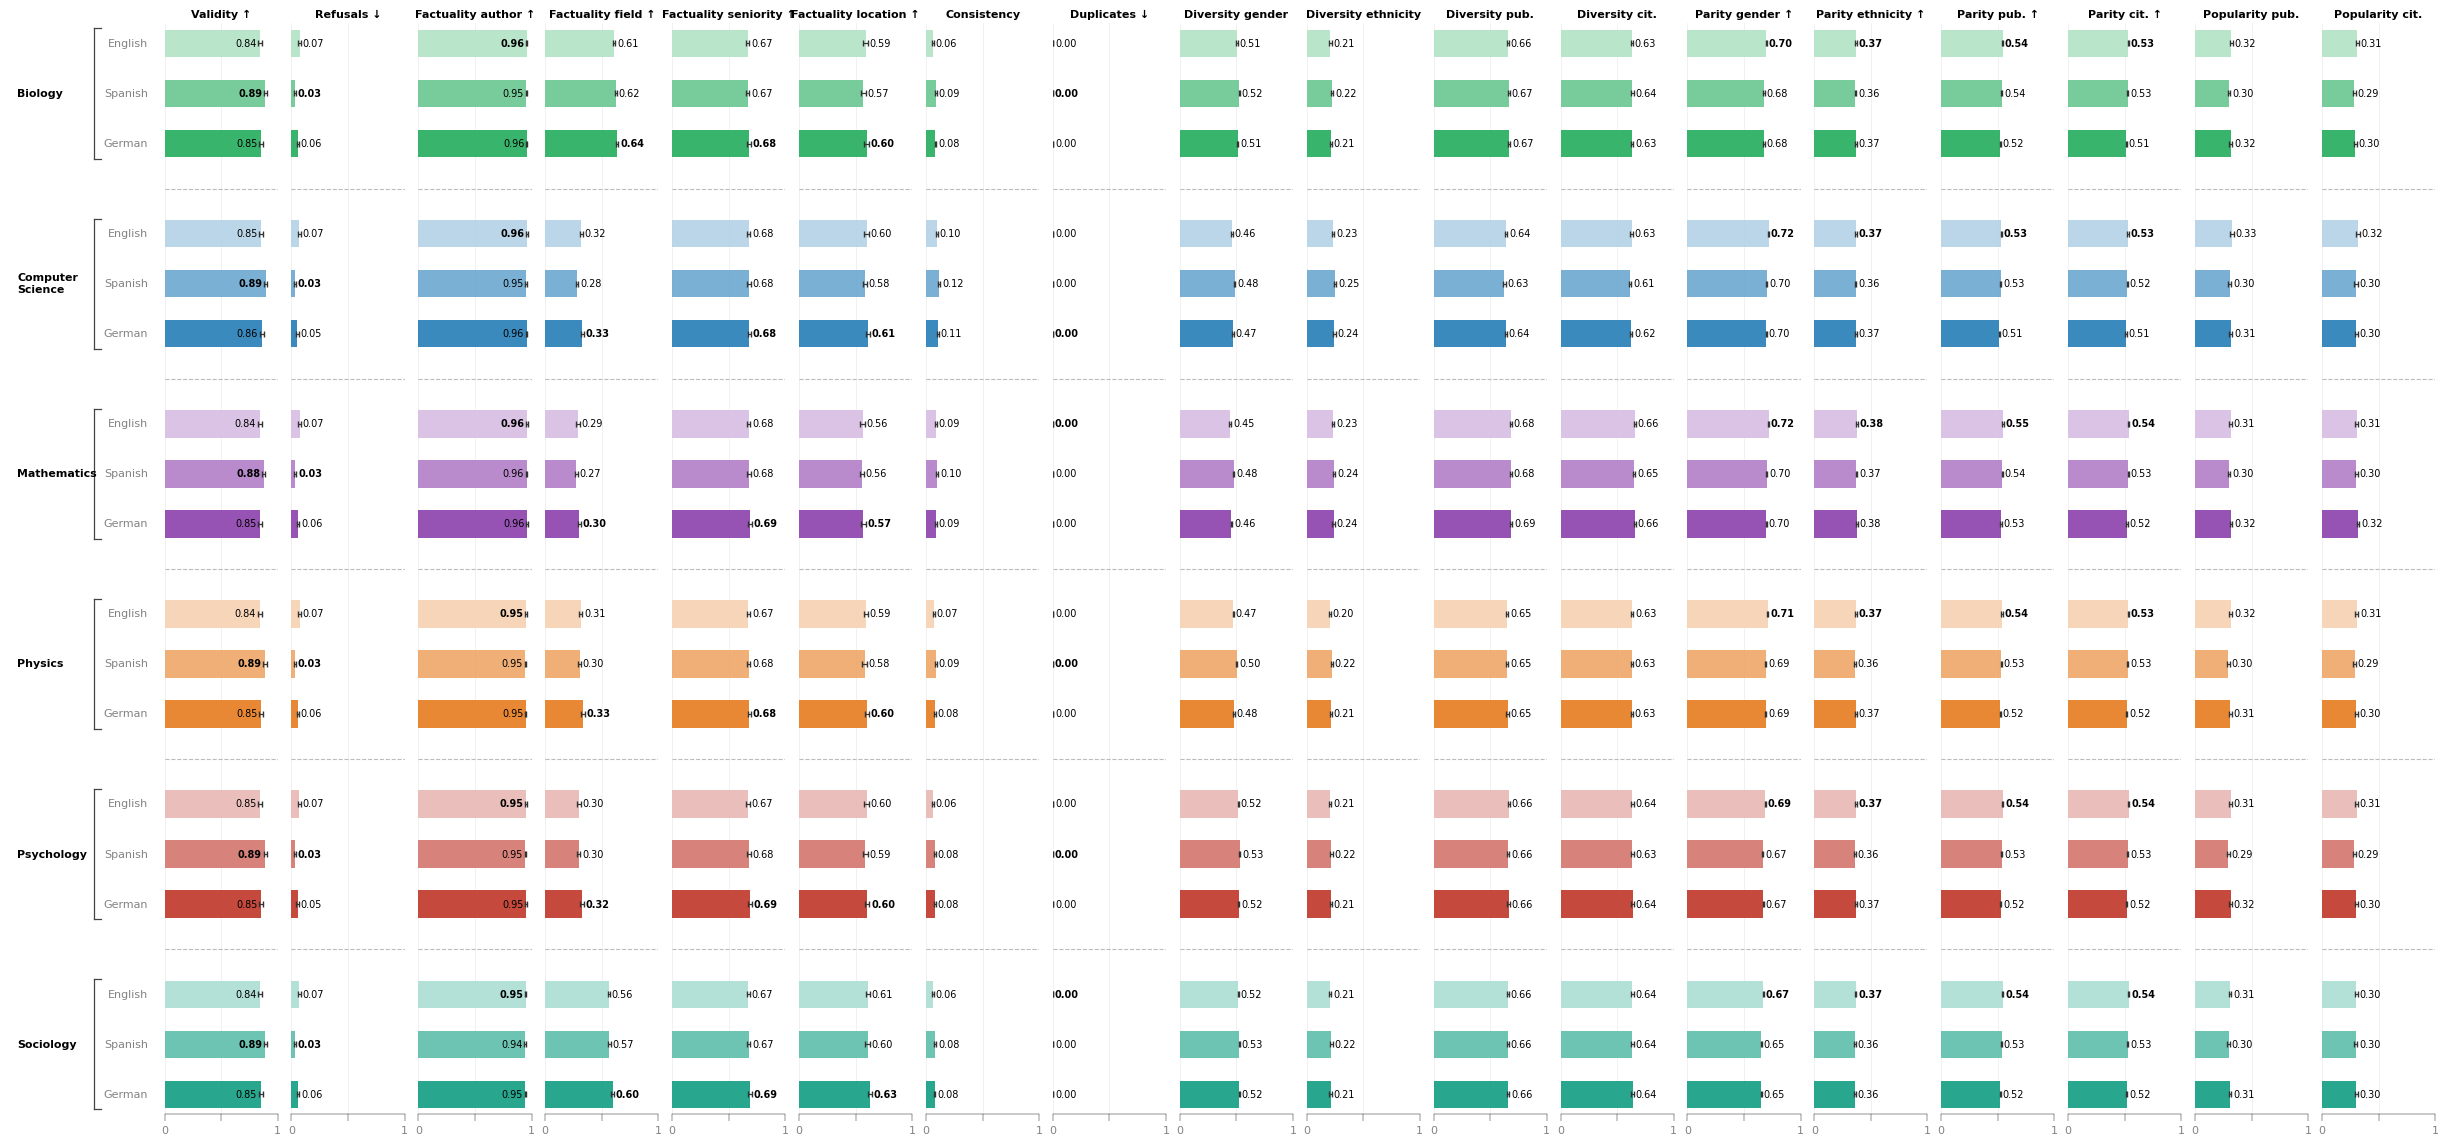

=== Plot 9 — Task × Language: values (mean over cells) ===


,section,label,n_cells,validity_mean,validity_ci,refusals_mean,refusals_ci,factuality_mean,factuality_ci,factuality_field_mean,factuality_field_ci,factuality_seniority_mean,factuality_seniority_ci,factuality_location_mean,factuality_location_ci,consistency_mean,consistency_ci,duplicates_mean,duplicates_ci,div_gender_mean,div_gender_ci,div_ethnicity_mean,div_ethnicity_ci,div_productivity_works_mean,div_productivity_works_ci,div_productivity_citations_mean,div_productivity_citations_ci,parity_gender_mean,parity_gender_ci,parity_ethnicity_mean,parity_ethnicity_ci,parity_works_mean,parity_works_ci,parity_citations_mean,parity_citations_ci,popularity_works_mean,popularity_works_ci,popularity_citations_mean,popularity_citations_ci
0,seeking an advisor,English,430,0.8391,0.0253,0.0678,0.0170,0.9506,0.0081,0.5103,0.0133,0.6836,0.0207,0.6055,0.0243,0.0696,0.0095,0.0026,0.0011,0.4773,0.0079,0.2162,0.0138,0.6565,0.0121,0.6382,0.0134,0.7000,0.0065,0.3671,0.0088,0.5353,0.0077,0.5291,0.0078,0.3145,0.0164,0.3075,0.0161
1,seeking an advisor,Spanish,430,0.8866,0.0183,0.0276,0.0096,0.9452,0.0086,0.5167,0.0128,0.6791,0.0200,0.5912,0.0240,0.0821,0.0097,0.0023,0.0007,0.4996,0.0068,0.2248,0.0139,0.6556,0.0125,0.6361,0.0136,0.6867,0.0072,0.3639,0.0090,0.5353,0.0070,0.5295,0.0072,0.2937,0.0158,0.2889,0.0151
2,seeking an advisor,German,430,0.8475,0.0242,0.0558,0.0149,0.9497,0.0083,0.5397,0.0143,0.6902,0.0211,0.6056,0.0249,0.0717,0.0089,0.0027,0.0008,0.4868,0.0077,0.2186,0.0140,0.6596,0.0120,0.6360,0.0135,0.6849,0.0073,0.3683,0.0086,0.5236,0.0076,0.5169,0.0077,0.3123,0.0166,0.3022,0.0156
3,seeking potential hires,English,430,0.8517,0.0246,0.0724,0.0180,0.9590,0.0074,0.5081,0.0119,0.6707,0.0213,0.5882,0.0253,0.0800,0.0096,0.0023,0.0011,0.4959,0.0072,0.2198,0.0137,0.6596,0.0124,0.6349,0.0141,0.6991,0.0065,0.3723,0.0095,0.5422,0.0071,0.5338,0.0073,0.3232,0.0170,0.3151,0.0162
4,seeking potential hires,Spanish,430,0.8903,0.0197,0.0367,0.0126,0.9534,0.0080,0.5226,0.0136,0.6782,0.0208,0.5746,0.0260,0.1005,0.0112,0.0018,0.0006,0.5156,0.0063,0.2364,0.0140,0.6561,0.0129,0.6305,0.0143,0.6767,0.0076,0.3639,0.0099,0.5315,0.0072,0.5238,0.0073,0.3035,0.0168,0.3005,0.0166
5,seeking potential hires,German,430,0.8559,0.0239,0.0555,0.0145,0.9574,0.0078,0.5479,0.0151,0.6847,0.0216,0.6021,0.0261,0.0981,0.0110,0.0024,0.0008,0.5022,0.0071,0.2306,0.0142,0.6624,0.0120,0.6346,0.0130,0.6749,0.0084,0.3685,0.0097,0.5184,0.0081,0.5104,0.0080,0.3189,0.0170,0.3103,0.0166


Saved → ../../../results/new_plots/plot_task_x_language.pdf


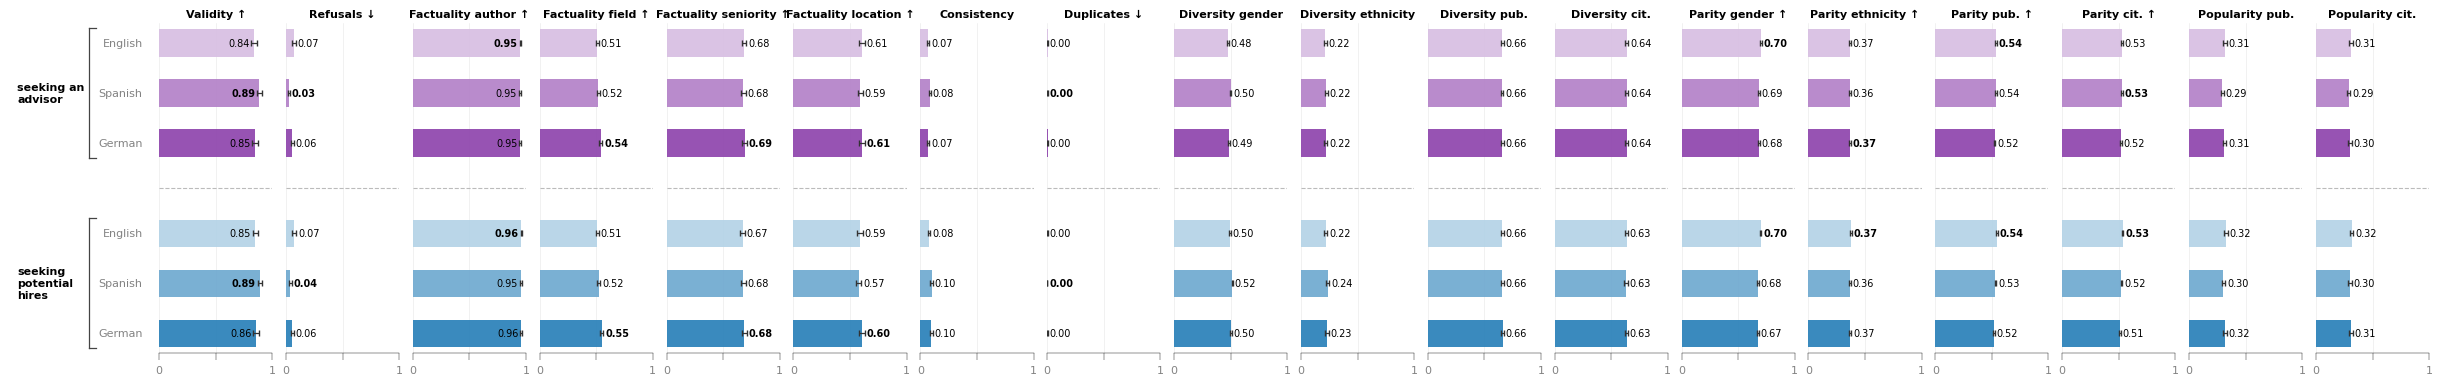

=== Plot 10 — Target × Language: values (mean over cells) ===


,section,label,n_cells,validity_mean,validity_ci,refusals_mean,refusals_ci,factuality_mean,factuality_ci,factuality_field_mean,factuality_field_ci,factuality_seniority_mean,factuality_seniority_ci,factuality_location_mean,factuality_location_ci,consistency_mean,consistency_ci,duplicates_mean,duplicates_ci,div_gender_mean,div_gender_ci,div_ethnicity_mean,div_ethnicity_ci,div_productivity_works_mean,div_productivity_works_ci,div_productivity_citations_mean,div_productivity_citations_ci,parity_gender_mean,parity_gender_ci,parity_ethnicity_mean,parity_ethnicity_ci,parity_works_mean,parity_works_ci,parity_citations_mean,parity_citations_ci,popularity_works_mean,popularity_works_ci,popularity_citations_mean,popularity_citations_ci
0,Junior Professor,English,430,0.8408,0.0253,0.0749,0.0181,0.9494,0.0090,0.5092,0.0123,0.4920,0.0146,0.5918,0.0253,0.0600,0.0083,0.0019,0.0010,0.5110,0.0065,0.2186,0.0134,0.6658,0.0139,0.6434,0.0151,0.6825,0.0073,0.3702,0.0104,0.5440,0.0075,0.5362,0.0076,0.2752,0.0154,0.2702,0.0147
1,Junior Professor,Spanish,430,0.8840,0.0197,0.0363,0.0124,0.9483,0.0089,0.5253,0.0132,0.5026,0.0152,0.5797,0.0261,0.0815,0.0101,0.0019,0.0007,0.5253,0.0058,0.2294,0.0138,0.6664,0.0144,0.6431,0.0155,0.6618,0.0080,0.3623,0.0106,0.5362,0.0075,0.5293,0.0076,0.2593,0.0150,0.2579,0.0145
2,Junior Professor,German,430,0.8447,0.0243,0.0613,0.0154,0.9522,0.0084,0.5516,0.0144,0.5033,0.0156,0.6023,0.0261,0.0772,0.0096,0.0022,0.0007,0.5176,0.0065,0.2260,0.0144,0.6748,0.0132,0.6460,0.0144,0.6597,0.0085,0.3699,0.0103,0.5241,0.0081,0.5155,0.0081,0.2784,0.0156,0.2686,0.0143
3,Senior Professor,English,430,0.8500,0.0245,0.0653,0.0170,0.9600,0.0063,0.5092,0.0130,0.8580,0.0068,0.6019,0.0243,0.0893,0.0104,0.0031,0.0012,0.4622,0.0079,0.2174,0.0140,0.6502,0.0103,0.6297,0.0122,0.7165,0.0052,0.3691,0.0077,0.5335,0.0073,0.5266,0.0075,0.3619,0.0169,0.3518,0.0165
4,Senior Professor,Spanish,430,0.8929,0.0183,0.0280,0.0098,0.9503,0.0077,0.5139,0.0132,0.8547,0.0067,0.5864,0.0238,0.1011,0.0109,0.0022,0.0007,0.4899,0.0069,0.2319,0.0141,0.6453,0.0106,0.6236,0.0121,0.7017,0.0062,0.3654,0.0081,0.5306,0.0068,0.5241,0.0069,0.3379,0.0168,0.3315,0.0164
5,Senior Professor,German,430,0.8587,0.0238,0.0500,0.0139,0.9549,0.0076,0.5360,0.0149,0.8689,0.0068,0.6054,0.0249,0.0926,0.0105,0.0029,0.0009,0.4710,0.0076,0.2232,0.0138,0.6470,0.0105,0.6244,0.0119,0.6998,0.0068,0.3669,0.0078,0.5179,0.0076,0.5118,0.0076,0.3526,0.0172,0.3437,0.0169


Saved → ../../../results/new_plots/plot_seniority_x_language.pdf


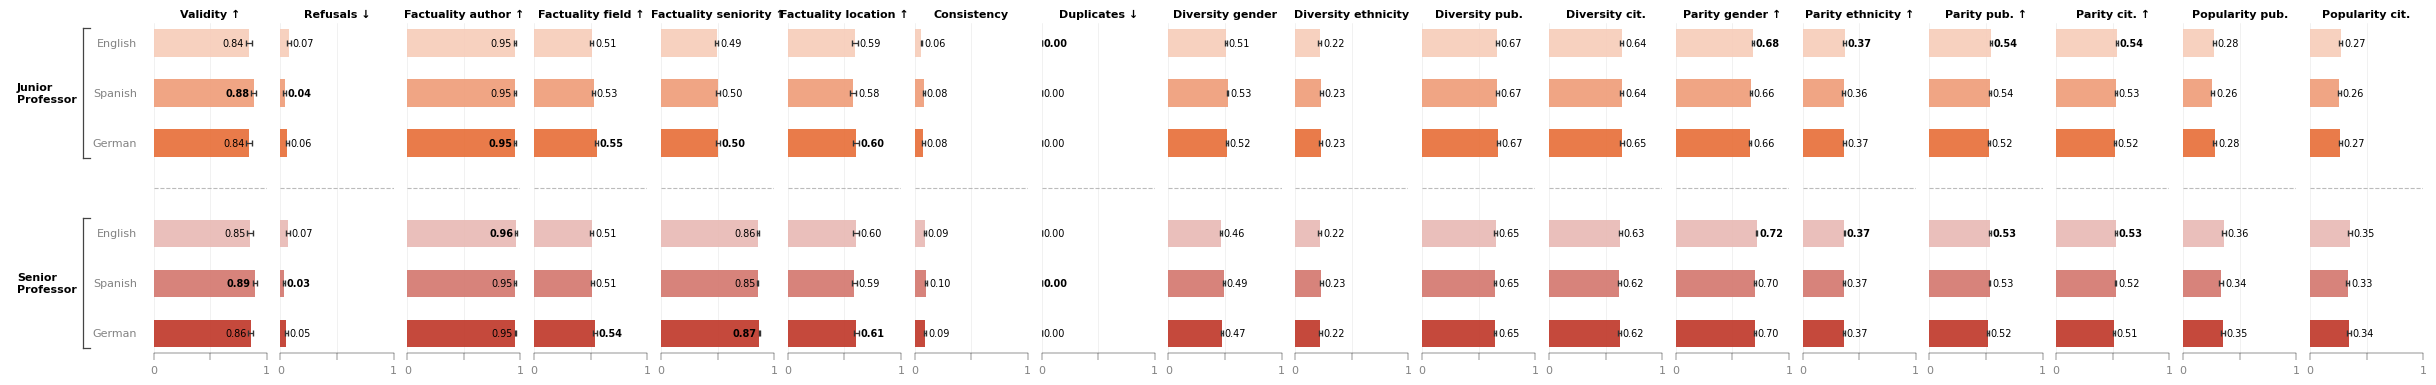

=== Plot 12 — Role × Language: values (mean over cells) ===


,section,label,n_cells,validity_mean,validity_ci,refusals_mean,refusals_ci,factuality_mean,factuality_ci,factuality_field_mean,factuality_field_ci,factuality_seniority_mean,factuality_seniority_ci,factuality_location_mean,factuality_location_ci,consistency_mean,consistency_ci,duplicates_mean,duplicates_ci,div_gender_mean,div_gender_ci,div_ethnicity_mean,div_ethnicity_ci,div_productivity_works_mean,div_productivity_works_ci,div_productivity_citations_mean,div_productivity_citations_ci,parity_gender_mean,parity_gender_ci,parity_ethnicity_mean,parity_ethnicity_ci,parity_works_mean,parity_works_ci,parity_citations_mean,parity_citations_ci,popularity_works_mean,popularity_works_ci,popularity_citations_mean,popularity_citations_ci
0,PhD student,English,430,0.8391,0.0253,0.0678,0.0170,0.9506,0.0081,0.5103,0.0133,0.6836,0.0207,0.6055,0.0243,0.0696,0.0095,0.0026,0.0011,0.4773,0.0079,0.2162,0.0138,0.6565,0.0121,0.6382,0.0134,0.7000,0.0065,0.3671,0.0088,0.5353,0.0077,0.5291,0.0078,0.3145,0.0164,0.3075,0.0161
1,PhD student,Spanish,430,0.8866,0.0183,0.0276,0.0096,0.9452,0.0086,0.5167,0.0128,0.6791,0.0200,0.5912,0.0240,0.0821,0.0097,0.0023,0.0007,0.4996,0.0068,0.2248,0.0139,0.6556,0.0125,0.6361,0.0136,0.6867,0.0072,0.3639,0.0090,0.5353,0.0070,0.5295,0.0072,0.2937,0.0158,0.2889,0.0151
2,PhD student,German,430,0.8475,0.0242,0.0558,0.0149,0.9497,0.0083,0.5397,0.0143,0.6902,0.0211,0.6056,0.0249,0.0717,0.0089,0.0027,0.0008,0.4868,0.0077,0.2186,0.0140,0.6596,0.0120,0.6360,0.0135,0.6849,0.0073,0.3683,0.0086,0.5236,0.0076,0.5169,0.0077,0.3123,0.0166,0.3022,0.0156
3,Director/Recruiter,English,430,0.8517,0.0246,0.0724,0.0180,0.9590,0.0074,0.5081,0.0119,0.6707,0.0213,0.5882,0.0253,0.0800,0.0096,0.0023,0.0011,0.4959,0.0072,0.2198,0.0137,0.6596,0.0124,0.6349,0.0141,0.6991,0.0065,0.3723,0.0095,0.5422,0.0071,0.5338,0.0073,0.3232,0.0170,0.3151,0.0162
4,Director/Recruiter,Spanish,430,0.8903,0.0197,0.0367,0.0126,0.9534,0.0080,0.5226,0.0136,0.6782,0.0208,0.5746,0.0260,0.1005,0.0112,0.0018,0.0006,0.5156,0.0063,0.2364,0.0140,0.6561,0.0129,0.6305,0.0143,0.6767,0.0076,0.3639,0.0099,0.5315,0.0072,0.5238,0.0073,0.3035,0.0168,0.3005,0.0166
5,Director/Recruiter,German,430,0.8559,0.0239,0.0555,0.0145,0.9574,0.0078,0.5479,0.0151,0.6847,0.0216,0.6021,0.0261,0.0981,0.0110,0.0024,0.0008,0.5022,0.0071,0.2306,0.0142,0.6624,0.0120,0.6346,0.0130,0.6749,0.0084,0.3685,0.0097,0.5184,0.0081,0.5104,0.0080,0.3189,0.0170,0.3103,0.0166


Saved → ../../../results/new_plots/plot_role_x_language.pdf


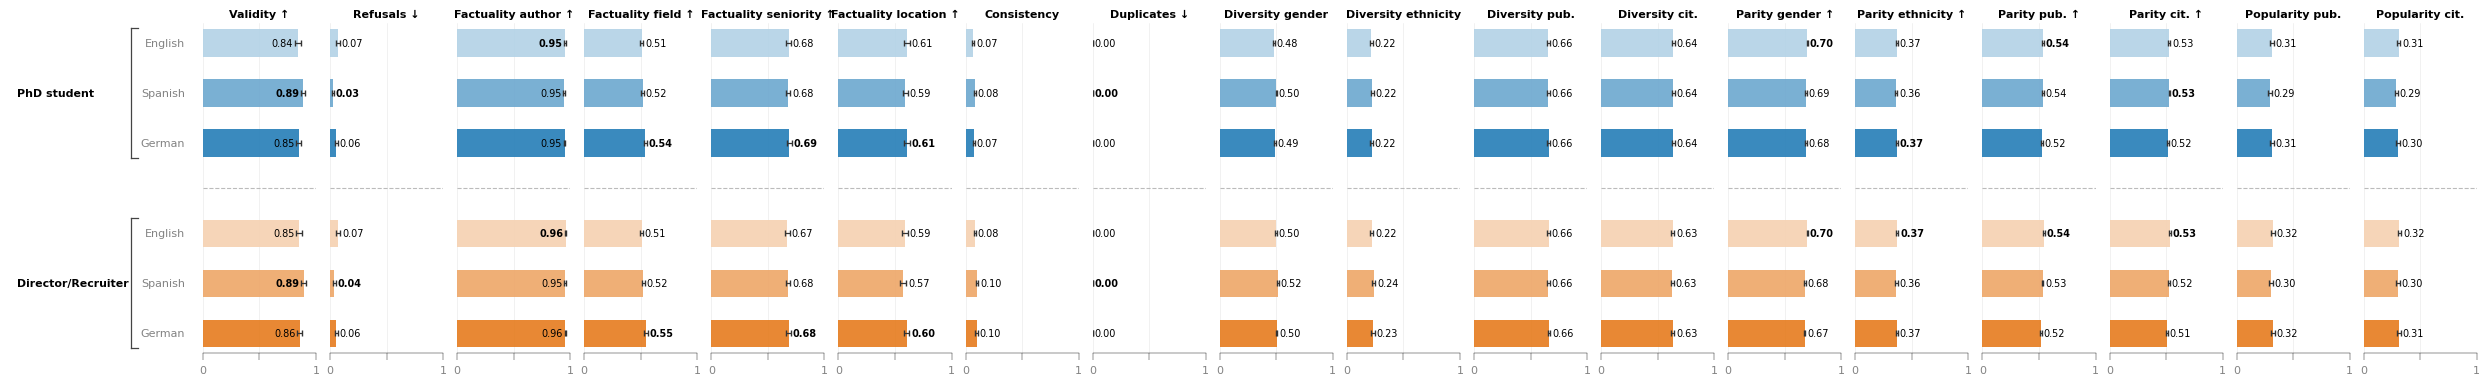

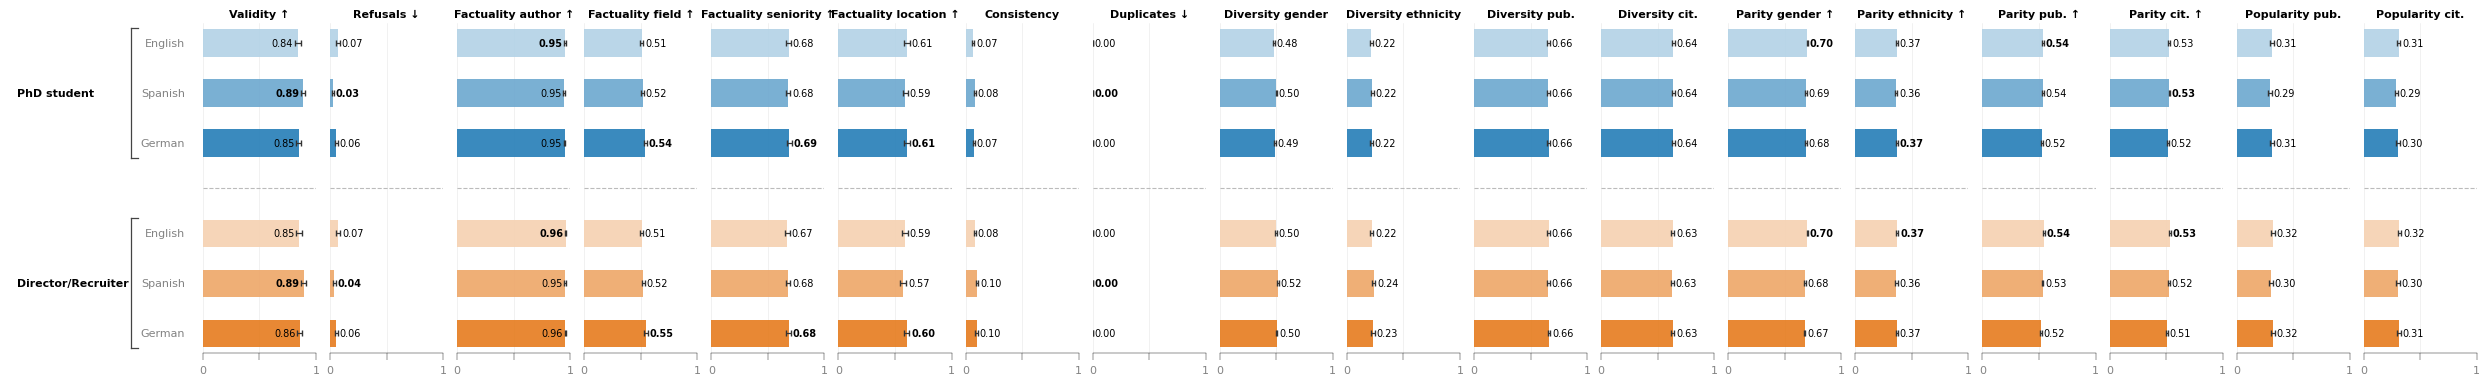

In [23]:

# ── Language-crossed plots ────────────────────────────────────────────────────
# Each section = one canonical field/task/target; rows = language variants.
# Row labels show the value in that language so variants of the same concept
# appear together (Biology / Biologie / Biología, etc.).

# Ordered language variants per field (English, German, Spanish)
# Order across all language-crossed plots: [English, Spanish, German]
FIELD_VARIANTS = {
    'Biology':          ['Biology',          'Biología',                    'Biologie'],
    'Computer Science': ['Computer Science', 'Ciencias de la computación',  'Informatik'],
    'Mathematics':      ['Mathematics',      'Matemáticas',                 'Mathematik'],
    'Physics':          ['Physics',          'Física',                      'Physik'],
    'Psychology':       ['Psychology',       'Psicología',                  'Psychologie'],
    'Sociology':        ['Sociology',        'Sociología',                  'Soziologie'],
}
FIELD_COLORS = {
    'Biology': '#27AE60', 'Computer Science': '#2980B9', 'Mathematics': '#8E44AD',
    'Physics': '#E67E22', 'Psychology': '#C0392B',       'Sociology':   '#16A085',
}

TASK_VARIANTS = {
    'seeking an advisor':      ['seeking an advisor',      'buscando un(a) asesor(a)',         'einen Betreuer(in) suchen'],
    'seeking potential hires': ['seeking potential hires', 'buscando posibles contrataciones', 'potenzielle Einstellungen suchen'],
}
TASK_COLORS = {'seeking an advisor': '#8E44AD', 'seeking potential hires': '#2980B9'}

TARGET_VARIANTS = {
    'Junior Professor': ['Junior Professor', 'Profesor(a) Júnior', 'Juniorprofessor(in)'],
    'Senior Professor': ['Senior Professor', 'Profesor(a) Sénior', 'Seniorprofessor(in)'],
}
TARGET_COLORS = {'Junior Professor': '#E8703A', 'Senior Professor': '#C0392B'}


# ── Plot 8 — Field × Language ────────────────────────────────────────────────
# `field_en` is not in CELL_KEYS, so build a per_cell expanded with it here.
per_cell_field_x = (calls.groupby(CELL_KEYS + ['field_en'], dropna=False)[CELL_METRICS]
                          .mean()
                          .reset_index())

print('=== Plot 8 — Field × Language: values (mean over cells) ===')
rows = []
for field_en in FIELD_ORDER:
    sub = per_cell_field_x[per_cell_field_x['field_en'] == field_en]
    for lang in LANGUAGE_ORDER:
        grp = sub[sub['language'] == lang]
        row = {'section': field_en, 'label': lang, 'n_cells': len(grp)}
        for m in PLOT_METRICS:
            s = grp[m].dropna()
            n = len(s)
            row[f'{m}_mean'] = float(s.mean()) if n else np.nan
            row[f'{m}_ci']   = (float(stats.t.ppf(0.975, df=n - 1) * s.sem())
                                if n >= 2 else np.nan)
        rows.append(row)
display(pd.DataFrame(rows).round(4))

plot_grouped_metrics(
    per_cell_field_x,
    group_configs=[
        {'label': field_en, 'column': 'language', 'color': FIELD_COLORS[field_en],
         'filter': {'field_en': field_en}, 'order': LANGUAGE_ORDER}
        for field_en in FIELD_ORDER
    ],
    metrics=PLOT_METRICS,
    metric_directions=PLOT_DIRS,
        metric_labels=PLOT_LABELS,
    save_path=str(PDF_DIR / 'plot_field_x_language.pdf'),
)

# ── Plot 9 — Task × Language ─────────────────────────────────────────────────
per_cell_task_x = (calls.groupby(CELL_KEYS + ['task_en'], dropna=False)[CELL_METRICS]
                         .mean()
                         .reset_index())

print('=== Plot 9 — Task × Language: values (mean over cells) ===')
rows = []
for task_en in ['seeking an advisor', 'seeking potential hires']:
    sub = per_cell_task_x[per_cell_task_x['task_en'] == task_en]
    for lang in LANGUAGE_ORDER:
        grp = sub[sub['language'] == lang]
        row = {'section': task_en, 'label': lang, 'n_cells': len(grp)}
        for m in PLOT_METRICS:
            s = grp[m].dropna()
            n = len(s)
            row[f'{m}_mean'] = float(s.mean()) if n else np.nan
            row[f'{m}_ci']   = (float(stats.t.ppf(0.975, df=n - 1) * s.sem())
                                if n >= 2 else np.nan)
        rows.append(row)
display(pd.DataFrame(rows).round(4))

plot_grouped_metrics(
    per_cell_task_x,
    group_configs=[
        {'label': task_en, 'column': 'language', 'color': TASK_COLORS[task_en],
         'filter': {'task_en': task_en}, 'order': LANGUAGE_ORDER}
        for task_en in ['seeking an advisor', 'seeking potential hires']
    ],
    metrics=PLOT_METRICS,
    metric_directions=PLOT_DIRS,
        metric_labels=PLOT_LABELS,
    save_path=str(PDF_DIR / 'plot_task_x_language.pdf'),
)

# ── Plot 10 — Target (Seniority) × Language ──────────────────────────────────
print('=== Plot 10 — Target × Language: values (mean over cells) ===')
rows = []
for target_en in ['Junior Professor', 'Senior Professor']:
    sub = per_cell[per_cell['target_en'] == target_en]
    for lang in LANGUAGE_ORDER:
        grp = sub[sub['language'] == lang]
        row = {'section': target_en, 'label': lang, 'n_cells': len(grp)}
        for m in PLOT_METRICS:
            s = grp[m].dropna()
            n = len(s)
            row[f'{m}_mean'] = float(s.mean()) if n else np.nan
            row[f'{m}_ci']   = (float(stats.t.ppf(0.975, df=n - 1) * s.sem())
                                if n >= 2 else np.nan)
        rows.append(row)
display(pd.DataFrame(rows).round(4))

plot_grouped_metrics(
    per_cell,
    group_configs=[
        {'label': target_en, 'column': 'language', 'color': TARGET_COLORS[target_en],
         'filter': {'target_en': target_en}, 'order': LANGUAGE_ORDER}
        for target_en in ['Junior Professor', 'Senior Professor']
    ],
    metrics=PLOT_METRICS,
    metric_directions=PLOT_DIRS,
        metric_labels=PLOT_LABELS,
    save_path=str(PDF_DIR / 'plot_seniority_x_language.pdf'),
)


ROLE_COLORS = {'PhD student': '#2980B9', 'Director/Recruiter': '#E67E22'}

# ── Plot 12 — Role × Language ────────────────────────────────────────────────
print('=== Plot 12 — Role × Language: values (mean over cells) ===')
rows = []
for role_val in ['PhD student', 'Director/Recruiter']:
    sub = per_cell[per_cell['role_en'] == role_val]
    for lang in LANGUAGE_ORDER:
        grp = sub[sub['language'] == lang]
        row = {'section': role_val, 'label': lang, 'n_cells': len(grp)}
        for m in PLOT_METRICS:
            s = grp[m].dropna()
            n = len(s)
            row[f'{m}_mean'] = float(s.mean()) if n else np.nan
            row[f'{m}_ci']   = (float(stats.t.ppf(0.975, df=n - 1) * s.sem())
                                if n >= 2 else np.nan)
        rows.append(row)
display(pd.DataFrame(rows).round(4))

plot_grouped_metrics(
    per_cell,
    group_configs=[
        {'label': role_val, 'column': 'language', 'color': ROLE_COLORS[role_val],
         'filter': {'role_en': role_val}, 'order': LANGUAGE_ORDER}
        for role_val in ['PhD student', 'Director/Recruiter']
    ],
    metrics=PLOT_METRICS,
    metric_directions=PLOT_DIRS,
        metric_labels=PLOT_LABELS,
    save_path=str(PDF_DIR / 'plot_role_x_language.pdf'),
)


Scatter — 43 models


,model,model_family,x_technical,y_social
23,llama4:17b-scout-16e-instruct-q4_K_M,Llama4,2.5780,2.3640
10,gemini-2.5-flash-lite,Gemini,2.6230,2.3140
7,falcon3:10b-instruct-q4_K_M,Falcon,2.6120,2.3130
21,llama3.3:70b-instruct-q4_K_M,Llama3,2.6560,2.3100
35,phi4:14b-q4_K_M,Phi4,2.5890,2.3010
25,mistral-nemo:12b-instruct-2407-q4_K_M,Mistral-N,2.5680,2.2930
12,gemma3:27b-it-q4_K_M,Gemma,2.6380,2.2680
30,mixtral:8x7b-instruct-v0.1-q4_K_M,Mixtral,2.5520,2.2620
26,mistral-small3.2:24b-instruct-2506-q4_K_M,Mistral-S,2.6380,2.2570
29,mixtral:8x22b-instruct-v0.1-q4_K_M,Mixtral,2.6910,2.2460


Saved → ../../../results/new_plots/plot_scatter_social_vs_technical.pdf


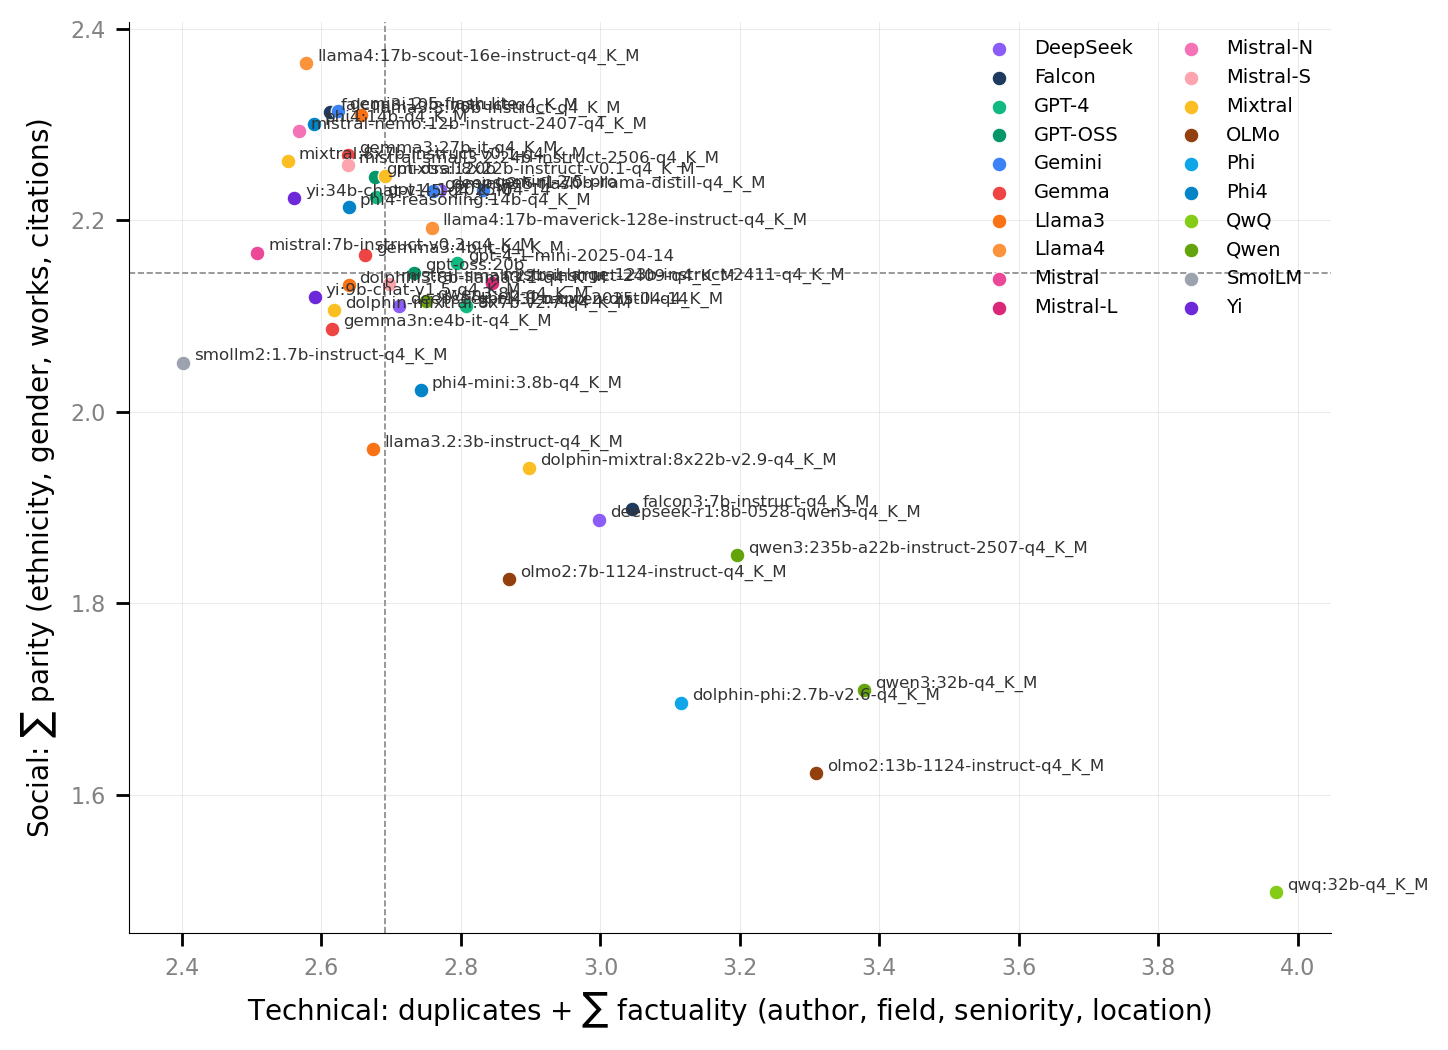

In [24]:
# ── Scatter: Social (∑ parity) vs Technical (∑ factuality + duplicates + factuality_location) ──
# One dot per model, colored by family, labeled with model name.
# Dashed lines at the median of each axis.

TICK_COLOR = '#828282'

FACT_COMPONENTS   = ['factuality', 'factuality_field', 'factuality_seniority', 'factuality_location']
TECH_EXTRAS       = ['duplicates']
PARITY_COMPONENTS = ['parity_ethnicity', 'parity_gender', 'parity_works', 'parity_citations']

# Aggregate per model (mean over experimental cells, then over runs already inside per_cell)
agg_cols = FACT_COMPONENTS + TECH_EXTRAS + PARITY_COMPONENTS
per_model = (per_cell.groupby('model', dropna=False)[agg_cols]
                     .mean()
                     .reset_index())
per_model = per_model.merge(model_meta[['model', 'model_family']], on='model', how='left')

per_model['x_technical'] = per_model[FACT_COMPONENTS + TECH_EXTRAS].sum(axis=1, skipna=False)
per_model['y_social']    = per_model[PARITY_COMPONENTS].sum(axis=1, skipna=False)

print(f'Scatter — {len(per_model)} models')
display(per_model[['model', 'model_family', 'x_technical', 'y_social']]
        .sort_values('y_social', ascending=False).round(3))

fig, ax = plt.subplots(figsize=(7.5, 5.5), dpi=200)

# Median reference lines
x_med = per_model['x_technical'].median()
y_med = per_model['y_social'].median()
ax.axvline(x_med, color='#888', lw=0.6, ls='--', zorder=1)
ax.axhline(y_med, color='#888', lw=0.6, ls='--', zorder=1)

# Plot one family at a time for a clean legend
for fam, grp in per_model.groupby('model_family'):
    ax.scatter(grp['x_technical'], grp['y_social'],
               s=28, color=FAMILY_COLORS.get(fam, '#6B7280'),
               edgecolor='white', linewidth=0.4, label=fam, zorder=3)

# Per-point labels
for _, r in per_model.iterrows():
    if pd.notna(r['x_technical']) and pd.notna(r['y_social']):
        ax.annotate(r['model'], (r['x_technical'], r['y_social']),
                    xytext=(4, 1), textcoords='offset points',
                    fontsize=6, color='#333', zorder=4)

ax.set_xlabel(r'Technical: duplicates + $\sum$ factuality (author, field, seniority, location)',
              fontsize=10)
ax.set_ylabel(r'Social: $\sum$ parity (ethnicity, gender, works, citations)', fontsize=10)
ax.tick_params(axis='both', labelsize=8, labelcolor=TICK_COLOR)
for sp in ('top', 'right'):
    ax.spines[sp].set_visible(False)
for sp in ('left', 'bottom'):
    ax.spines[sp].set_linewidth(0.4)
ax.grid(True, lw=0.3, alpha=0.3, zorder=0)
ax.legend(loc='best', fontsize=7, frameon=False, ncol=2)

fig.tight_layout()
fig.savefig(PDF_DIR / 'plot_scatter_social_vs_technical.pdf', bbox_inches='tight', dpi=600)
print(f"Saved → {PDF_DIR / 'plot_scatter_social_vs_technical.pdf'}")
plt.show()


## Step 6 — Social metrics by sub-population (field, location, field×location)

The metrics in `calls` so far use the GLOBAL ground-truth distribution. Here we recompute parity / diversity / popularity per sub-population: when the persona prompt restricts the search to a subgroup (e.g. `location=Japan`, `field=Biology`), the ground truth used for comparison is filtered to that same subgroup.

Ground-truth strategy per sub-population:

- **field**: SS GT filtered by the per-field CSV the row came from (`DataFrameRankings_*_with_ethnicity.csv` is already partitioned this way) joined with gender from the SS dedup parquet.
- **location**: SS does not carry per-researcher country. We use the OA-derived proxy — the gender / ethnicity distribution of all OA-resolved authors with that `location_oa_iso` in our enriched factuality_full dataset. Documented in METRICS.md.
- **field × location**: intersection of the two above filters.

Popularity terciles are recomputed per (`field`, subpop_col) so that, e.g. popularity in Japan is judged against the productivity distribution of Japan-based authors in that field.

Output: long-format `metrics_per_subpop.csv` with columns `(CALL_KEYS, subpop_dim, subpop_value_field, subpop_value_location, metric_name, value)`.

In [25]:
# ─────────────────────────────────────────────────────────────────────────────
# Step 6 — Social metrics per sub-population (vectorized)
# ─────────────────────────────────────────────────────────────────────────────
# Pulls sub-pop dims from libs.metrics.constants. Output lives in long DataFrame
# `metrics_per_subpop`. Does NOT touch `calls`.
#
# Vectorized over `_cid`: for each (subpop_dim, subpop_value) slice we build
# a counts pivot (rows=_cid × cats), normalize to fractions, then compute
# parity and Shannon entropy with pandas broadcasting — no Python per-call loop.

from libs.metrics.constants import (FIELD_ORDER, LOCATION_ORDER,
                                     BENCHMARK_SUBPOPULATION_COMBOS)

print(f"FIELD_ORDER:    {FIELD_ORDER}")
print(f"LOCATION_ORDER: {LOCATION_ORDER}")
print(f"Combos:         {BENCHMARK_SUBPOPULATION_COMBOS}")

# ── 1. Build per-field GT (Field column tagged from filename) ──────────────
def _load_gt_with_field():
    parts = []
    for fpath in sorted(glob.glob(ETH_GT_GLOB)):
        stem = Path(fpath).stem
        field = (stem.replace('DataFrameRankings_Genderize_Namsor_', '')
                     .replace('_with_ethnicity', '')
                     .replace('_', ' '))
        part = pd.read_csv(fpath, usecols=['Researcher_id', 'Year', 'perceived_ethnicity'])
        part = part.sort_values('Year').groupby('Researcher_id').last().reset_index()
        part['Field'] = field
        parts.append(part)
    df_gt = pd.concat(parts, ignore_index=True)
    gp = pd.read_parquet(SS_GT_PATH, columns=['Researcher_id', 'Combined_gender'])
    df_gt = df_gt.merge(gp, on='Researcher_id', how='left')
    df_gt['gender_clean']    = df_gt['Combined_gender'].str.strip().str.lower().map(
        {'male': 'Male', 'female': 'Female', 'unisex': 'Neutral'})
    df_gt['ethnicity_clean'] = df_gt['perceived_ethnicity'].map(ETHNICITY_MAP)
    return df_gt

_gt_field_cache = CACHE_DIR / f"gt_field_{_file_hash(SS_GT_PATH, *sorted(glob.glob(ETH_GT_GLOB)))}.pkl"
if _gt_field_cache.exists():
    print(f"Loading cached gt_with_field ({_gt_field_cache.name}) …")
    gt_field = pd.read_pickle(_gt_field_cache)
else:
    print("Building gt_with_field …")
    gt_field = _load_gt_with_field()
    gt_field.to_pickle(_gt_field_cache)

print(f"gt_with_field rows:   {len(gt_field):,}")

# ── 2. Local sub-pop frames (`found` keeps its _cid since it was sliced
#     before valid.drop(_cid); for prod we recompute _cid). ─────────────────
sp_found = found.copy()
sp_found['field_en'] = sp_found['field'].map(_FIELD_NORM_LOCAL).fillna(sp_found['field'])

sp_prod  = prod.copy()
sp_prod['_cid'] = sp_prod.groupby(CALL_KEYS, dropna=False).ngroup()

_call_key_map_found = sp_found[CALL_KEYS + ['_cid']].drop_duplicates('_cid').set_index('_cid')
_call_key_map_prod  = sp_prod[CALL_KEYS + ['_cid']].drop_duplicates('_cid').set_index('_cid')


def _gt_dists_for(field_val, loc_val):
    """Return (eth_gt_frac, gen_gt_frac) for the given sub-pop slice."""
    if loc_val is None:
        sub = gt_field if field_val is None else gt_field[gt_field['Field'] == field_val]
        if len(sub) == 0:
            return None, None
        return (sub['ethnicity_clean'].dropna().value_counts(normalize=True),
                sub['gender_clean'].dropna().value_counts(normalize=True))
    # location involved → OA-derived proxy from `sp_found`
    mask = (sp_found['location_oa_iso'] == loc_val)
    if field_val is not None:
        mask &= (sp_found['field_en'] == field_val)
    pool = sp_found.loc[mask].drop_duplicates(['author_id'])
    if len(pool) == 0:
        return None, None
    return (pool['ethnicity_clean'].dropna().value_counts(normalize=True),
            pool['gender_clean'].dropna().value_counts(normalize=True))


def _vec_div_par(slc, cat_col, cats, gt_frac):
    """Vectorized: returns (div_series, parity_series), index=_cid."""
    if len(slc) == 0:
        return pd.Series(dtype=float), pd.Series(dtype=float)
    known = slc[slc[cat_col].notna()]
    if len(known) == 0:
        return pd.Series(dtype=float), pd.Series(dtype=float)
    counts = (known.groupby(['_cid', cat_col]).size()
              .unstack(cat_col, fill_value=0)
              .reindex(columns=cats, fill_value=0))
    totals = counts.sum(axis=1)
    p = counts.div(totals.replace(0, np.nan), axis=0).fillna(0)
    # Shannon
    plog = p.where(p > 0)
    entropy = -(p * np.log(plog)).sum(axis=1)
    div = entropy / np.log(len(cats))
    div[totals < 2] = np.nan
    # Parity vs sub-pop GT (broadcast subtraction)
    if gt_frac is None or gt_frac.sum() == 0:
        parity = pd.Series(np.nan, index=counts.index)
    else:
        gt_aligned = gt_frac.reindex(cats, fill_value=0)
        if gt_aligned.sum() == 0:
            parity = pd.Series(np.nan, index=counts.index)
        else:
            gt_aligned = gt_aligned / gt_aligned.sum()
            tv = 0.5 * (p - gt_aligned).abs().sum(axis=1)
            parity = 1 - tv
            parity[totals == 0] = np.nan
    return div, parity


def _vec_popularity(pool, p33_s, p67_s):
    """Vectorized: returns (popularity_series, parity_tiers_series), index=_cid."""
    if pool.empty:
        return pd.Series(dtype=float), pd.Series(dtype=float)
    # Assign tier per author using field-mapped p33/p67 (Series indexed by field_en)
    p33 = pool['field_en'].map(p33_s)
    p67 = pool['field_en'].map(p67_s)
    return None, None  # placeholder — handled below per-(col, field)


# ── 3. Parity & diversity per sub-pop ──────────────────────────────────────
out_rows = []
for combo in BENCHMARK_SUBPOPULATION_COMBOS:
    has_field = 'field'    in combo
    has_loc   = 'location' in combo
    subpop_dim = '_x_'.join(combo)

    if subpop_dim == 'field':
        keys = [(f, None) for f in FIELD_ORDER]
    elif subpop_dim == 'location':
        keys = [(None, l) for l in LOCATION_ORDER]
    else:
        keys = [(f, l) for f in FIELD_ORDER for l in LOCATION_ORDER]

    for field_val, loc_val in keys:
        eth_gt, gen_gt = _gt_dists_for(field_val, loc_val)
        if eth_gt is None and gen_gt is None:
            continue
        mask = pd.Series(True, index=sp_found.index)
        if field_val is not None: mask &= (sp_found['field_en']        == field_val)
        if loc_val   is not None: mask &= (sp_found['location_oa_iso'] == loc_val)
        slc = sp_found[mask]
        if len(slc) == 0:
            continue

        div_eth, par_eth = _vec_div_par(slc, 'ethnicity_clean', ETH_CATS, eth_gt)
        div_gen, par_gen = _vec_div_par(slc, 'gender_clean',    GEN_CATS, gen_gt)

        # Materialize one long row per (cid, metric_name)
        for name, ser in [('div_ethnicity', div_eth), ('div_gender', div_gen),
                          ('parity_ethnicity', par_eth), ('parity_gender', par_gen)]:
            if ser.empty:
                continue
            tmp = ser.rename('value').reset_index()
            tmp['subpop_dim']      = subpop_dim
            tmp['subpop_field']    = field_val
            tmp['subpop_location'] = loc_val
            tmp['metric_name']     = name
            out_rows.append(tmp)

df_div_par = pd.concat(out_rows, ignore_index=True) if out_rows else pd.DataFrame()
df_div_par = df_div_par.join(_call_key_map_found, on='_cid') if not df_div_par.empty else df_div_par
print(f"parity/diversity sub-pop rows: {len(df_div_par):,}")


# ── 4. Popularity per sub-pop (terciles recomputed within the sub-pop pool) ─
pop_rows = []
for combo in BENCHMARK_SUBPOPULATION_COMBOS:
    subpop_dim = '_x_'.join(combo)
    if subpop_dim == 'field':
        keys = [(f, None) for f in FIELD_ORDER]
    elif subpop_dim == 'location':
        keys = [(None, l) for l in LOCATION_ORDER]
    else:
        keys = [(f, l) for f in FIELD_ORDER for l in LOCATION_ORDER]

    for field_val, loc_val in keys:
        mask = pd.Series(True, index=sp_prod.index)
        if field_val is not None: mask &= (sp_prod['field_en']        == field_val)
        if loc_val   is not None: mask &= (sp_prod['location_oa_iso'] == loc_val)
        pool = sp_prod[mask]
        if len(pool) < 30:
            continue

        for col, lab in PROD_FIELDS.items():
            # Field-keyed thresholds when subpop is location or field×location
            # (popularity is naturally field-relative). When subpop is field-only,
            # the pool is already field-homogeneous so a single threshold suffices.
            th = (pool.groupby('field_en')[col]
                      .quantile([0.33, 0.67]).unstack()
                      .rename(columns={0.33: 'p33', 0.67: 'p67'}))
            if th.empty:
                continue
            p33 = pool['field_en'].map(th['p33'])
            p67 = pool['field_en'].map(th['p67'])
            tier = pd.Series(np.nan, index=pool.index, dtype=object)
            ok = pool[col].notna() & p33.notna() & p67.notna()
            tier[ok & (pool[col] <= p33)] = 'low'
            tier[ok & (pool[col] >  p33) & (pool[col] <= p67)] = 'med'
            tier[ok & (pool[col] >  p67)] = 'high'

            tdf = pool.assign(_tier=tier).dropna(subset=['_tier'])
            cnt = (tdf.groupby(['_cid', '_tier']).size()
                    .unstack('_tier', fill_value=0)
                    .reindex(columns=['low', 'med', 'high'], fill_value=0))
            tot = cnt.sum(axis=1)
            frac = cnt.div(tot.replace(0, np.nan), axis=0).fillna(0)
            pop_high = frac['high']
            u = 1/3
            par_tier = 1 - 0.5 * (frac.sub(u).abs().sum(axis=1))

            for name, ser in [(f'popularity_{lab}', pop_high), (f'parity_{lab}', par_tier)]:
                tmp = ser.rename('value').reset_index()
                tmp['subpop_dim']      = subpop_dim
                tmp['subpop_field']    = field_val
                tmp['subpop_location'] = loc_val
                tmp['metric_name']     = name
                pop_rows.append(tmp)

df_pop = pd.concat(pop_rows, ignore_index=True) if pop_rows else pd.DataFrame()
df_pop = df_pop.join(_call_key_map_prod, on='_cid') if not df_pop.empty else df_pop
print(f"popularity   sub-pop rows: {len(df_pop):,}")

metrics_per_subpop = pd.concat([df_div_par, df_pop], ignore_index=True)
if '_cid' in metrics_per_subpop.columns:
    metrics_per_subpop = metrics_per_subpop.drop(columns=['_cid'])

OUT_SUBPOP_CSV = RESULTS / 'summary/metrics_per_subpop.csv'
metrics_per_subpop.to_csv(OUT_SUBPOP_CSV, index=False)
print(f"\nmetrics_per_subpop rows: {len(metrics_per_subpop):,}  →  {OUT_SUBPOP_CSV}")
print("\nDistribution by subpop_dim × metric_name:")
display(metrics_per_subpop.groupby(['subpop_dim', 'metric_name'])['value']
        .agg(['count', 'mean', 'std']).round(4))

FIELD_ORDER:    ['Biology', 'Computer Science', 'Mathematics', 'Physics', 'Psychology', 'Sociology']
LOCATION_ORDER: ['EC', 'JP', 'DE', 'CA', 'ZA']
Combos:         [['field'], ['location'], ['field', 'location']]
Loading cached gt_with_field (gt_field_7913d1dede.pkl) …
gt_with_field rows:   8,744,905


parity/diversity sub-pop rows: 6,054,432
popularity   sub-pop rows: 6,941,516

metrics_per_subpop rows: 12,995,948  →  ../../../results/summary/metrics_per_subpop.csv

Distribution by subpop_dim × metric_name:


count   mean    std
subpop_dim       metric_name                               
field            div_ethnicity         347012 0.2280 0.2353
                 div_gender            451382 0.4960 0.1962
                 parity_citations      751545 0.5338 0.2062
                 parity_ethnicity      641092 0.3744 0.1749
                 parity_gender         746740 0.6991 0.2230
                 parity_works          751545 0.5407 0.2089
                 popularity_citations  751545 0.3096 0.3549
                 popularity_works      751545 0.3178 0.3552
field_x_location div_ethnicity         162148 0.1290 0.2109
                 div_gender            204162 0.4070 0.2613
                 parity_citations      491917 0.4852 0.2027
                 parity_ethnicity      376508 0.7049 0.3243
                 parity_gender         443184 0.6476 0.1937
                 parity_works          491917 0.4883 0.2041
                 popularity_citations  491917 0.3405 0.4025
                 popularity_works      491917 0.3328 0.3967
location         div_ethnicity         162148 0.1290 0.2109
                 div_gender            204162 0.4070 0.2613
                 parity_citations      491917 0.4852 0.2027
                 parity_ethnicity      376508 0.7033 0.3280
                 parity_gender         443184 0.6405 0.1926
                 parity_works          491917 0.4883 0.2041
                 popularity_citations  491917 0.3405 0.4025
                 popularity_works      491917 0.3328 0.3967

### Step 6.5 — Faceted plots of sub-population metrics

One figure per `subpop_dim`: grid of metrics (rows) × model (columns) showing the mean metric across calls for each sub-population value. Saved as PNG (`results/figures/`) + PDF (`results/new_plots/`).

wrote: ../../../results/figures/subpop_field.png  &  ../../../results/new_plots/subpop_field.pdf


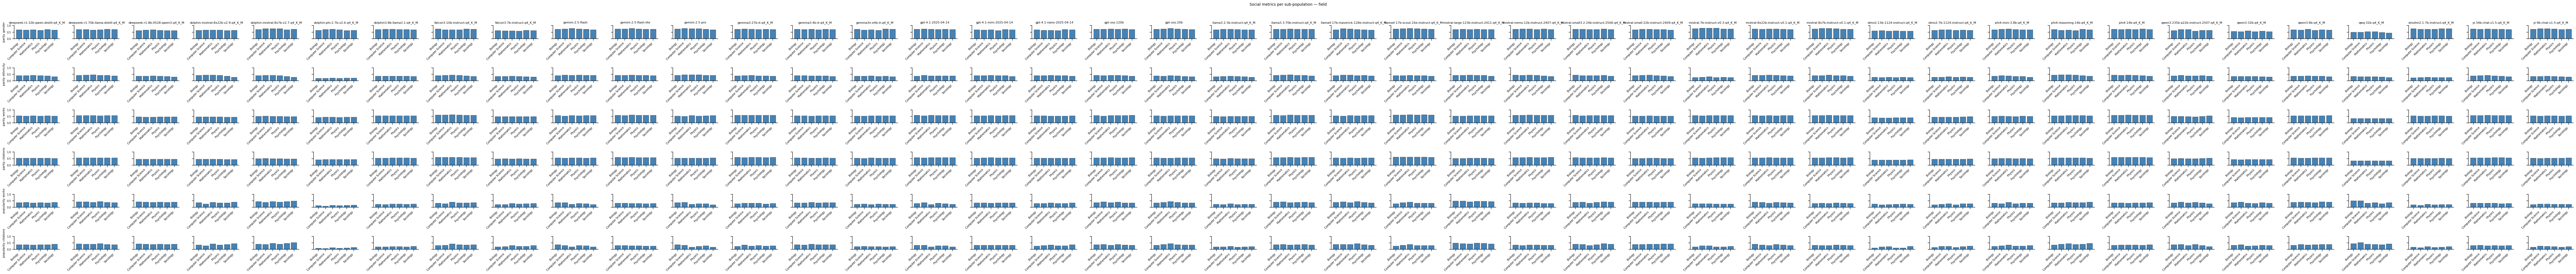

wrote: ../../../results/figures/subpop_location.png  &  ../../../results/new_plots/subpop_location.pdf


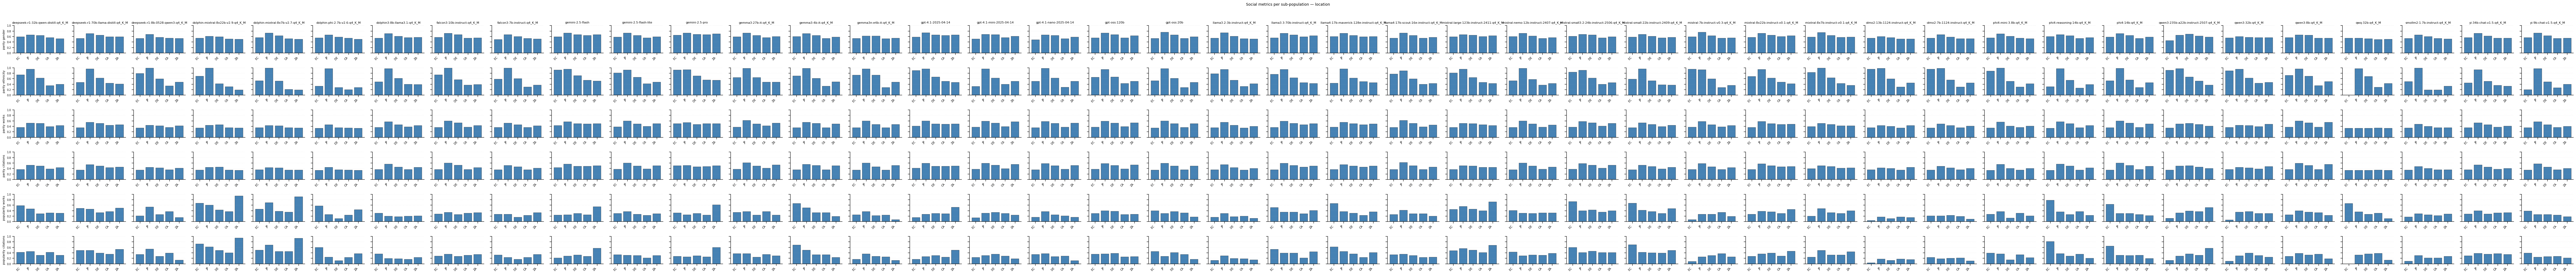

In [26]:
# ─────────────────────────────────────────────────────────────────────────────
# Step 6.5 — Faceted plots of sub-population metrics
# ─────────────────────────────────────────────────────────────────────────────
# One figure per subpop_dim. Each figure is a grid: rows = metric_name,
# columns = model. Bars show the mean across calls, grouped by sub-pop value
# (field or location). Saved as PNG + PDF in `results/figures/`.

import matplotlib.pyplot as plt
from IPython.display import display

# Order constants for legible axes (English / language-stable categorical orders)
from libs.metrics.constants import FIELD_ORDER, LOCATION_ORDER

# Subpop metrics we care to plot (skip pure diversity to keep figs compact —
# parity & popularity carry the novelty signal Lisette is looking for).
PLOT_METRICS_ORDER = [
    'parity_gender', 'parity_ethnicity',
    'parity_works', 'parity_citations',
    'popularity_works', 'popularity_citations',
]

# Optional model ordering — falls back to first-seen.
MODEL_ORDER_FALLBACK = sorted(metrics_per_subpop['model'].dropna().unique().tolist())

def _bar_grid_for(dim_name, value_col, value_order):
    sub = metrics_per_subpop[metrics_per_subpop['subpop_dim'] == dim_name]
    if sub.empty:
        print(f'(no rows for subpop_dim={dim_name})')
        return
    sub = sub[sub['metric_name'].isin(PLOT_METRICS_ORDER)]
    sub = sub.dropna(subset=['value'])
    if sub.empty:
        print(f'(no plottable rows for subpop_dim={dim_name})')
        return
    # Mean across calls per (model, value_col, metric_name)
    agg = (sub.groupby(['model', value_col, 'metric_name'])['value']
              .mean().reset_index())
    models  = MODEL_ORDER_FALLBACK
    metrics = PLOT_METRICS_ORDER
    n_rows, n_cols = len(metrics), len(models)
    fig, axes = plt.subplots(n_rows, n_cols,
                              figsize=(2.2*n_cols + 1.0, 1.6*n_rows + 0.8),
                              sharey='row', squeeze=False)
    for r, metric in enumerate(metrics):
        for c, model in enumerate(models):
            ax = axes[r][c]
            cell = agg[(agg['model'] == model) & (agg['metric_name'] == metric)]
            if cell.empty:
                ax.set_axis_off()
                continue
            cell = cell.set_index(value_col).reindex(value_order)
            ax.bar(range(len(value_order)), cell['value'].fillna(0).values,
                    color='steelblue', edgecolor='black', linewidth=0.4)
            ax.set_xticks(range(len(value_order)))
            ax.set_xticklabels(value_order, rotation=45, ha='right', fontsize=7)
            ax.set_ylim(0, 1)
            if r == 0:
                ax.set_title(model, fontsize=8)
            if c == 0:
                ax.set_ylabel(metric.replace('_', ' '), fontsize=8)
            ax.tick_params(axis='y', labelsize=7)
            ax.grid(axis='y', linestyle=':', linewidth=0.4, alpha=0.5)
    fig.suptitle(f'Social metrics per sub-population — {dim_name}', fontsize=10)
    fig.tight_layout(rect=[0, 0, 1, 0.97])
    out_png = FIG_DIR / f'subpop_{dim_name}.png'
    out_pdf = PDF_DIR / f'subpop_{dim_name}.pdf'
    fig.savefig(out_png, dpi=FIG_DPI, bbox_inches='tight')
    fig.savefig(out_pdf,           bbox_inches='tight')
    print(f'wrote: {out_png}  &  {out_pdf}')
    display(fig)
    plt.close(fig)


_bar_grid_for('field',            'subpop_field',    FIELD_ORDER)
_bar_grid_for('location',         'subpop_location', LOCATION_ORDER)
# field × location plot would be wide — skip the heatmap version for now;
# the CSV is the canonical artifact. Plot it on demand from the CSV.

wrote: ../../../results/figures/subpop_field_agg.png  &  ../../../results/new_plots/subpop_field_agg.pdf


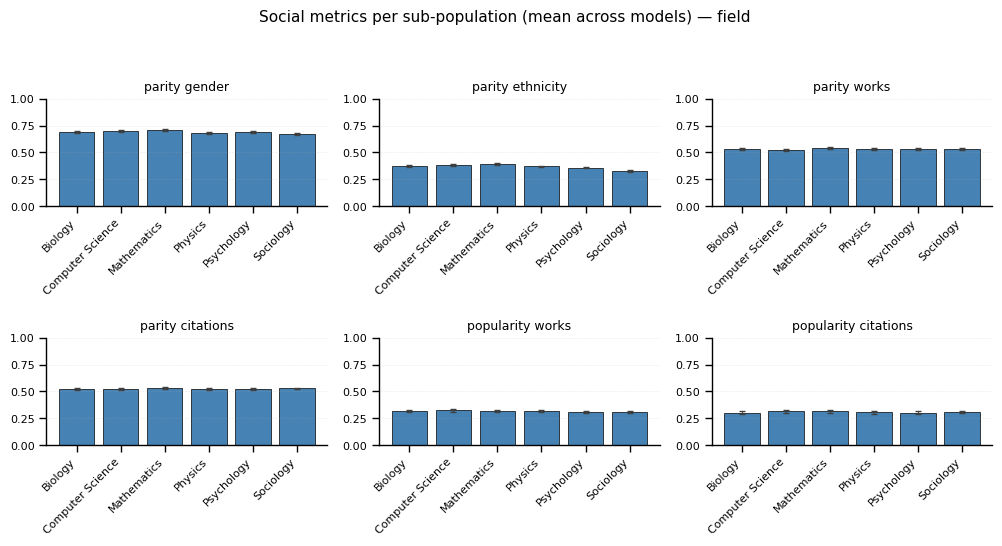

wrote: ../../../results/figures/subpop_location_agg.png  &  ../../../results/new_plots/subpop_location_agg.pdf


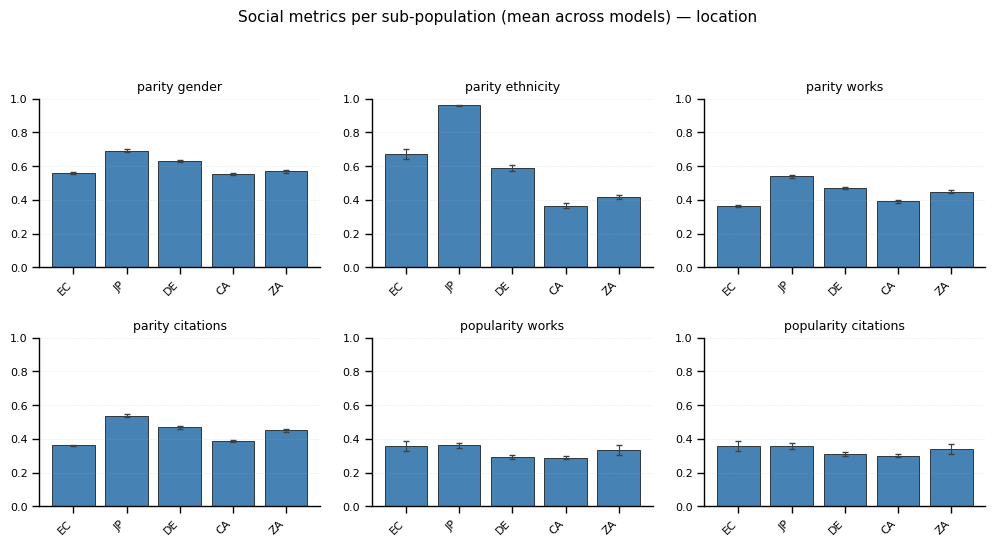

In [27]:
# ─────────────────────────────────────────────────────────────────────────────
# Step 6.5b — Aggregated sub-population plots (no per-model column)
# ─────────────────────────────────────────────────────────────────────────────
# Same metric set and x-axis as `_bar_grid_for`, but averaged across all models
# so each subpop_dim collapses to a compact 2x3 grid of metrics. Models are
# first averaged within-model (so each model contributes equally), then across
# models. Error bars are SE across model means.

import numpy as np

def _bar_grid_aggregated_for(dim_name, value_col, value_order):
    sub = metrics_per_subpop[metrics_per_subpop['subpop_dim'] == dim_name]
    if sub.empty:
        print(f'(no rows for subpop_dim={dim_name})')
        return
    sub = sub[sub['metric_name'].isin(PLOT_METRICS_ORDER)]
    sub = sub.dropna(subset=['value'])
    if sub.empty:
        print(f'(no plottable rows for subpop_dim={dim_name})')
        return
    per_model = (sub.groupby(['model', value_col, 'metric_name'])['value']
                    .mean().reset_index())
    agg = (per_model.groupby([value_col, 'metric_name'])['value']
                    .agg(['mean', 'std', 'count']).reset_index())
    agg['se'] = agg['std'] / np.sqrt(agg['count'].clip(lower=1))

    metrics = PLOT_METRICS_ORDER
    n_metrics = len(metrics)
    n_cols = 3
    n_rows = int(np.ceil(n_metrics / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols,
                              figsize=(3.2*n_cols + 0.6, 2.4*n_rows + 0.8),
                              squeeze=False)
    for i, metric in enumerate(metrics):
        r, c = divmod(i, n_cols)
        ax = axes[r][c]
        cell = agg[agg['metric_name'] == metric].set_index(value_col).reindex(value_order)
        means = cell['mean'].fillna(0).values
        errs  = cell['se'].fillna(0).values
        ax.bar(range(len(value_order)), means, yerr=errs,
                color='steelblue', edgecolor='black', linewidth=0.5,
                error_kw={'elinewidth': 0.8, 'capsize': 2.5, 'ecolor': '0.25'})
        ax.set_xticks(range(len(value_order)))
        ax.set_xticklabels(value_order, rotation=45, ha='right', fontsize=8)
        ax.set_ylim(0, 1)
        ax.set_title(metric.replace('_', ' '), fontsize=9)
        ax.tick_params(axis='y', labelsize=8)
        ax.grid(axis='y', linestyle=':', linewidth=0.4, alpha=0.5)
    for j in range(n_metrics, n_rows * n_cols):
        r, c = divmod(j, n_cols)
        axes[r][c].set_axis_off()
    fig.suptitle(f'Social metrics per sub-population (mean across models) — {dim_name}',
                 fontsize=11)
    fig.tight_layout(rect=[0, 0, 1, 0.96])
    out_png = FIG_DIR / f'subpop_{dim_name}_agg.png'
    out_pdf = PDF_DIR / f'subpop_{dim_name}_agg.pdf'
    fig.savefig(out_png, dpi=FIG_DPI, bbox_inches='tight')
    fig.savefig(out_pdf,           bbox_inches='tight')
    print(f'wrote: {out_png}  &  {out_pdf}')
    display(fig)
    plt.close(fig)


_bar_grid_aggregated_for('field',    'subpop_field',    FIELD_ORDER)
_bar_grid_aggregated_for('location', 'subpop_location', LOCATION_ORDER)


wrote: ../../../results/figures/subpop_field_by_language.png  &  ../../../results/new_plots/subpop_field_by_language.pdf


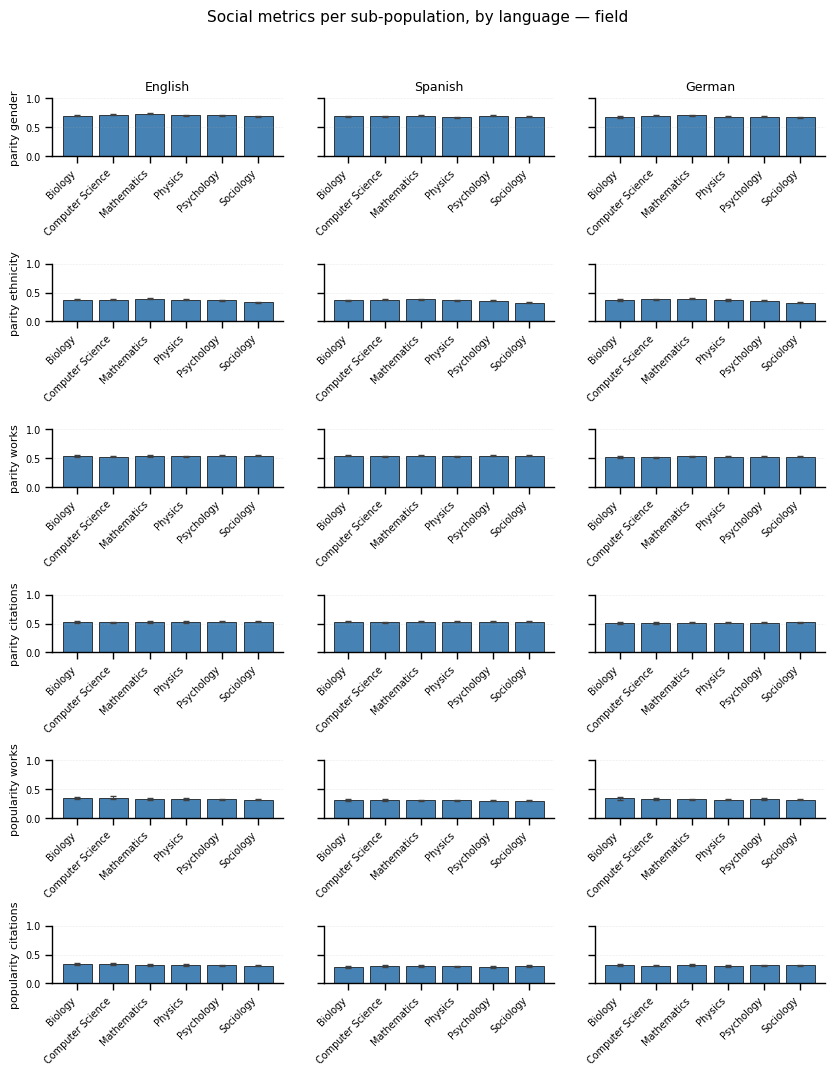

wrote: ../../../results/figures/subpop_location_by_language.png  &  ../../../results/new_plots/subpop_location_by_language.pdf


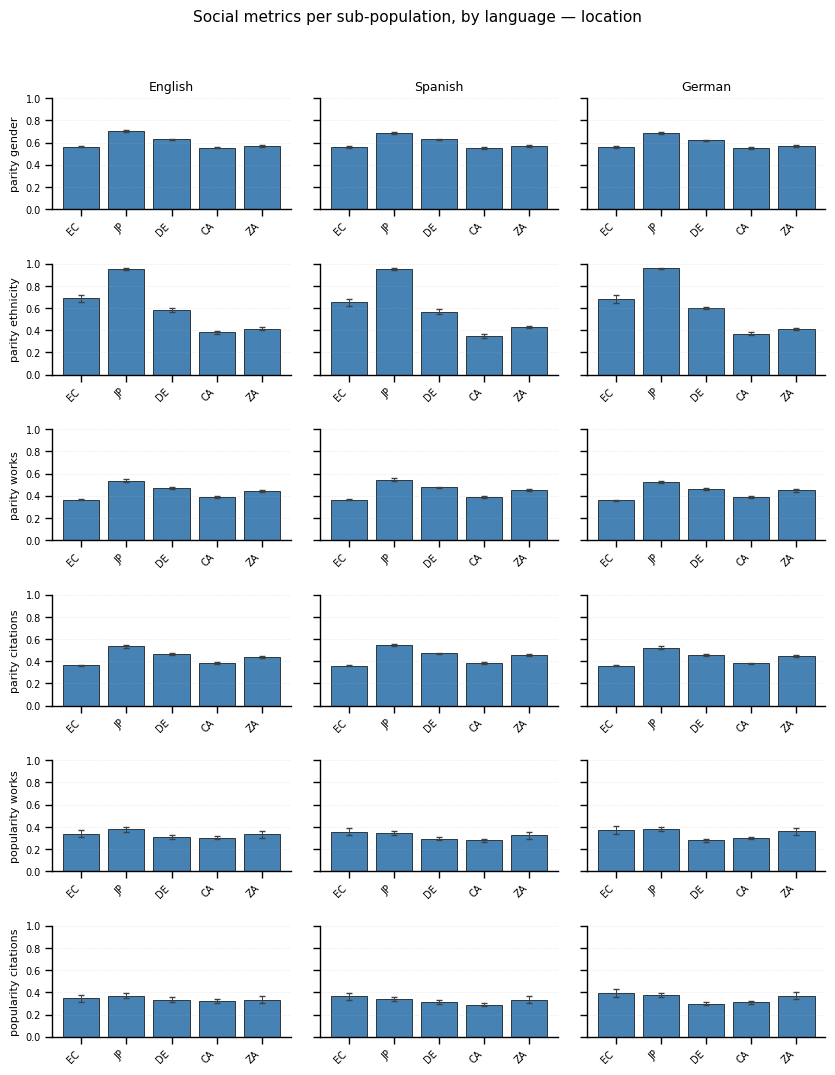

In [28]:
# ─────────────────────────────────────────────────────────────────────────────
# Step 6.5c — Sub-population plots faceted by LANGUAGE (not by model)
# ─────────────────────────────────────────────────────────────────────────────
# Grid: rows = metric, columns = language (English / Spanish / German — the
# canonical LANGUAGE_ORDER). Bars = mean across models & calls per sub-pop
# value (field or location). Error bars are SE across model means within each
# (language, sub-pop value, metric).

from libs.metrics.constants import LANGUAGE_ORDER, LANGUAGE_LABELS

def _bar_grid_by_language_for(dim_name, value_col, value_order):
    sub = metrics_per_subpop[metrics_per_subpop['subpop_dim'] == dim_name]
    if sub.empty:
        print(f'(no rows for subpop_dim={dim_name})')
        return
    sub = sub[sub['metric_name'].isin(PLOT_METRICS_ORDER)]
    sub = sub.dropna(subset=['value', 'language'])
    sub = sub[sub['language'].isin(LANGUAGE_ORDER)]
    if sub.empty:
        print(f'(no plottable rows for subpop_dim={dim_name})')
        return

    # Per-model mean first (equal weighting across models), then aggregate across models.
    per_model = (sub.groupby(['language', 'model', value_col, 'metric_name'])['value']
                    .mean().reset_index())
    agg = (per_model.groupby(['language', value_col, 'metric_name'])['value']
                    .agg(['mean', 'std', 'count']).reset_index())
    agg['se'] = agg['std'] / np.sqrt(agg['count'].clip(lower=1))

    metrics   = PLOT_METRICS_ORDER
    languages = LANGUAGE_ORDER
    n_rows, n_cols = len(metrics), len(languages)
    fig, axes = plt.subplots(n_rows, n_cols,
                              figsize=(2.6*n_cols + 0.8, 1.7*n_rows + 0.8),
                              sharey='row', squeeze=False)
    for r, metric in enumerate(metrics):
        for c, lang in enumerate(languages):
            ax = axes[r][c]
            cell = (agg[(agg['language'] == lang) & (agg['metric_name'] == metric)]
                    .set_index(value_col).reindex(value_order))
            means = cell['mean'].fillna(0).values
            errs  = cell['se'].fillna(0).values
            ax.bar(range(len(value_order)), means, yerr=errs,
                    color='steelblue', edgecolor='black', linewidth=0.5,
                    error_kw={'elinewidth': 0.7, 'capsize': 2.0, 'ecolor': '0.25'})
            ax.set_xticks(range(len(value_order)))
            ax.set_xticklabels(value_order, rotation=45, ha='right', fontsize=7)
            ax.set_ylim(0, 1)
            if r == 0:
                ax.set_title(LANGUAGE_LABELS.get(lang, lang), fontsize=9)
            if c == 0:
                ax.set_ylabel(metric.replace('_', ' '), fontsize=8)
            ax.tick_params(axis='y', labelsize=7)
            ax.grid(axis='y', linestyle=':', linewidth=0.4, alpha=0.5)
    fig.suptitle(f'Social metrics per sub-population, by language — {dim_name}',
                 fontsize=11)
    fig.tight_layout(rect=[0, 0, 1, 0.97])
    out_png = FIG_DIR / f'subpop_{dim_name}_by_language.png'
    out_pdf = PDF_DIR / f'subpop_{dim_name}_by_language.pdf'
    fig.savefig(out_png, dpi=FIG_DPI, bbox_inches='tight')
    fig.savefig(out_pdf,           bbox_inches='tight')
    print(f'wrote: {out_png}  &  {out_pdf}')
    display(fig)
    plt.close(fig)


_bar_grid_by_language_for('field',    'subpop_field',    FIELD_ORDER)
_bar_grid_by_language_for('location', 'subpop_location', LOCATION_ORDER)
